# Task 3 — Final V2 Common-Target Publication Analysis

This final notebook uses identical target positions for the core deterministic
and neural next-activity models. It also contains leakage-free preprocessing,
separate seed and held-out-group variability, and the optional HMM appendices.


## Reporting convention

The **primary deterministic panel and all neural models predict token positions
3 onward**, giving each core model the same 217 next-activity targets.

The notebook reports:

- pooled LOGO metrics for deterministic models;
- mean ± SD of pooled neural metrics across three seeds;
- held-out-group mean ± SD, after neural seeds are first averaged within each
  group.

Pooled scores and held-out-group SD remain in separate columns.


## How to run this final notebook

Run all cells from the top through **Part IV**. These cells produce the final
core Task 3 publication results.

The optional appendices contain the additional window-level, segment-feature,
expanding-prefix and HMM analyses.

Outputs are written to:

`/content/drive/MyDrive/thesis/data/PUBLICATION_TASK3_FINAL_V2_COMMON_TARGETS`

The neural section is resumable and uses a new checkpoint folder. Old neural
checkpoints cannot be reloaded into this version.


In [1]:
# Optional Google Drive mount for Google Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    print('Not running in Google Colab. Update DATA_ROOT in the configuration cell.')


Mounted at /content/drive


In [2]:
# ================================================================
# GLOBAL CONFIGURATION
# ================================================================

import os
import json
import math
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

import torch
import torch.nn as nn

warnings.filterwarnings('ignore')

DATA_ROOT = '/content/drive/MyDrive/thesis/data'
CORE_OUT = os.path.join(DATA_ROOT, 'PUBLICATION_TASK3_FINAL_V2_COMMON_TARGETS')
os.makedirs(CORE_OUT, exist_ok=True)

RESUME_EXISTING = True
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

# Historical report seeds for token neural models.
TOKEN_SEEDS = [42, 1, 7]

# Historical report used population SD across these three seeds.
SEED_STD_DDOF = 0

# Group-level SD uses the conventional sample SD.
FOLD_STD_DDOF = 1

# In-fold sensor feature selection used in the old token notebook.
K_SELECT = 40

# Grammar orders for the updated Task 3 comparison.
GRAMMAR_ORDERS = [1, 2, 3, 5, 10]
HYBRID_ORDER = 3
HYBRID_LAMBDAS = np.round(np.linspace(0.0, 1.0, 11), 2)


# Version identifier included in corrected output/checkpoint names.
TASK3_PIPELINE_VERSION = 'final_v2_common_targets'
print('Task 3 pipeline version:', TASK3_PIPELINE_VERSION)
print('Output directory:', CORE_OUT)


device: cpu
Task 3 pipeline version: final_v2_common_targets
Output directory: /content/drive/MyDrive/thesis/data/PUBLICATION_TASK3_FINAL_V2_COMMON_TARGETS


In [3]:
import os
import shutil

OLD_TOKEN_PATH = (
    "/content/drive/MyDrive/thesis/data/"
    "PUBLICATION_TASK3_CORRECTED_FINAL/"
    "activity_tokens_6label_fullstat.csv"
)

NEW_TOKEN_PATH = (
    "/content/drive/MyDrive/thesis/data/"
    "PUBLICATION_TASK3_FINAL_V2_COMMON_TARGETS/"
    "activity_tokens_6label_fullstat.csv"
)

if not os.path.exists(OLD_TOKEN_PATH):
    raise FileNotFoundError(
        f"Previous verified token table not found:\n{OLD_TOKEN_PATH}"
    )

os.makedirs(
    os.path.dirname(NEW_TOKEN_PATH),
    exist_ok=True,
)

shutil.copy2(
    OLD_TOKEN_PATH,
    NEW_TOKEN_PATH,
)

print("Verified token table copied successfully:")
print(NEW_TOKEN_PATH)

Verified token table copied successfully:
/content/drive/MyDrive/thesis/data/PUBLICATION_TASK3_FINAL_V2_COMMON_TARGETS/activity_tokens_6label_fullstat.csv


# Part I — Build six-label full-statistic activity tokens

Consecutive windows carrying the same normalized process label are collapsed into one activity token. Every token contains duration plus 14 statistics for every available numeric sensor channel. Sensor selection is performed inside each training fold later.

In [4]:
# ================================================================
# BUILD FULL-STATISTIC SIX-LABEL ACTIVITY TOKENS
# ================================================================

NORM = os.path.join(
    DATA_ROOT,
    'RQ3_LABEL_NORMALIZATION',
    'rq3_normalized_labels_full.csv',
)

FEATURE_CANDIDATES = [
    os.path.join(DATA_ROOT, 'INTERACTION_ENG3', 'interaction_eng3_features.csv'),
    os.path.join(DATA_ROOT, 'INTERACTION_OE10', 'interaction_oe10_10s.csv'),
]

MERGE6 = {
    'social_conversation': 'conversation',
    'task_conversation': 'conversation',
}


def first_existing(columns, candidates):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None


def load_six_label_windows():
    labels = pd.read_csv(NORM)
    label_col = 'rq3_process_label'

    group_col = first_existing(labels.columns, ['group', 'group_id', 'session'])
    time_col = first_existing(
        labels.columns,
        ['window_start', 'win_start', 'start', 'time'],
    )

    if group_col is None or time_col is None or label_col not in labels.columns:
        raise ValueError('Could not identify group, time, or process-label columns.')

    labels = labels.dropna(subset=[group_col, time_col, label_col]).copy()
    labels[label_col] = labels[label_col].astype(str).replace(MERGE6)
    labels['_g'] = labels[group_col].astype(str)
    labels['_t'] = pd.to_numeric(labels[time_col], errors='coerce').round(1)

    feature_path = next(
        (path for path in FEATURE_CANDIDATES if os.path.exists(path)),
        None,
    )

    df = labels[['_g', '_t', label_col]].rename(
        columns={label_col: 'label'}
    )
    sensor_cols = []

    if feature_path is not None:
        features = pd.read_csv(feature_path)
        feature_group = first_existing(
            features.columns,
            ['group', 'group_id', 'session'],
        )
        feature_time = first_existing(
            features.columns,
            ['window_start', 'win_start', 'start', 'time'],
        )

        features['_g'] = features[feature_group].astype(str)
        features['_t'] = pd.to_numeric(
            features[feature_time], errors='coerce'
        ).round(1)

        excluded = {
            feature_group,
            feature_time,
            '_g',
            '_t',
            'group',
            'window_start',
            'window_end',
            'window_mid',
            'recognition_label',
            'label',
            'binary_label',
        }

        sensor_cols = []
        for column in features.columns:
            if column in excluded:
                continue
            numeric = pd.to_numeric(features[column], errors='coerce')
            if numeric.notna().sum() > 0:
                sensor_cols.append(column)

        feature_small = features[['_g', '_t'] + sensor_cols].copy()
        for column in sensor_cols:
            feature_small[column] = pd.to_numeric(
                feature_small[column], errors='coerce'
            )

        df = df.merge(
            feature_small.drop_duplicates(['_g', '_t']),
            on=['_g', '_t'],
            how='left',
        )

    df = (
        df.dropna(subset=['label'])
        .sort_values(['_g', '_t'])
        .reset_index(drop=True)
    )
    df['group'] = df['_g']
    return df, sensor_cols


STAT_NAMES = [
    'mean', 'std', 'min', 'max', 'range', 'median', 'iqr',
    'p10', 'p25', 'p75', 'p90', 'energy', 'rms', 'entropy',
]


def channel_statistics(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return {name: 0.0 for name in STAT_NAMES}

    q10, q25, q50, q75, q90 = np.percentile(
        values, [10, 25, 50, 75, 90]
    )

    if len(values) >= 8:
        power = np.abs(np.fft.rfft(values - values.mean())) ** 2
        power = power[1:]
        if power.sum() > 0 and len(power) > 1:
            probability = power / power.sum()
            entropy = float(
                -(probability * np.log(probability + 1e-12)).sum()
                / np.log(len(probability))
            )
        else:
            entropy = 0.0
    else:
        entropy = 0.0

    return {
        'mean': float(values.mean()),
        'std': float(values.std()),
        'min': float(values.min()),
        'max': float(values.max()),
        'range': float(values.max() - values.min()),
        'median': float(q50),
        'iqr': float(q75 - q25),
        'p10': float(q10),
        'p25': float(q25),
        'p75': float(q75),
        'p90': float(q90),
        'energy': float(np.mean(values ** 2)),
        'rms': float(np.sqrt(np.mean(values ** 2))),
        'entropy': entropy,
    }


def build_fullstat_tokens(window_df, sensor_cols):
    token_rows = []

    for group, group_df in window_df.groupby('group'):
        group_df = group_df.sort_values('_t').reset_index(drop=True)
        segment_id = (group_df['label'] != group_df['label'].shift()).cumsum()

        for _, segment in group_df.groupby(segment_id):
            record = {
                'group': group,
                'label': segment['label'].iloc[0],
                'duration': float(len(segment)),
                'start_time': float(segment['_t'].iloc[0]),
            }

            for channel in sensor_cols:
                stats = channel_statistics(
                    pd.to_numeric(segment[channel], errors='coerce').values
                )
                for stat_name, value in stats.items():
                    record[f'{channel}__{stat_name}'] = value

            token_rows.append(record)

    tokens = pd.DataFrame(token_rows)
    tokens = tokens.sort_values(['group', 'start_time']).reset_index(drop=True)
    feature_cols = [
        column
        for column in tokens.columns
        if column not in {'group', 'label', 'start_time'}
    ]
    return tokens, feature_cols


TOKEN_PATH = os.path.join(CORE_OUT, 'activity_tokens_6label_fullstat.csv')

if RESUME_EXISTING and os.path.exists(TOKEN_PATH):
    print('Reloading existing activity-token table.')
    T = pd.read_csv(TOKEN_PATH)
    fcols = [
        column
        for column in T.columns
        if column not in {'group', 'label', 'start_time'}
    ]
else:
    windows_6label, raw_sensor_cols = load_six_label_windows()
    T, fcols = build_fullstat_tokens(windows_6label, raw_sensor_cols)
    T.to_csv(TOKEN_PATH, index=False)

print('tokens:', len(T))
print('groups:', T['group'].nunique())
print('classes:', sorted(T['label'].unique()))
print('token feature dimensions:', len(fcols))
print('\nToken counts by class:')
display(T['label'].value_counts().rename_axis('label').reset_index(name='tokens'))


Reloading existing activity-token table.
tokens: 244
groups: 9
classes: ['building', 'conversation', 'inspection', 'merging', 'moving_transport', 'object_handover']
token feature dimensions: 337

Token counts by class:


,label,tokens
0,conversation,95
1,inspection,45
2,building,43
3,object_handover,28
4,moving_transport,22
5,merging,11


# Part II — Corrected common-target activity grammar comparison

All models in the primary panel predict positions 3 onward. All history orders
in the long-history panel predict positions 10 onward. This prevents target-set
differences from being mistaken for model improvements.


In [5]:
# ================================================================
# GRAMMAR, SECOND-ORDER, SENSOR AND HYBRID MODELS
# ================================================================

CLASSES = sorted(T['label'].astype(str).unique())
CLASS_TO_ID = {label: index for index, label in enumerate(CLASSES)}
ID_TO_CLASS = {index: label for label, index in CLASS_TO_ID.items()}
N_CLASSES = len(CLASSES)
FIXED_LABEL_IDS = np.arange(N_CLASSES)


def token_sequences(tokens):
    sequences = {}
    for group, sub in tokens.groupby('group'):
        sub = sub.sort_values('start_time').reset_index(drop=True)
        sequences[str(group)] = {
            'labels': np.asarray(
                [CLASS_TO_ID[label] for label in sub['label'].astype(str)],
                dtype=int,
            ),
            'features': sub[fcols].apply(
                pd.to_numeric, errors='coerce'
            ).values.astype(float),
        }
    return sequences


SEQUENCES = token_sequences(T)
ALL_GROUPS = sorted(SEQUENCES)


def fit_backoff_tables(train_groups, max_order, alpha=1.0):
    tables = {
        order: defaultdict(lambda: np.full(N_CLASSES, alpha, dtype=float))
        for order in range(1, max_order + 1)
    }
    global_counts = np.full(N_CLASSES, alpha, dtype=float)

    for group in train_groups:
        labels = SEQUENCES[group]['labels']
        for target_index in range(1, len(labels)):
            target = labels[target_index]
            global_counts[target] += 1

            for order in range(1, min(max_order, target_index) + 1):
                context = tuple(labels[target_index - order:target_index])
                tables[order][context][target] += 1

    return tables, global_counts


def backoff_probabilities(history, tables, global_counts, max_order):
    history = list(history)
    for order in range(min(max_order, len(history)), 0, -1):
        context = tuple(history[-order:])
        if context in tables[order]:
            counts = np.asarray(tables[order][context], dtype=float)
            return counts / counts.sum()

    return global_counts / global_counts.sum()


def fit_second_order_transition(train_groups, alpha=1.0):
    table = defaultdict(lambda: np.full(N_CLASSES, alpha, dtype=float))
    global_counts = np.full(N_CLASSES, alpha, dtype=float)

    for group in train_groups:
        labels = SEQUENCES[group]['labels']
        for target_index in range(2, len(labels)):
            context = (labels[target_index - 2], labels[target_index - 1])
            target = labels[target_index]
            table[context][target] += 1
            global_counts[target] += 1

    return table, global_counts


def fit_sensor_pipeline(train_groups):
    X_rows = []
    y_rows = []

    for group in train_groups:
        labels = SEQUENCES[group]['labels']
        features = SEQUENCES[group]['features']
        for target_index in range(1, len(labels)):
            X_rows.append(features[target_index - 1])
            y_rows.append(labels[target_index])

    X_rows = np.asarray(X_rows, dtype=float)
    y_rows = np.asarray(y_rows, dtype=int)

    k = min(K_SELECT, X_rows.shape[1])
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(f_classif, k=k)),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            max_iter=4000,
            class_weight='balanced',
            random_state=42,
        )),
    ])
    pipeline.fit(X_rows, y_rows)
    return pipeline


def aligned_sensor_probabilities(model, feature_row):
    probabilities = model.predict_proba(
        np.asarray(feature_row, dtype=float).reshape(1, -1)
    )[0]
    aligned = np.full(N_CLASSES, 1e-12, dtype=float)
    for class_id, probability in zip(model.classes_, probabilities):
        aligned[int(class_id)] = float(probability)
    aligned /= aligned.sum()
    return aligned


def metric_record(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(
            y_true,
            y_pred,
            labels=FIXED_LABEL_IDS,
            average='macro',
            zero_division=0,
        ),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    }


def choose_hybrid_lambda(train_groups, order):
    if len(train_groups) < 2:
        return 1.0

    validation_group = sorted(train_groups)[-1]
    fitting_groups = [g for g in train_groups if g != validation_group]

    tables, global_counts = fit_backoff_tables(fitting_groups, order)
    sensor_model = fit_sensor_pipeline(fitting_groups)

    labels = SEQUENCES[validation_group]['labels']
    features = SEQUENCES[validation_group]['features']

    y_true = []
    ngram_probs = []
    sensor_probs = []

    for target_index in range(order, len(labels)):
        y_true.append(labels[target_index])
        ngram_probs.append(
            backoff_probabilities(
                labels[:target_index],
                tables,
                global_counts,
                order,
            )
        )
        sensor_probs.append(
            aligned_sensor_probabilities(
                sensor_model,
                features[target_index - 1],
            )
        )

    if not y_true:
        return 1.0

    y_true = np.asarray(y_true, dtype=int)
    ngram_probs = np.asarray(ngram_probs)
    sensor_probs = np.asarray(sensor_probs)

    best_lambda = 1.0
    best_score = -np.inf

    for lam in HYBRID_LAMBDAS:
        combined = lam * ngram_probs + (1.0 - lam) * sensor_probs
        pred = combined.argmax(axis=1)
        score = f1_score(
            y_true,
            pred,
            labels=FIXED_LABEL_IDS,
            average='macro',
            zero_division=0,
        )
        if score > best_score + 1e-12:
            best_score = score
            best_lambda = float(lam)

    return best_lambda



# ================================================================
# CORRECTED FAIR GRAMMAR EVALUATION
# ================================================================

PRIMARY_START = 3
LONG_START = 10


def save_grammar_fold(
    rows,
    predictions,
    model,
    held_group,
    start,
    y_true,
    y_pred,
    selected_lambda=np.nan,
):
    scores = metric_record(y_true, y_pred)

    rows.append({
        'model': model,
        'held_group': held_group,
        'evaluation_start_index': start,
        'n': len(y_true),
        'selected_lambda': selected_lambda,
        **scores,
    })

    predictions.extend({
        'model': model,
        'held_group': held_group,
        'evaluation_start_index': start,
        'y_true': int(truth),
        'y_pred': int(prediction),
        'selected_lambda': selected_lambda,
    } for truth, prediction in zip(y_true, y_pred))


def summarize_common_targets(predictions, folds):
    output = []

    for model, model_predictions in predictions.groupby('model'):
        pooled = metric_record(
            model_predictions['y_true'].astype(int).values,
            model_predictions['y_pred'].astype(int).values,
        )
        model_folds = folds[folds['model'] == model]

        output.append({
            'model': model,
            'evaluation_start_index': int(
                model_predictions['evaluation_start_index'].iloc[0]
            ),
            'n': len(model_predictions),
            'pooled_accuracy': pooled['accuracy'],
            'pooled_macro_f1': pooled['macro_f1'],
            'pooled_balanced_accuracy': pooled['balanced_accuracy'],
            'fold_accuracy_mean': model_folds['accuracy'].mean(),
            'fold_accuracy_std': model_folds['accuracy'].std(
                ddof=FOLD_STD_DDOF
            ),
            'fold_macro_f1_mean': model_folds['macro_f1'].mean(),
            'fold_macro_f1_std': model_folds['macro_f1'].std(
                ddof=FOLD_STD_DDOF
            ),
            'fold_balanced_accuracy_mean': (
                model_folds['balanced_accuracy'].mean()
            ),
            'fold_balanced_accuracy_std': (
                model_folds['balanced_accuracy'].std(
                    ddof=FOLD_STD_DDOF
                )
            ),
            'n_folds': model_folds['held_group'].nunique(),
            'mean_selected_lambda': (
                model_folds['selected_lambda'].mean()
                if model_folds['selected_lambda'].notna().any()
                else np.nan
            ),
        })

    output = (
        pd.DataFrame(output)
        .sort_values(
            ['pooled_macro_f1', 'pooled_accuracy'],
            ascending=False,
        )
        .reset_index(drop=True)
    )

    for metric in ['accuracy', 'macro_f1', 'balanced_accuracy']:
        output[f'fold_{metric}_mean_pm_std'] = output.apply(
            lambda row: (
                f"{row[f'fold_{metric}_mean']:.3f} ± "
                f"{row[f'fold_{metric}_std']:.3f}"
            ),
            axis=1,
        )

    return output


def ngram_predictions_on_common_targets(
    labels,
    train_groups,
    order,
    start,
):
    tables, global_counts = fit_backoff_tables(
        train_groups,
        order,
    )

    y_true = []
    y_pred = []

    for index in range(start, len(labels)):
        probability = backoff_probabilities(
            labels[:index],
            tables,
            global_counts,
            order,
        )
        y_true.append(labels[index])
        y_pred.append(int(probability.argmax()))

    return y_true, y_pred


# ----------------------------------------------------------------
# A. Primary panel: all models predict token positions 3 onward
# ----------------------------------------------------------------
primary_fold_rows = []
primary_prediction_rows = []

for held_group in ALL_GROUPS:
    train_groups = [
        group
        for group in ALL_GROUPS
        if group != held_group
    ]

    labels = SEQUENCES[held_group]['labels']
    features = SEQUENCES[held_group]['features']

    # Fixed-order back-off models, all on the same targets.
    for order in [1, 2, 3]:
        y_true, y_pred = ngram_predictions_on_common_targets(
            labels,
            train_groups,
            order,
            PRIMARY_START,
        )

        model_name = (
            'segment_markov_h1'
            if order == 1
            else f'ngram_backoff_h{order}'
        )

        save_grammar_fold(
            primary_fold_rows,
            primary_prediction_rows,
            model_name,
            held_group,
            PRIMARY_START,
            y_true,
            y_pred,
        )

    # Count-based second-order categorical Markov model.
    # This is not called an HMM because it has no hidden states or emissions.
    second_order_table, second_global = fit_second_order_transition(
        train_groups
    )

    y_true = []
    y_pred = []

    for index in range(PRIMARY_START, len(labels)):
        context = (
            labels[index - 2],
            labels[index - 1],
        )
        counts = second_order_table.get(
            context,
            second_global,
        )
        y_true.append(labels[index])
        y_pred.append(int(np.argmax(counts)))

    save_grammar_fold(
        primary_fold_rows,
        primary_prediction_rows,
        'second_order_categorical_markov',
        held_group,
        PRIMARY_START,
        y_true,
        y_pred,
    )

    # Sensor-only next-activity classifier.
    sensor_model = fit_sensor_pipeline(train_groups)

    y_true = []
    y_pred = []

    for index in range(PRIMARY_START, len(labels)):
        probability = aligned_sensor_probabilities(
            sensor_model,
            features[index - 1],
        )
        y_true.append(labels[index])
        y_pred.append(int(probability.argmax()))

    save_grammar_fold(
        primary_fold_rows,
        primary_prediction_rows,
        'sensor_next_logreg',
        held_group,
        PRIMARY_START,
        y_true,
        y_pred,
    )

    # Grammar + sensor hybrid. Lambda is selected only inside the
    # outer training fold.
    selected_lambda = choose_hybrid_lambda(
        train_groups,
        HYBRID_ORDER,
    )

    grammar_tables, grammar_global = fit_backoff_tables(
        train_groups,
        HYBRID_ORDER,
    )
    sensor_model = fit_sensor_pipeline(train_groups)

    y_true = []
    y_pred = []

    for index in range(PRIMARY_START, len(labels)):
        grammar_probability = backoff_probabilities(
            labels[:index],
            grammar_tables,
            grammar_global,
            HYBRID_ORDER,
        )
        sensor_probability = aligned_sensor_probabilities(
            sensor_model,
            features[index - 1],
        )
        combined_probability = (
            selected_lambda * grammar_probability
            + (1.0 - selected_lambda) * sensor_probability
        )

        y_true.append(labels[index])
        y_pred.append(int(combined_probability.argmax()))

    save_grammar_fold(
        primary_fold_rows,
        primary_prediction_rows,
        'hybrid_ngram3_sensor',
        held_group,
        PRIMARY_START,
        y_true,
        y_pred,
        selected_lambda,
    )


grammar_folds = pd.DataFrame(primary_fold_rows)
grammar_predictions = pd.DataFrame(primary_prediction_rows)
grammar_summary = summarize_common_targets(
    grammar_predictions,
    grammar_folds,
)

if grammar_summary['n'].nunique() != 1:
    raise RuntimeError(
        'Primary grammar models do not have identical target counts.'
    )

print(
    '\nPRIMARY FAIR COMPARISON '
    '(every model predicts positions 3 onward)'
)
display(grammar_summary.round(4))


# ----------------------------------------------------------------
# B. Long-history sensitivity: every order predicts positions 10+
# ----------------------------------------------------------------
long_fold_rows = []
long_prediction_rows = []

for held_group in ALL_GROUPS:
    train_groups = [
        group
        for group in ALL_GROUPS
        if group != held_group
    ]
    labels = SEQUENCES[held_group]['labels']

    for order in [1, 2, 3, 5, 10]:
        y_true, y_pred = ngram_predictions_on_common_targets(
            labels,
            train_groups,
            order,
            LONG_START,
        )

        save_grammar_fold(
            long_fold_rows,
            long_prediction_rows,
            f'ngram_backoff_h{order}',
            held_group,
            LONG_START,
            y_true,
            y_pred,
        )


long_history_folds = pd.DataFrame(long_fold_rows)
long_history_predictions = pd.DataFrame(long_prediction_rows)
long_history_summary = summarize_common_targets(
    long_history_predictions,
    long_history_folds,
)

if long_history_summary['n'].nunique() != 1:
    raise RuntimeError(
        'Long-history models do not have identical target counts.'
    )

print(
    '\nLONG-HISTORY SENSITIVITY '
    '(every order predicts positions 10 onward)'
)
display(long_history_summary.round(4))


# ----------------------------------------------------------------
# Save corrected grammar outputs
# ----------------------------------------------------------------
grammar_outputs = {
    'task3_grammar_primary_common_targets_summary_with_std.csv': (
        grammar_summary
    ),
    'task3_grammar_primary_common_targets_fold_metrics.csv': (
        grammar_folds
    ),
    'task3_grammar_primary_common_targets_predictions.csv': (
        grammar_predictions
    ),
    'task3_grammar_long_history_common_targets_summary_with_std.csv': (
        long_history_summary
    ),
    'task3_grammar_long_history_common_targets_fold_metrics.csv': (
        long_history_folds
    ),
    'task3_grammar_long_history_common_targets_predictions.csv': (
        long_history_predictions
    ),
}

for filename, dataframe in grammar_outputs.items():
    dataframe.to_csv(
        os.path.join(CORE_OUT, filename),
        index=False,
    )

print('\nSaved corrected grammar tables to:')
print(CORE_OUT)



PRIMARY FAIR COMPARISON (every model predicts positions 3 onward)


,model,evaluation_start_index,n,pooled_accuracy,pooled_macro_f1,pooled_balanced_accuracy,fold_accuracy_mean,fold_accuracy_std,fold_macro_f1_mean,fold_macro_f1_std,fold_balanced_accuracy_mean,fold_balanced_accuracy_std,n_folds,mean_selected_lambda,fold_accuracy_mean_pm_std,fold_macro_f1_mean_pm_std,fold_balanced_accuracy_mean_pm_std
0,hybrid_ngram3_sensor,3,217,0.5806,0.5006,0.4910,0.5653,0.0705,0.4105,0.1309,0.4625,0.1306,9,0.9333,0.565 ± 0.070,0.411 ± 0.131,0.462 ± 0.131
1,ngram_backoff_h3,3,217,0.5853,0.4947,0.4820,0.5682,0.0649,0.4040,0.1221,0.4463,0.1184,9,NaN,0.568 ± 0.065,0.404 ± 0.122,0.446 ± 0.118
2,second_order_categorical_markov,3,217,0.5806,0.4242,0.4165,0.5665,0.0843,0.3519,0.0732,0.4007,0.0737,9,NaN,0.566 ± 0.084,0.352 ± 0.073,0.401 ± 0.074
3,ngram_backoff_h2,3,217,0.5806,0.4236,0.4165,0.5665,0.0843,0.3515,0.0730,0.4007,0.0737,9,NaN,0.566 ± 0.084,0.352 ± 0.073,0.401 ± 0.074
4,segment_markov_h1,3,217,0.4793,0.2875,0.3518,0.4331,0.1639,0.2224,0.1034,0.3330,0.1000,9,NaN,0.433 ± 0.164,0.222 ± 0.103,0.333 ± 0.100
5,sensor_next_logreg,3,217,0.2442,0.2329,0.2885,0.2681,0.1173,0.1741,0.0981,0.2481,0.1267,9,NaN,0.268 ± 0.117,0.174 ± 0.098,0.248 ± 0.127



LONG-HISTORY SENSITIVITY (every order predicts positions 10 onward)


,model,evaluation_start_index,n,pooled_accuracy,pooled_macro_f1,pooled_balanced_accuracy,fold_accuracy_mean,fold_accuracy_std,fold_macro_f1_mean,fold_macro_f1_std,fold_balanced_accuracy_mean,fold_balanced_accuracy_std,n_folds,mean_selected_lambda,fold_accuracy_mean_pm_std,fold_macro_f1_mean_pm_std,fold_balanced_accuracy_mean_pm_std
0,ngram_backoff_h3,10,154,0.6039,0.5034,0.4944,0.5646,0.2664,0.3158,0.1783,0.4570,0.2600,9,NaN,0.565 ± 0.266,0.316 ± 0.178,0.457 ± 0.260
1,ngram_backoff_h2,10,154,0.5909,0.4189,0.4127,0.4546,0.2732,0.2558,0.1607,0.3038,0.1746,9,NaN,0.455 ± 0.273,0.256 ± 0.161,0.304 ± 0.175
2,ngram_backoff_h5,10,154,0.4740,0.4068,0.4232,0.4724,0.2611,0.2779,0.1589,0.4049,0.2702,9,NaN,0.472 ± 0.261,0.278 ± 0.159,0.405 ± 0.270
3,ngram_backoff_h10,10,154,0.4416,0.3845,0.4043,0.4488,0.2700,0.2692,0.1620,0.3972,0.2776,9,NaN,0.449 ± 0.270,0.269 ± 0.162,0.397 ± 0.278
4,ngram_backoff_h1,10,154,0.4870,0.3108,0.3752,0.3447,0.2389,0.1967,0.1570,0.2886,0.1824,9,NaN,0.345 ± 0.239,0.197 ± 0.157,0.289 ± 0.182



Saved corrected grammar tables to:
/content/drive/MyDrive/thesis/data/PUBLICATION_TASK3_FINAL_V2_COMMON_TARGETS


# Part III — Leakage-free neural models on the same 217 targets

For every outer LOGO fold, validation is selected before preprocessing.
Imputation, feature selection and scaling are fitted only on the remaining
fitting groups.

Transformer and LSTM predictions start at token position 3, exactly matching
the primary deterministic panel.


In [6]:
# ================================================================
# TOKEN SEQUENCE MODELS
# ================================================================

class TokenSeqNet(nn.Module):
    def __init__(
        self,
        n_classes,
        n_features,
        kind='transformer',
        d_model=96,
        n_heads=8,
        n_layers=3,
        dropout=0.3,
        max_len=128,
    ):
        super().__init__()
        self.label_embedding = nn.Embedding(n_classes + 1, d_model)
        self.feature_projection = (
            nn.Linear(n_features, d_model)
            if n_features > 0
            else None
        )
        self.position = nn.Parameter(
            torch.randn(1, max_len, d_model) * 0.02
        )
        self.kind = kind
        self.dropout = nn.Dropout(dropout)

        if kind == 'transformer':
            layer = nn.TransformerEncoderLayer(
                d_model,
                n_heads,
                dim_feedforward=4 * d_model,
                dropout=dropout,
                batch_first=True,
                activation='gelu',
            )
            self.core = nn.TransformerEncoder(layer, n_layers)
        elif kind == 'lstm':
            self.core = nn.LSTM(
                d_model,
                d_model,
                num_layers=n_layers,
                batch_first=True,
                dropout=dropout if n_layers > 1 else 0.0,
            )
        else:
            raise ValueError(kind)

        self.head = nn.Linear(d_model, n_classes)

    def forward(self, label_input, feature_input=None):
        hidden = self.label_embedding(label_input)

        if self.feature_projection is not None and feature_input is not None:
            hidden = hidden + self.feature_projection(feature_input)

        length = hidden.size(1)
        hidden = hidden + self.position[:, :length, :]
        hidden = self.dropout(hidden)

        if self.kind == 'transformer':
            causal_mask = torch.triu(
                torch.ones(length, length, device=hidden.device)
                * float('-inf'),
                diagonal=1,
            )
            hidden = self.core(hidden, mask=causal_mask)
        else:
            hidden, _ = self.core(hidden)

        return self.head(hidden)


def run_token_seed(
    tokens,
    feature_cols,
    model_kind,
    use_features,
    seed,
    epochs=100,
    learning_rate=8e-4,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    classes = sorted(tokens['label'].astype(str).unique())
    class_to_id = {label: index for index, label in enumerate(classes)}
    n_classes = len(classes)
    start_id = n_classes

    groups = tokens['group'].astype(str).values
    logo = LeaveOneGroupOut()

    all_true = []
    all_pred = []
    all_group = []

    for train_index, test_index in logo.split(tokens, tokens['label'], groups):
        train_groups = np.unique(groups[train_index])

        # Select the validation group before fitting any preprocessing.
        validation_group = sorted(train_groups)[-1]
        fitting_groups = [
            group
            for group in train_groups
            if group != validation_group
        ]
        fitting_index = np.flatnonzero(
            np.isin(groups, fitting_groups)
        )

        imputer = None
        selector = None
        scaler = None
        selected_feature_count = 0

        if use_features and feature_cols:
            # Fit imputation, feature selection and scaling only on the
            # fitting groups. The validation and outer test groups remain
            # completely unseen by preprocessing.
            imputer = SimpleImputer(strategy='median').fit(
                tokens.iloc[fitting_index][feature_cols]
            )
            transformed_train = imputer.transform(
                tokens.iloc[fitting_index][feature_cols]
            )

            if K_SELECT and len(feature_cols) > K_SELECT:
                selector = SelectKBest(
                    f_classif,
                    k=K_SELECT,
                ).fit(
                    transformed_train,
                    tokens.iloc[fitting_index]['label']
                    .astype(str)
                    .values,
                )
                transformed_train = selector.transform(
                    transformed_train
                )

            scaler = StandardScaler().fit(transformed_train)
            selected_feature_count = transformed_train.shape[1]

        def sequences_for(group_ids):
            sequence_list = []
            for group in group_ids:
                sub = tokens[tokens['group'].astype(str) == str(group)].sort_values(
                    'start_time'
                )
                labels = np.asarray(
                    [class_to_id[label] for label in sub['label'].astype(str)],
                    dtype=int,
                )

                if use_features and feature_cols:
                    feature_values = imputer.transform(sub[feature_cols])
                    if selector is not None:
                        feature_values = selector.transform(feature_values)
                    feature_values = scaler.transform(feature_values).astype(np.float32)
                else:
                    feature_values = None

                sequence_list.append((str(group), labels, feature_values))
            return sequence_list

        fitting_sequences = sequences_for(fitting_groups)
        validation_sequences = sequences_for([validation_group])
        testing_sequences = sequences_for(np.unique(groups[test_index]))

        model = TokenSeqNet(
            n_classes=n_classes,
            n_features=selected_feature_count if use_features else 0,
            kind=model_kind,
        ).to(DEVICE)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=2e-3,
        )
        loss_function = nn.CrossEntropyLoss()

        def sequence_iterator(sequence_list):
            for group, labels, features in sequence_list:
                if len(labels) < 3:
                    continue
                label_input = np.concatenate([[start_id], labels[:-1]])
                yield group, label_input, labels, features

        best_state = None
        best_validation_loss = np.inf
        bad_epochs = 0

        for _ in range(epochs):
            model.train()
            for _, label_input, target, features in sequence_iterator(
                fitting_sequences
            ):
                label_tensor = torch.tensor(
                    label_input[None], dtype=torch.long, device=DEVICE
                )
                target_tensor = torch.tensor(
                    target, dtype=torch.long, device=DEVICE
                )
                feature_tensor = (
                    torch.tensor(
                        features[None], dtype=torch.float32, device=DEVICE
                    )
                    if features is not None
                    else None
                )

                output = model(label_tensor, feature_tensor)
                loss = loss_function(output[0], target_tensor)

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            model.eval()
            validation_loss = 0.0
            validation_batches = 0

            with torch.no_grad():
                for _, label_input, target, features in sequence_iterator(
                    validation_sequences
                ):
                    label_tensor = torch.tensor(
                        label_input[None], dtype=torch.long, device=DEVICE
                    )
                    target_tensor = torch.tensor(
                        target, dtype=torch.long, device=DEVICE
                    )
                    feature_tensor = (
                        torch.tensor(
                            features[None], dtype=torch.float32, device=DEVICE
                        )
                        if features is not None
                        else None
                    )
                    validation_loss += loss_function(
                        model(label_tensor, feature_tensor)[0],
                        target_tensor,
                    ).item()
                    validation_batches += 1

            validation_loss /= max(validation_batches, 1)

            if validation_loss < best_validation_loss - 1e-4:
                best_validation_loss = validation_loss
                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                }
                bad_epochs = 0
            else:
                bad_epochs += 1

            if bad_epochs >= 12:
                break

        if best_state is not None:
            model.load_state_dict(best_state)
            model.to(DEVICE)

        model.eval()
        with torch.no_grad():
            for group, label_input, target, features in sequence_iterator(
                testing_sequences
            ):
                label_tensor = torch.tensor(
                    label_input[None], dtype=torch.long, device=DEVICE
                )
                feature_tensor = (
                    torch.tensor(
                        features[None], dtype=torch.float32, device=DEVICE
                    )
                    if features is not None
                    else None
                )
                prediction = (
                    model(label_tensor, feature_tensor)[0]
                    .argmax(-1)
                    .cpu()
                    .numpy()
                )

                # Match the primary grammar panel exactly:
                # predict only token positions 3 onward.
                for token_index in range(PRIMARY_START, len(target)):
                    all_true.append(int(target[token_index]))
                    all_pred.append(int(prediction[token_index]))
                    all_group.append(str(group))

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return (
        np.asarray(all_true, dtype=int),
        np.asarray(all_pred, dtype=int),
        np.asarray(all_group, dtype=str),
        classes,
    )


In [7]:
# ================================================================
# RESUMABLE THREE-SEED TOKEN MODEL RUNNER — LEAKAGE-FREE VERSION
# ================================================================

NEURAL_CHECKPOINT_DIR = os.path.join(
    CORE_OUT,
    'TOKEN_NEURAL_CHECKPOINTS_FINAL_V2_COMMON_TARGETS',
)
os.makedirs(NEURAL_CHECKPOINT_DIR, exist_ok=True)

seed_result_rows = []
fold_metric_rows = []

for model_kind in ['transformer', 'lstm']:
    for use_features, feature_tag in [
        (False, 'labels_only'),
        (True, 'labels_sensors'),
    ]:
        for seed in TOKEN_SEEDS:
            run_key = (
                f'{TASK3_PIPELINE_VERSION}__'
                f'{model_kind}__{feature_tag}__seed{seed}'
            )
            prediction_path = os.path.join(
                NEURAL_CHECKPOINT_DIR,
                f'{run_key}__predictions.csv',
            )
            summary_path = os.path.join(
                NEURAL_CHECKPOINT_DIR,
                f'{run_key}__summary.csv',
            )

            if (
                RESUME_EXISTING
                and os.path.exists(prediction_path)
                and os.path.exists(summary_path)
            ):
                print('Reloading corrected token run:', run_key)
                prediction_df = pd.read_csv(prediction_path)
                seed_summary = (
                    pd.read_csv(summary_path)
                    .iloc[0]
                    .to_dict()
                )
            else:
                print('Running corrected token model:', run_key)

                (
                    y_true,
                    y_pred,
                    held_groups,
                    token_classes,
                ) = run_token_seed(
                    tokens=T,
                    feature_cols=fcols,
                    model_kind=model_kind,
                    use_features=use_features,
                    seed=seed,
                )

                prediction_df = pd.DataFrame({
                    'model_kind': model_kind,
                    'feature_setting': feature_tag,
                    'seed': seed,
                    'held_group': held_groups,
                    'y_true': y_true,
                    'y_pred': y_pred,
                })

                seed_summary = {
                    'model_kind': model_kind,
                    'feature_setting': feature_tag,
                    'seed': seed,
                    'n': len(y_true),
                    'accuracy': accuracy_score(y_true, y_pred),
                    'macro_f1': f1_score(
                        y_true,
                        y_pred,
                        labels=np.arange(len(token_classes)),
                        average='macro',
                        zero_division=0,
                    ),
                    'balanced_accuracy': balanced_accuracy_score(
                        y_true,
                        y_pred,
                    ),
                }

                prediction_df.to_csv(
                    prediction_path,
                    index=False,
                )
                pd.DataFrame([seed_summary]).to_csv(
                    summary_path,
                    index=False,
                )

            seed_result_rows.append(seed_summary)

            for held_group, fold_df in prediction_df.groupby(
                'held_group'
            ):
                fold_metric_rows.append({
                    'model_kind': model_kind,
                    'feature_setting': feature_tag,
                    'seed': seed,
                    'held_group': str(held_group),
                    'n': len(fold_df),
                    'accuracy': accuracy_score(
                        fold_df['y_true'],
                        fold_df['y_pred'],
                    ),
                    'macro_f1': f1_score(
                        fold_df['y_true'],
                        fold_df['y_pred'],
                        labels=np.arange(N_CLASSES),
                        average='macro',
                        zero_division=0,
                    ),
                    'balanced_accuracy': balanced_accuracy_score(
                        fold_df['y_true'],
                        fold_df['y_pred'],
                    ),
                })


neural_seed_results = pd.DataFrame(seed_result_rows)
neural_fold_metrics = pd.DataFrame(fold_metric_rows)


# Every seed/model must evaluate the same 217 targets as the primary grammar panel.
expected_core_targets = int(grammar_summary['n'].iloc[0])
target_counts = neural_seed_results.groupby(
    ['model_kind', 'feature_setting', 'seed']
)['n'].first()

if not (target_counts == expected_core_targets).all():
    raise RuntimeError(
        'Core neural target counts do not match the deterministic panel. '
        f'Expected {expected_core_targets}; found {sorted(target_counts.unique())}.'
    )

print(
    'Verified identical core target count for every model/seed:',
    expected_core_targets,
)

# ------------------------------------------------
# Seed-level variability of pooled results
# ------------------------------------------------
seed_summary = (
    neural_seed_results
    .groupby(
        ['model_kind', 'feature_setting'],
        as_index=False,
    )
    .agg(
        seed_accuracy_mean=('accuracy', 'mean'),
        seed_accuracy_std=(
            'accuracy',
            lambda x: np.std(x, ddof=SEED_STD_DDOF),
        ),
        seed_accuracy_sample_std=(
            'accuracy',
            lambda x: np.std(x, ddof=1),
        ),
        seed_macro_f1_mean=('macro_f1', 'mean'),
        seed_macro_f1_std=(
            'macro_f1',
            lambda x: np.std(x, ddof=SEED_STD_DDOF),
        ),
        seed_macro_f1_sample_std=(
            'macro_f1',
            lambda x: np.std(x, ddof=1),
        ),
        seed_balanced_accuracy_mean=(
            'balanced_accuracy',
            'mean',
        ),
        seed_balanced_accuracy_std=(
            'balanced_accuracy',
            lambda x: np.std(x, ddof=SEED_STD_DDOF),
        ),
        n_seeds=('seed', 'nunique'),
    )
)

# ------------------------------------------------
# Correct held-out-group variability
#
# First average the seeds inside every held-out group.
# Then calculate SD across the nine group means.
# ------------------------------------------------
group_means_over_seeds = (
    neural_fold_metrics
    .groupby(
        [
            'model_kind',
            'feature_setting',
            'held_group',
        ],
        as_index=False,
    )
    .agg(
        group_accuracy=('accuracy', 'mean'),
        group_macro_f1=('macro_f1', 'mean'),
        group_balanced_accuracy=(
            'balanced_accuracy',
            'mean',
        ),
        n_seeds=('seed', 'nunique'),
    )
)

group_summary = (
    group_means_over_seeds
    .groupby(
        ['model_kind', 'feature_setting'],
        as_index=False,
    )
    .agg(
        group_accuracy_mean=('group_accuracy', 'mean'),
        group_accuracy_std=(
            'group_accuracy',
            lambda x: np.std(x, ddof=FOLD_STD_DDOF),
        ),
        group_macro_f1_mean=('group_macro_f1', 'mean'),
        group_macro_f1_std=(
            'group_macro_f1',
            lambda x: np.std(x, ddof=FOLD_STD_DDOF),
        ),
        group_balanced_accuracy_mean=(
            'group_balanced_accuracy',
            'mean',
        ),
        group_balanced_accuracy_std=(
            'group_balanced_accuracy',
            lambda x: np.std(x, ddof=FOLD_STD_DDOF),
        ),
        n_groups=('held_group', 'nunique'),
    )
)

neural_summary = seed_summary.merge(
    group_summary,
    on=['model_kind', 'feature_setting'],
    how='left',
    validate='one_to_one',
)

neural_summary['seed_accuracy_mean_pm_std'] = neural_summary.apply(
    lambda row: (
        f"{row['seed_accuracy_mean']:.3f} ± "
        f"{row['seed_accuracy_std']:.3f}"
    ),
    axis=1,
)
neural_summary['seed_macro_f1_mean_pm_std'] = neural_summary.apply(
    lambda row: (
        f"{row['seed_macro_f1_mean']:.3f} ± "
        f"{row['seed_macro_f1_std']:.3f}"
    ),
    axis=1,
)
neural_summary['group_accuracy_mean_pm_std'] = neural_summary.apply(
    lambda row: (
        f"{row['group_accuracy_mean']:.3f} ± "
        f"{row['group_accuracy_std']:.3f}"
    ),
    axis=1,
)
neural_summary['group_macro_f1_mean_pm_std'] = neural_summary.apply(
    lambda row: (
        f"{row['group_macro_f1_mean']:.3f} ± "
        f"{row['group_macro_f1_std']:.3f}"
    ),
    axis=1,
)

neural_summary = (
    neural_summary
    .sort_values(
        'seed_macro_f1_mean',
        ascending=False,
    )
    .reset_index(drop=True)
)

# ------------------------------------------------
# Save corrected neural outputs
# ------------------------------------------------
neural_seed_results.to_csv(
    os.path.join(
        CORE_OUT,
        'task3_token_neural_FINAL_V2_COMMON_TARGETS_seed_results.csv',
    ),
    index=False,
)
neural_fold_metrics.to_csv(
    os.path.join(
        CORE_OUT,
        'task3_token_neural_FINAL_V2_COMMON_TARGETS_seed_group_metrics.csv',
    ),
    index=False,
)
group_means_over_seeds.to_csv(
    os.path.join(
        CORE_OUT,
        'task3_token_neural_FINAL_V2_COMMON_TARGETS_group_means.csv',
    ),
    index=False,
)
neural_summary.to_csv(
    os.path.join(
        CORE_OUT,
        'task3_token_neural_FINAL_V2_COMMON_TARGETS_summary_with_std.csv',
    ),
    index=False,
)

print('\nCORRECTED NEURAL SUMMARY')
display(neural_summary.round(4))

print('\nHELD-OUT-GROUP MEANS AFTER AVERAGING SEEDS')
display(group_means_over_seeds.round(4))

print('\nSaved leakage-free neural results to:')
print(CORE_OUT)


Reloading corrected token run: final_v2_common_targets__transformer__labels_only__seed42
Reloading corrected token run: final_v2_common_targets__transformer__labels_only__seed1
Reloading corrected token run: final_v2_common_targets__transformer__labels_only__seed7
Reloading corrected token run: final_v2_common_targets__transformer__labels_sensors__seed42
Reloading corrected token run: final_v2_common_targets__transformer__labels_sensors__seed1
Reloading corrected token run: final_v2_common_targets__transformer__labels_sensors__seed7
Reloading corrected token run: final_v2_common_targets__lstm__labels_only__seed42
Reloading corrected token run: final_v2_common_targets__lstm__labels_only__seed1
Reloading corrected token run: final_v2_common_targets__lstm__labels_only__seed7
Reloading corrected token run: final_v2_common_targets__lstm__labels_sensors__seed42
Reloading corrected token run: final_v2_common_targets__lstm__labels_sensors__seed1
Reloading corrected token run: final_v2_common_t

,model_kind,feature_setting,seed_accuracy_mean,seed_accuracy_std,seed_accuracy_sample_std,seed_macro_f1_mean,seed_macro_f1_std,seed_macro_f1_sample_std,seed_balanced_accuracy_mean,seed_balanced_accuracy_std,...,group_accuracy_std,group_macro_f1_mean,group_macro_f1_std,group_balanced_accuracy_mean,group_balanced_accuracy_std,n_groups,seed_accuracy_mean_pm_std,seed_macro_f1_mean_pm_std,group_accuracy_mean_pm_std,group_macro_f1_mean_pm_std
0,transformer,labels_sensors,0.5407,0.0043,0.0053,0.3929,0.0098,0.0120,0.3969,0.0062,...,0.0834,0.3170,0.0606,0.3980,0.0688,9,0.541 ± 0.004,0.393 ± 0.010,0.523 ± 0.083,0.317 ± 0.061
1,transformer,labels_only,0.4531,0.0207,0.0254,0.3135,0.0234,0.0287,0.3435,0.0292,...,0.0702,0.2635,0.0509,0.3599,0.0544,9,0.453 ± 0.021,0.313 ± 0.023,0.455 ± 0.070,0.263 ± 0.051
2,lstm,labels_sensors,0.4624,0.0434,0.0532,0.3012,0.0376,0.0461,0.3075,0.0366,...,0.0930,0.2397,0.0551,0.3202,0.0571,9,0.462 ± 0.043,0.301 ± 0.038,0.462 ± 0.093,0.240 ± 0.055
3,lstm,labels_only,0.4501,0.0256,0.0314,0.2904,0.0250,0.0306,0.3000,0.0243,...,0.1155,0.2124,0.0834,0.2947,0.0656,9,0.450 ± 0.026,0.290 ± 0.025,0.421 ± 0.116,0.212 ± 0.083



HELD-OUT-GROUP MEANS AFTER AVERAGING SEEDS


,model_kind,feature_setting,held_group,group_accuracy,group_macro_f1,group_balanced_accuracy,n_seeds
0,lstm,labels_only,1,0.4167,0.1376,0.2667,3
1,lstm,labels_only,10,0.2500,0.1605,0.3333,3
2,lstm,labels_only,2,0.5833,0.2700,0.3791,3
3,lstm,labels_only,3,0.5278,0.2251,0.2915,3
4,lstm,labels_only,5,0.4500,0.2445,0.2794,3
5,lstm,labels_only,6,0.3333,0.0889,0.2000,3
6,lstm,labels_only,7,0.3111,0.2411,0.2817,3
7,lstm,labels_only,8,0.3694,0.1726,0.2231,3
8,lstm,labels_only,9,0.5495,0.3710,0.3974,3
9,lstm,labels_sensors,1,0.4444,0.2204,0.3444,3



Saved leakage-free neural results to:
/content/drive/MyDrive/thesis/data/PUBLICATION_TASK3_FINAL_V2_COMMON_TARGETS


# Part IV — Final common-target Task 3 comparison

All core model families now evaluate the same 217 target activities.
Deterministic and neural models remain in separate panels because their
uncertainty summaries have different bases.


In [8]:
# ================================================================
# FINAL CORRECTED CORE PUBLICATION TABLES
#
# Deterministic and neural models are displayed in separate panels
# because their headline metric bases are different.
# ================================================================

# ------------------------------------------------
# Panel A: deterministic grammar and sensor models
# ------------------------------------------------
deterministic_publication_table = grammar_summary.copy()

deterministic_publication_table = (
    deterministic_publication_table
    .sort_values(
        ['pooled_macro_f1', 'pooled_accuracy'],
        ascending=False,
    )
    .reset_index(drop=True)
)

deterministic_publication_table.to_csv(
    os.path.join(
        CORE_OUT,
        'task3_core_FINAL_V2_PANEL_A_deterministic_common_targets.csv',
    ),
    index=False,
)

# ------------------------------------------------
# Panel B: neural models
# ------------------------------------------------
neural_publication_table = neural_summary.copy()
neural_publication_table['model'] = (
    neural_publication_table['model_kind']
    + '_'
    + neural_publication_table['feature_setting']
)

neural_publication_table = (
    neural_publication_table
    .sort_values(
        'seed_macro_f1_mean',
        ascending=False,
    )
    .reset_index(drop=True)
)

neural_publication_table.to_csv(
    os.path.join(
        CORE_OUT,
        'task3_core_FINAL_V2_PANEL_B_neural_common_targets.csv',
    ),
    index=False,
)

# ------------------------------------------------
# Long-history sensitivity table
# ------------------------------------------------
long_history_summary.to_csv(
    os.path.join(
        CORE_OUT,
        'task3_core_FINAL_V2_PANEL_C_long_history_sensitivity.csv',
    ),
    index=False,
)

# ------------------------------------------------
# Descriptive combined table
#
# This is provided for convenience only. It does not rank one family
# against the other using unlike metric bases.
# ------------------------------------------------
combined_rows = []

for _, row in deterministic_publication_table.iterrows():
    combined_rows.append({
        'panel': 'A_deterministic',
        'model': row['model'],
        'headline_metric_basis': (
            'pooled LOGO score; group mean ± SD reported separately'
        ),
        'headline_accuracy': row['pooled_accuracy'],
        'headline_macro_f1': row['pooled_macro_f1'],
        'headline_balanced_accuracy': (
            row['pooled_balanced_accuracy']
        ),
        'group_accuracy_mean': row['fold_accuracy_mean'],
        'group_accuracy_std': row['fold_accuracy_std'],
        'group_macro_f1_mean': row['fold_macro_f1_mean'],
        'group_macro_f1_std': row['fold_macro_f1_std'],
        'group_balanced_accuracy_mean': (
            row['fold_balanced_accuracy_mean']
        ),
        'group_balanced_accuracy_std': (
            row['fold_balanced_accuracy_std']
        ),
        'seed_accuracy_mean': np.nan,
        'seed_accuracy_std': np.nan,
        'seed_macro_f1_mean': np.nan,
        'seed_macro_f1_std': np.nan,
    })

for _, row in neural_publication_table.iterrows():
    combined_rows.append({
        'panel': 'B_neural',
        'model': row['model'],
        'headline_metric_basis': (
            'mean ± SD of pooled results across three seeds'
        ),
        'headline_accuracy': row['seed_accuracy_mean'],
        'headline_macro_f1': row['seed_macro_f1_mean'],
        'headline_balanced_accuracy': (
            row['seed_balanced_accuracy_mean']
        ),
        'group_accuracy_mean': row['group_accuracy_mean'],
        'group_accuracy_std': row['group_accuracy_std'],
        'group_macro_f1_mean': row['group_macro_f1_mean'],
        'group_macro_f1_std': row['group_macro_f1_std'],
        'group_balanced_accuracy_mean': (
            row['group_balanced_accuracy_mean']
        ),
        'group_balanced_accuracy_std': (
            row['group_balanced_accuracy_std']
        ),
        'seed_accuracy_mean': row['seed_accuracy_mean'],
        'seed_accuracy_std': row['seed_accuracy_std'],
        'seed_macro_f1_mean': row['seed_macro_f1_mean'],
        'seed_macro_f1_std': row['seed_macro_f1_std'],
    })

core_publication_table = pd.DataFrame(combined_rows)

core_publication_table.to_csv(
    os.path.join(
        CORE_OUT,
        'task3_core_FINAL_V2_descriptive_combined_table.csv',
    ),
    index=False,
)

print('\nPANEL A — DETERMINISTIC COMMON-TARGET COMPARISON')
display(deterministic_publication_table.round(4))

print('\nBest deterministic model by pooled macro-F1:')
display(deterministic_publication_table.head(1).round(4))

print('\nPANEL B — LEAKAGE-FREE NEURAL COMPARISON')
display(neural_publication_table.round(4))

print('\nBest neural model by three-seed mean macro-F1:')
display(neural_publication_table.head(1).round(4))

print('\nPANEL C — LONG-HISTORY SENSITIVITY')
display(long_history_summary.round(4))

print('\nSaved all corrected core Task 3 tables to:')
print(CORE_OUT)



PANEL A — DETERMINISTIC COMMON-TARGET COMPARISON


,model,evaluation_start_index,n,pooled_accuracy,pooled_macro_f1,pooled_balanced_accuracy,fold_accuracy_mean,fold_accuracy_std,fold_macro_f1_mean,fold_macro_f1_std,fold_balanced_accuracy_mean,fold_balanced_accuracy_std,n_folds,mean_selected_lambda,fold_accuracy_mean_pm_std,fold_macro_f1_mean_pm_std,fold_balanced_accuracy_mean_pm_std
0,hybrid_ngram3_sensor,3,217,0.5806,0.5006,0.4910,0.5653,0.0705,0.4105,0.1309,0.4625,0.1306,9,0.9333,0.565 ± 0.070,0.411 ± 0.131,0.462 ± 0.131
1,ngram_backoff_h3,3,217,0.5853,0.4947,0.4820,0.5682,0.0649,0.4040,0.1221,0.4463,0.1184,9,NaN,0.568 ± 0.065,0.404 ± 0.122,0.446 ± 0.118
2,second_order_categorical_markov,3,217,0.5806,0.4242,0.4165,0.5665,0.0843,0.3519,0.0732,0.4007,0.0737,9,NaN,0.566 ± 0.084,0.352 ± 0.073,0.401 ± 0.074
3,ngram_backoff_h2,3,217,0.5806,0.4236,0.4165,0.5665,0.0843,0.3515,0.0730,0.4007,0.0737,9,NaN,0.566 ± 0.084,0.352 ± 0.073,0.401 ± 0.074
4,segment_markov_h1,3,217,0.4793,0.2875,0.3518,0.4331,0.1639,0.2224,0.1034,0.3330,0.1000,9,NaN,0.433 ± 0.164,0.222 ± 0.103,0.333 ± 0.100
5,sensor_next_logreg,3,217,0.2442,0.2329,0.2885,0.2681,0.1173,0.1741,0.0981,0.2481,0.1267,9,NaN,0.268 ± 0.117,0.174 ± 0.098,0.248 ± 0.127



Best deterministic model by pooled macro-F1:


,model,evaluation_start_index,n,pooled_accuracy,pooled_macro_f1,pooled_balanced_accuracy,fold_accuracy_mean,fold_accuracy_std,fold_macro_f1_mean,fold_macro_f1_std,fold_balanced_accuracy_mean,fold_balanced_accuracy_std,n_folds,mean_selected_lambda,fold_accuracy_mean_pm_std,fold_macro_f1_mean_pm_std,fold_balanced_accuracy_mean_pm_std
0,hybrid_ngram3_sensor,3,217,0.5806,0.5006,0.491,0.5653,0.0705,0.4105,0.1309,0.4625,0.1306,9,0.9333,0.565 ± 0.070,0.411 ± 0.131,0.462 ± 0.131



PANEL B — LEAKAGE-FREE NEURAL COMPARISON


...


Best neural model by three-seed mean macro-F1:


,model_kind,feature_setting,seed_accuracy_mean,seed_accuracy_std,seed_accuracy_sample_std,seed_macro_f1_mean,seed_macro_f1_std,seed_macro_f1_sample_std,seed_balanced_accuracy_mean,seed_balanced_accuracy_std,...,group_macro_f1_mean,group_macro_f1_std,group_balanced_accuracy_mean,group_balanced_accuracy_std,n_groups,seed_accuracy_mean_pm_std,seed_macro_f1_mean_pm_std,group_accuracy_mean_pm_std,group_macro_f1_mean_pm_std,model
0,transformer,labels_sensors,0.5407,0.0043,0.0053,0.3929,0.0098,0.012,0.3969,0.0062,...,0.317,0.0606,0.398,0.0688,9,0.541 ± 0.004,0.393 ± 0.010,0.523 ± 0.083,0.317 ± 0.061,transformer_labels_sensors



PANEL C — LONG-HISTORY SENSITIVITY


,model,evaluation_start_index,n,pooled_accuracy,pooled_macro_f1,pooled_balanced_accuracy,fold_accuracy_mean,fold_accuracy_std,fold_macro_f1_mean,fold_macro_f1_std,fold_balanced_accuracy_mean,fold_balanced_accuracy_std,n_folds,mean_selected_lambda,fold_accuracy_mean_pm_std,fold_macro_f1_mean_pm_std,fold_balanced_accuracy_mean_pm_std
0,ngram_backoff_h3,10,154,0.6039,0.5034,0.4944,0.5646,0.2664,0.3158,0.1783,0.4570,0.2600,9,NaN,0.565 ± 0.266,0.316 ± 0.178,0.457 ± 0.260
1,ngram_backoff_h2,10,154,0.5909,0.4189,0.4127,0.4546,0.2732,0.2558,0.1607,0.3038,0.1746,9,NaN,0.455 ± 0.273,0.256 ± 0.161,0.304 ± 0.175
2,ngram_backoff_h5,10,154,0.4740,0.4068,0.4232,0.4724,0.2611,0.2779,0.1589,0.4049,0.2702,9,NaN,0.472 ± 0.261,0.278 ± 0.159,0.405 ± 0.270
3,ngram_backoff_h10,10,154,0.4416,0.3845,0.4043,0.4488,0.2700,0.2692,0.1620,0.3972,0.2776,9,NaN,0.449 ± 0.270,0.269 ± 0.162,0.397 ± 0.278
4,ngram_backoff_h1,10,154,0.4870,0.3108,0.3752,0.3447,0.2389,0.1967,0.1570,0.2886,0.1824,9,NaN,0.345 ± 0.239,0.197 ± 0.157,0.289 ± 0.182



Saved all corrected core Task 3 tables to:
/content/drive/MyDrive/thesis/data/PUBLICATION_TASK3_FINAL_V2_COMMON_TARGETS


# Optional Appendix A — Window-level history and transition-only evaluation

This reproduces the earlier seven-label history-aware experiment. It is useful for demonstrating the persistence artefact, but it is not the updated headline Task 3 model comparison.

In [9]:
# ================================================================
# CELL 1 - SETUP
# ================================================================

import os
import re
import glob
import json
import warnings
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 250)

DATA_ROOT = "/content/drive/MyDrive/thesis/data"

NORM_DIR = os.path.join(DATA_ROOT, "RQ3_LABEL_NORMALIZATION")
FULL_LABEL_PATH = os.path.join(NORM_DIR, "rq3_normalized_labels_full.csv")
META_PATH = os.path.join(NORM_DIR, "rq3_label_normalization_metadata.json")

OUT_DIR = os.path.join(DATA_ROOT, "RQ3_7LABEL_HISTORY_AWARE_PREDICTION")
os.makedirs(OUT_DIR, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("NORM_DIR:", NORM_DIR)
print("OUT_DIR:", OUT_DIR)


DATA_ROOT: /content/drive/MyDrive/thesis/data
NORM_DIR: /content/drive/MyDrive/thesis/data/RQ3_LABEL_NORMALIZATION
OUT_DIR: /content/drive/MyDrive/thesis/data/RQ3_7LABEL_HISTORY_AWARE_PREDICTION


In [10]:
# ================================================================
# CELL 2 - LOAD 7-LABEL NORMALIZED DATA
# ================================================================

if not os.path.exists(FULL_LABEL_PATH):
    raise FileNotFoundError(
        "Normalized label file not found. Run rq3_label_audit_and_normalization.ipynb first.\n"
        f"Missing: {FULL_LABEL_PATH}"
    )

labels_df = pd.read_csv(FULL_LABEL_PATH)

if os.path.exists(META_PATH):
    with open(META_PATH, "r") as f:
        meta = json.load(f)
else:
    meta = {}

# Use the 7-label process vocabulary.
LABEL_COL = "rq3_process_label"

if LABEL_COL not in labels_df.columns:
    raise ValueError(f"{LABEL_COL} not found. Available columns: {labels_df.columns.tolist()}")

def first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

GROUP_COL_LABEL = meta.get("group_col", None)
TIME_COL_LABEL = meta.get("time_col", None)

if GROUP_COL_LABEL is None or GROUP_COL_LABEL not in labels_df.columns:
    GROUP_COL_LABEL = first_existing(labels_df.columns, ["group", "group_id", "session", "session_id"])

if TIME_COL_LABEL is None or TIME_COL_LABEL not in labels_df.columns:
    TIME_COL_LABEL = first_existing(labels_df.columns, ["window_start", "win_start", "start", "start_time", "window_mid", "time"])

if GROUP_COL_LABEL is None or TIME_COL_LABEL is None:
    raise ValueError("Could not detect group/time columns.")

labels_df[TIME_COL_LABEL] = pd.to_numeric(labels_df[TIME_COL_LABEL], errors="coerce")
labels_df = labels_df.dropna(subset=[GROUP_COL_LABEL, TIME_COL_LABEL, LABEL_COL]).copy()

labels_df[LABEL_COL] = labels_df[LABEL_COL].astype(str)

# ---- 6-LABEL MERGE (labels_df) ----
labels_df[LABEL_COL] = labels_df[LABEL_COL].replace(
    {"social_conversation": "conversation", "task_conversation": "conversation"})
labels_df["__group_key"] = labels_df[GROUP_COL_LABEL].astype(str)
labels_df["__time_key"] = labels_df[TIME_COL_LABEL].astype(float).round(3)

labels_df = labels_df.sort_values(["__group_key", "__time_key"]).reset_index(drop=True)

print("Loaded labels:", FULL_LABEL_PATH)
print("Shape:", labels_df.shape)
print("GROUP_COL_LABEL:", GROUP_COL_LABEL)
print("TIME_COL_LABEL:", TIME_COL_LABEL)
print("LABEL_COL:", LABEL_COL)

print("\n7-label distribution:")
display(labels_df[LABEL_COL].value_counts().reset_index().rename(columns={"index": LABEL_COL, LABEL_COL: "count"}))

print("\nLabels:", sorted(labels_df[LABEL_COL].unique()))


Loaded labels: /content/drive/MyDrive/thesis/data/RQ3_LABEL_NORMALIZATION/rq3_normalized_labels_full.csv
Shape: (2080, 18)
GROUP_COL_LABEL: group
TIME_COL_LABEL: window_start
LABEL_COL: rq3_process_label

7-label distribution:


,count,count
0,building,1051
1,conversation,485
2,merging,259
3,inspection,137
4,moving_transport,106
5,object_handover,42



Labels: ['building', 'conversation', 'inspection', 'merging', 'moving_transport', 'object_handover']


In [11]:
import glob
import os

# ================================================================
# CELL 3 - MERGE SENSOR FEATURES
# ================================================================

# Leave as None for auto-selection.
FEATURE_FILE_OVERRIDE = None

KNOWN_FEATURE_FILES = [
    "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_features.csv",
    "/content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/activity3_advanced_merged_10s_features.csv",
    "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_5class_interaction_only_features.csv",
]

def detect_group_time_cols(cols):
    g = first_existing(cols, ["group", "group_id", "session", "session_id"])
    t = first_existing(cols, ["window_start", "win_start", "start", "start_time", "window_mid", "time"])
    return g, t

def is_result_file(path):
    name = os.path.basename(path).lower()
    bad = ["summary", "prediction", "predictions", "result", "results", "best", "fold_metrics", "aggregate", "importance", "confusion"]
    return any(b in name for b in bad)

def numeric_feature_count_sample(path):
    try:
        sample = pd.read_csv(path, nrows=200)
    except Exception:
        return 0, None, None

    g, t = detect_group_time_cols(sample.columns)
    if g is None or t is None:
        return 0, g, t

    bad_tokens = ["label", "target", "class", "state", "activity", "group", "session", "time", "start", "end", "window", "index", "row"]

    nf = 0
    for c in sample.columns:
        if any(tok in c.lower() for tok in bad_tokens):
            continue
        x = pd.to_numeric(sample[c], errors="coerce")
        if x.notna().mean() > 0.80:
            nf += 1

    return nf, g, t

if FEATURE_FILE_OVERRIDE is not None:
    candidate_feature_files = [FEATURE_FILE_OVERRIDE]
else:
    recursive = sorted(glob.glob(os.path.join(DATA_ROOT, "**", "*.csv"), recursive=True))
    auto = []
    for p in recursive:
        low = p.lower()
        name = os.path.basename(low)
        if is_result_file(p):
            continue
        if ("feature" in name or "features" in name or "ml_ready" in name or "merged" in name or "advanced" in name or "eng3" in low):
            auto.append(p)

    candidate_feature_files = []
    for p in KNOWN_FEATURE_FILES + auto:
        if os.path.exists(p) and p not in candidate_feature_files:
            candidate_feature_files.append(p)

label_keys = labels_df[["__group_key", "__time_key"]].drop_duplicates()

scores = []

for p in candidate_feature_files:
    nf, gcol, tcol = numeric_feature_count_sample(p)

    if gcol is None or tcol is None or nf < 5:
        continue

    try:
        key_df = pd.read_csv(p, usecols=[gcol, tcol])
        key_df["__group_key"] = key_df[gcol].astype(str)
        key_df["__time_key"] = pd.to_numeric(key_df[tcol], errors="coerce").astype(float).round(3)
        key_df = key_df.dropna(subset=["__time_key"])

        overlap = (
            key_df[["__group_key", "__time_key"]]
            .drop_duplicates()
            .merge(label_keys, on=["__group_key", "__time_key"], how="inner")
            .shape[0]
        )
    except Exception:
        overlap = 0

    preference = 0
    low = p.lower()
    if "interaction_eng3" in low:
        preference += 500
    if "activity3_advanced_merged_10s_features" in low:
        preference += 300

    score = overlap * 10 + nf + preference

    scores.append({
        "file_path": p,
        "group_col": gcol,
        "time_col": tcol,
        "numeric_feature_count_sample": nf,
        "overlap_with_labels": overlap,
        "score": score,
    })

feature_score_df = pd.DataFrame(scores).sort_values("score", ascending=False).reset_index(drop=True)
display(feature_score_df.head(20))

feature_score_df.to_csv(os.path.join(OUT_DIR, "history_model_feature_file_scores.csv"), index=False)

if len(feature_score_df) == 0 or feature_score_df.iloc[0]["overlap_with_labels"] == 0:
    print("No usable feature file found. Running label-history models only.")
    data = labels_df.copy()
    GROUP_COL = GROUP_COL_LABEL
    TIME_COL = TIME_COL_LABEL
    FEATURE_FILE = None
else:
    FEATURE_FILE = feature_score_df.iloc[0]["file_path"]
    GROUP_COL_FEATURE = feature_score_df.iloc[0]["group_col"]
    TIME_COL_FEATURE = feature_score_df.iloc[0]["time_col"]

    print("\nSelected FEATURE_FILE:")
    print(FEATURE_FILE)

    raw_feat = pd.read_csv(FEATURE_FILE)
    raw_feat["__group_key"] = raw_feat[GROUP_COL_FEATURE].astype(str)
    raw_feat["__time_key"] = pd.to_numeric(raw_feat[TIME_COL_FEATURE], errors="coerce").astype(float).round(3)

    label_keep_cols = ["__group_key", "__time_key", LABEL_COL]
    for c in ["raw_label", "rq3_compact_process_label", "rq3_conversation_binary"]:
        if c in labels_df.columns:
            label_keep_cols.append(c)

    data = raw_feat.merge(labels_df[label_keep_cols], on=["__group_key", "__time_key"], how="inner")

    GROUP_COL = GROUP_COL_FEATURE
    TIME_COL = TIME_COL_FEATURE

    print("Merged data shape:", data.shape)
    print("Merged label distribution:")
    display(data[LABEL_COL].value_counts().reset_index().rename(columns={
        "index": LABEL_COL,
        LABEL_COL: "count"
    }))

data[TIME_COL] = pd.to_numeric(data[TIME_COL], errors="coerce")
data = data.dropna(subset=[GROUP_COL, TIME_COL, LABEL_COL]).copy()
data[LABEL_COL] = data[LABEL_COL].astype(str)

# ---- 6-LABEL MERGE: social + task conversation -> conversation ----
data[LABEL_COL] = data[LABEL_COL].replace(
    {"social_conversation": "conversation", "task_conversation": "conversation"})
print("6-label distribution:")
print(data[LABEL_COL].value_counts())
data = data.sort_values([GROUP_COL, TIME_COL]).reset_index(drop=True)


,file_path,group_col,time_col,numeric_feature_count_sample,overlap_with_labels,score
0,/content/drive/MyDrive/thesis/data/FEATURE_GEN...,group,window_start,1102,2080,21902
1,/content/drive/MyDrive/thesis/data/FEATURE_GEN...,group,window_start,1077,2080,21877
2,/content/drive/MyDrive/thesis/data/INTERACTION...,group,window_start,24,2080,21324
3,/content/drive/MyDrive/thesis/data/INTERACTION...,group,window_start,24,2080,21324
4,/content/drive/MyDrive/thesis/data/INTERACTION...,group,window_start,24,2076,21284
5,/content/drive/MyDrive/thesis/data/FEATURE_GEN...,group,window_start,457,2080,21257
6,/content/drive/MyDrive/thesis/data/INTERACTION...,group,window_start,30,2080,20830
7,/content/drive/MyDrive/thesis/data/RQ3_TEMPORA...,group,window_start,24,2080,20824
8,/content/drive/MyDrive/thesis/data/RQ3_TEMPORA...,group,window_start,24,2080,20824
9,/content/drive/MyDrive/thesis/data/PUB_TASK2_A...,group,window_start,1484,1814,19624



Selected FEATURE_FILE:
/content/drive/MyDrive/thesis/data/FEATURE_GENERATOR_REBUILT/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_merged_all_features.csv
Merged data shape: (2080, 1497)
Merged label distribution:


,count,count
0,building,1051
1,conversation,485
2,merging,259
3,inspection,137
4,moving_transport,106
5,object_handover,42


6-label distribution:
rq3_process_label
building            1051
conversation         485
merging              259
inspection           137
moving_transport     106
object_handover       42
Name: count, dtype: int64


In [12]:
# ================================================================
# CELL 4 - DETECT NUMERIC SENSOR FEATURES
# ================================================================

META_COLS = set([
    LABEL_COL,
    "raw_label",
    "rq3_process_label",
    "rq3_compact_process_label",
    "rq3_conversation_binary",
    "__group_key",
    "__time_key",
    GROUP_COL,
    TIME_COL,
])

bad_tokens = [
    "label", "target", "class", "state", "activity", "group", "session",
    "time", "start", "end", "window", "index", "row", "source_path"
]

feature_cols = []

for c in data.columns:
    if c in META_COLS:
        continue
    if any(tok in c.lower() for tok in bad_tokens):
        continue

    x = pd.to_numeric(data[c], errors="coerce")
    if x.notna().mean() > 0.80:
        data[c] = x
        feature_cols.append(c)

print("Detected numeric sensor features:", len(feature_cols))
print(feature_cols[:100])

pd.DataFrame({"feature": feature_cols}).to_csv(os.path.join(OUT_DIR, "detected_numeric_features.csv"), index=False)


Detected numeric sensor features: 1102
['interaction_fraction', 'elapsed_min', 'opti2_active_speed_count_gt_0_05__mean', 'opti2_active_speed_count_gt_0_10__mean', 'opti2_active_speed_count_gt_0_20__mean', 'xsens2__p1_acc_x__mean', 'xsens2__p1_acc_x__std', 'xsens2__p1_acc_x__min', 'xsens2__p1_acc_x__max', 'xsens2__p1_acc_x__range', 'xsens2__p1_acc_x__median', 'xsens2__p1_acc_x__iqr', 'xsens2__p1_acc_x__p10', 'xsens2__p1_acc_x__p90', 'xsens2__p1_acc_x__energy', 'xsens2__p1_acc_x__rms', 'xsens2__p1_acc_x__first_half_mean', 'xsens2__p1_acc_x__second_half_mean', 'xsens2__p1_acc_x__half_delta', 'xsens2__p1_acc_x__mad', 'xsens2__p1_acc_x__slope', 'xsens2__p1_acc_y__mean', 'xsens2__p1_acc_y__std', 'xsens2__p1_acc_y__min', 'xsens2__p1_acc_y__max', 'xsens2__p1_acc_y__range', 'xsens2__p1_acc_y__median', 'xsens2__p1_acc_y__iqr', 'xsens2__p1_acc_y__p10', 'xsens2__p1_acc_y__p90', 'xsens2__p1_acc_y__energy', 'xsens2__p1_acc_y__rms', 'xsens2__p1_acc_y__first_half_mean', 'xsens2__p1_acc_y__second_half_

In [13]:
# ================================================================
# CELL 5 - BUILD HISTORY-AWARE EXAMPLES
# ================================================================

# How many past labels/features should be used?
# history=1 means use y_t only.
# history=2 means use y_t and y_{t-1}.
# history=3 means use y_t, y_{t-1}, y_{t-2}.
HISTORY_LENS = [1, 2, 3, 5]

# Whether to include lagged sensor features.
USE_FEATURE_LAGS = True

# If there are many features, lagging them can create many columns.
# This keeps the problem controlled.
MAX_SENSOR_FEATURES = 80

sensor_cols_to_use = feature_cols[:MAX_SENSOR_FEATURES]

print("Sensor features used:", len(sensor_cols_to_use))


def make_history_examples(data, history_len, include_sensor_features=True):
    rows = []

    for g, sub in data.groupby(GROUP_COL):
        sub = sub.sort_values(TIME_COL).reset_index(drop=True)

        # Need history_len past/current windows and one next label.
        for i in range(history_len - 1, len(sub) - 1):
            rec = {
                "group": g,
                "pos": i,
                "time_t": sub.loc[i, TIME_COL],
                "next_label": sub.loc[i + 1, LABEL_COL],
                "current_label": sub.loc[i, LABEL_COL],
                "is_transition": sub.loc[i, LABEL_COL] != sub.loc[i + 1, LABEL_COL],
            }

            # Label history.
            # lag0 = current label y_t
            # lag1 = previous label y_{t-1}
            # etc.
            history_labels = []
            for lag in range(history_len):
                lab = sub.loc[i - lag, LABEL_COL]
                rec[f"label_lag{lag}"] = lab
                history_labels.append(lab)

            # Useful summary features from the label history.
            rec["history_has_transition"] = int(len(set(history_labels)) > 1)
            rec["history_unique_labels"] = len(set(history_labels))
            rec["history_most_recent_run_length"] = 1
            for lag in range(1, history_len):
                if history_labels[lag] == history_labels[0]:
                    rec["history_most_recent_run_length"] += 1
                else:
                    break

            # Optional sensor history.
            if include_sensor_features and len(sensor_cols_to_use) > 0:
                for lag in range(history_len):
                    for c in sensor_cols_to_use:
                        rec[f"{c}__lag{lag}"] = sub.loc[i - lag, c]

            rows.append(rec)

    return pd.DataFrame(rows)


examples_by_h = {}

for h in HISTORY_LENS:
    ex = make_history_examples(data, h, include_sensor_features=USE_FEATURE_LAGS)
    examples_by_h[h] = ex

    print("\n" + "=" * 80)
    print("history_len:", h)
    print("examples:", len(ex))
    print("transitions:", int(ex["is_transition"].sum()))
    print("non-transitions:", int((~ex["is_transition"]).sum()))
    print("target distribution:")
    display(ex["next_label"].value_counts().reset_index().rename(columns={"index": "next_label", "next_label": "count"}))

    ex.to_csv(os.path.join(OUT_DIR, f"history_examples_h{h}.csv"), index=False)


Sensor features used: 80

history_len: 1
examples: 2071
transitions: 235
non-transitions: 1836
target distribution:


,count,count
0,building,1051
1,conversation,477
2,merging,259
3,inspection,137
4,moving_transport,106
5,object_handover,41



history_len: 2
examples: 2062
transitions: 234
non-transitions: 1828
target distribution:


,count,count
0,building,1051
1,conversation,468
2,merging,259
3,inspection,137
4,moving_transport,106
5,object_handover,41



history_len: 3
examples: 2053
transitions: 232
non-transitions: 1821
target distribution:


,count,count
0,building,1051
1,conversation,461
2,merging,259
3,inspection,136
4,moving_transport,106
5,object_handover,40



history_len: 5
examples: 2035
transitions: 231
non-transitions: 1804
target distribution:


,count,count
0,building,1051
1,conversation,448
2,merging,259
3,inspection,134
4,moving_transport,106
5,object_handover,37


In [14]:
# ================================================================
# CELL 6 - HIGHER-ORDER MARKOV BASELINE WITH BACKOFF
# ================================================================

# This is the direct version of:
# for n+1 use n;
# for n+2 use n+1 and n;
# for n+3 use n+2, n+1, n;
# but with a fixed max history length.
#
# If the full history has not been seen in training, it backs off to shorter history.

def train_ngram_transition_model(train_df, history_len):
    models = {}
    majority = train_df["next_label"].value_counts().idxmax()

    for k in range(1, history_len + 1):
        table = defaultdict(Counter)

        for _, r in train_df.iterrows():
            key = tuple(r[f"label_lag{lag}"] for lag in range(k))
            table[key][r["next_label"]] += 1

        # Convert counters to most frequent labels.
        pred_table = {}
        for key, ctr in table.items():
            pred_table[key] = ctr.most_common(1)[0][0]

        models[k] = pred_table

    return models, majority


def predict_ngram_backoff(test_df, models, majority, history_len, force_no_self=False):
    preds = []

    for _, r in test_df.iterrows():
        pred = None

        for k in range(history_len, 0, -1):
            key = tuple(r[f"label_lag{lag}"] for lag in range(k))

            if key in models[k]:
                cand = models[k][key]

                if force_no_self and cand == r["current_label"]:
                    # Try shorter history if the predicted label is same as current.
                    continue

                pred = cand
                break

        if pred is None:
            if force_no_self:
                # choose most common label that is not current
                all_candidates = []
                for table in models.values():
                    all_candidates.extend(list(table.values()))
                counts = Counter(all_candidates)
                for lab, _ in counts.most_common():
                    if lab != r["current_label"]:
                        pred = lab
                        break

            if pred is None:
                pred = majority

        preds.append(pred)

    return np.array(preds)


In [15]:
# ================================================================
# CELL 7 - CLASSIFIER HELPERS
# ================================================================

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def score_predictions(y_true, y_pred, model_name, eval_scope, history_len):
    y_true = np.asarray(y_true).astype(str)
    y_pred = np.asarray(y_pred).astype(str)

    if len(y_true) == 0:
        return {
            "model": model_name,
            "history_len": history_len,
            "eval_scope": eval_scope,
            "n": 0,
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "balanced_accuracy": np.nan,
        }

    labels = sorted(data[LABEL_COL].unique())

    return {
        "model": model_name,
        "history_len": history_len,
        "eval_scope": eval_scope,
        "n": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


def build_history_classifier(cat_cols, num_cols):
    transformers = []

    if len(cat_cols) > 0:
        transformers.append((
            "cat",
            make_ohe(),
            cat_cols,
        ))

    if len(num_cols) > 0:
        transformers.append((
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler()),
            ]),
            num_cols,
        ))

    pre = ColumnTransformer(transformers=transformers)

    clf = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        multi_class="auto",
        solver="lbfgs",
    )

    return Pipeline([
        ("pre", pre),
        ("clf", clf),
    ])


In [16]:
# ================================================================
# CELL 8 - RUN LOGO EXPERIMENTS
# ================================================================

logo = LeaveOneGroupOut()

all_summary_rows = []
all_prediction_rows = []

for h, ex in examples_by_h.items():

    print("\n" + "#" * 100)
    print("HISTORY LENGTH:", h)
    print("#" * 100)

    label_cols = [f"label_lag{lag}" for lag in range(h)]
    label_summary_cols = [
        "history_has_transition",
        "history_unique_labels",
        "history_most_recent_run_length",
    ]

    sensor_lag_cols = []
    for c in ex.columns:
        if "__lag" in c and c.split("__lag")[0] in sensor_cols_to_use:
            sensor_lag_cols.append(c)

    model_specs = []

    # Labels only: categorical label history + numeric history summaries.
    model_specs.append({
        "name": "logreg_label_history_only",
        "cat_cols": label_cols,
        "num_cols": label_summary_cols,
    })

    # Sensor only: numeric feature history.
    if len(sensor_lag_cols) > 0:
        model_specs.append({
            "name": "logreg_sensor_history_only",
            "cat_cols": [],
            "num_cols": sensor_lag_cols,
        })

        # Labels + features.
        model_specs.append({
            "name": "logreg_label_plus_sensor_history",
            "cat_cols": label_cols,
            "num_cols": label_summary_cols + sensor_lag_cols,
        })

    y_all = []
    repeat_all = []
    majority_all = []
    ngram_all = []
    ngram_no_self_all = []
    trans_all = []
    group_all = []
    pos_all = []

    # Classifier predictions
    clf_preds = {spec["name"]: [] for spec in model_specs}

    for tr_idx, te_idx in logo.split(ex, ex["next_label"], ex["group"]):
        train = ex.iloc[tr_idx].copy()
        test = ex.iloc[te_idx].copy()

        y_true = test["next_label"].astype(str).values
        y_all.extend(y_true)
        repeat_all.extend(test["current_label"].astype(str).values)
        majority_label = train["next_label"].value_counts().idxmax()
        majority_all.extend([majority_label] * len(test))
        trans_all.extend(test["is_transition"].values)
        group_all.extend(test["group"].values)
        pos_all.extend(test["pos"].values)

        # Higher-order Markov / n-gram transition model
        ngram_models, ngram_majority = train_ngram_transition_model(train, h)
        ngram_pred = predict_ngram_backoff(test, ngram_models, ngram_majority, h, force_no_self=False)
        ngram_no_self_pred = predict_ngram_backoff(test, ngram_models, ngram_majority, h, force_no_self=True)

        ngram_all.extend(ngram_pred)
        ngram_no_self_all.extend(ngram_no_self_pred)

        # Supervised classifiers
        for spec in model_specs:
            pipe = build_history_classifier(spec["cat_cols"], spec["num_cols"])
            pipe.fit(train[spec["cat_cols"] + spec["num_cols"]], train["next_label"].astype(str))
            pred = pipe.predict(test[spec["cat_cols"] + spec["num_cols"]])
            clf_preds[spec["name"]].extend(pred)

    y_all = np.array(y_all)
    repeat_all = np.array(repeat_all)
    majority_all = np.array(majority_all)
    ngram_all = np.array(ngram_all)
    ngram_no_self_all = np.array(ngram_no_self_all)
    trans_all = np.array(trans_all).astype(bool)
    group_all = np.array(group_all)
    pos_all = np.array(pos_all)

    pred_sources = {
        "repeat_current_label": repeat_all,
        "train_majority_next_label": majority_all,
        f"ngram_markov_backoff_h{h}": ngram_all,
        f"ngram_markov_no_self_backoff_h{h}": ngram_no_self_all,
    }

    for name, pred in clf_preds.items():
        pred_sources[name] = np.array(pred)

    for eval_scope, mask in [
        ("all_windows", np.ones(len(y_all), dtype=bool)),
        ("transition_only", trans_all),
    ]:
        for name, pred in pred_sources.items():
            all_summary_rows.append(score_predictions(
                y_all[mask],
                pred[mask],
                name,
                eval_scope,
                h,
            ))

    # Save row-level predictions for this history length.
    pred_df = pd.DataFrame({
        "history_len": h,
        "group": group_all,
        "pos": pos_all,
        "y_true": y_all,
        "is_transition": trans_all,
    })

    for name, pred in pred_sources.items():
        pred_df[name] = pred

    all_prediction_rows.append(pred_df)

summary = pd.DataFrame(all_summary_rows)
summary = summary.sort_values(["eval_scope", "macro_f1", "accuracy"], ascending=[True, False, False]).reset_index(drop=True)

print("\n" + "=" * 100)
print("COMBINED SUMMARY")
print("=" * 100)
display(summary.round(4))

summary.to_csv(os.path.join(OUT_DIR, "rq3_7label_history_aware_summary.csv"), index=False)

predictions = pd.concat(all_prediction_rows, ignore_index=True)
predictions.to_csv(os.path.join(OUT_DIR, "rq3_7label_history_aware_predictions.csv"), index=False)

print("Saved summary:", os.path.join(OUT_DIR, "rq3_7label_history_aware_summary.csv"))
print("Saved predictions:", os.path.join(OUT_DIR, "rq3_7label_history_aware_predictions.csv"))



####################################################################################################
HISTORY LENGTH: 1
####################################################################################################

####################################################################################################
HISTORY LENGTH: 2
####################################################################################################

####################################################################################################
HISTORY LENGTH: 3
####################################################################################################

####################################################################################################
HISTORY LENGTH: 5
####################################################################################################

COMBINED SUMMARY


,model,history_len,eval_scope,n,accuracy,macro_f1,balanced_accuracy
0,repeat_current_label,3,all_windows,2053,0.8870,0.7590,0.7582
1,repeat_current_label,2,all_windows,2062,0.8865,0.7581,0.7564
2,repeat_current_label,1,all_windows,2071,0.8865,0.7578,0.7566
3,logreg_label_history_only,1,all_windows,2071,0.8865,0.7578,0.7566
4,repeat_current_label,5,all_windows,2035,0.8865,0.7525,0.7522
5,logreg_label_history_only,2,all_windows,2062,0.8676,0.7307,0.7505
6,logreg_label_history_only,3,all_windows,2053,0.8563,0.7152,0.7402
7,ngram_markov_backoff_h3,3,all_windows,2053,0.8777,0.7058,0.7009
8,ngram_markov_backoff_h2,2,all_windows,2062,0.8826,0.7031,0.7014
9,ngram_markov_backoff_h1,1,all_windows,2071,0.8836,0.7002,0.7025


Saved summary: /content/drive/MyDrive/thesis/data/RQ3_7LABEL_HISTORY_AWARE_PREDICTION/rq3_7label_history_aware_summary.csv
Saved predictions: /content/drive/MyDrive/thesis/data/RQ3_7LABEL_HISTORY_AWARE_PREDICTION/rq3_7label_history_aware_predictions.csv


In [17]:
# ================================================================
# CELL 9 - PRINT BEST MODELS AND REPORTS
# ================================================================

for scope in ["all_windows", "transition_only"]:
    print("\n" + "=" * 100)
    print("BEST MODELS FOR:", scope)
    print("=" * 100)

    tmp = summary[summary["eval_scope"] == scope].copy()
    display(tmp.head(15).round(4))

best_transition = summary[summary["eval_scope"] == "transition_only"].iloc[0]
best_h = int(best_transition["history_len"])
best_model = best_transition["model"]

print("\nBest transition-only model:")
print(best_transition)

preds_best = predictions[predictions["history_len"] == best_h].copy()
y_true = preds_best["y_true"].astype(str).values
y_pred = preds_best[best_model].astype(str).values
mask = preds_best["is_transition"].values.astype(bool)

labels = sorted(data[LABEL_COL].unique())

print("\nTransition-only classification report for best model:")
print(classification_report(y_true[mask], y_pred[mask], labels=labels, zero_division=0))

report_df = pd.DataFrame(classification_report(y_true[mask], y_pred[mask], labels=labels, zero_division=0, output_dict=True)).T
report_df.to_csv(os.path.join(OUT_DIR, "best_transition_only_classification_report.csv"))



BEST MODELS FOR: all_windows


,model,history_len,eval_scope,n,accuracy,macro_f1,balanced_accuracy
0,repeat_current_label,3,all_windows,2053,0.8870,0.7590,0.7582
1,repeat_current_label,2,all_windows,2062,0.8865,0.7581,0.7564
2,repeat_current_label,1,all_windows,2071,0.8865,0.7578,0.7566
3,logreg_label_history_only,1,all_windows,2071,0.8865,0.7578,0.7566
4,repeat_current_label,5,all_windows,2035,0.8865,0.7525,0.7522
5,logreg_label_history_only,2,all_windows,2062,0.8676,0.7307,0.7505
6,logreg_label_history_only,3,all_windows,2053,0.8563,0.7152,0.7402
7,ngram_markov_backoff_h3,3,all_windows,2053,0.8777,0.7058,0.7009
8,ngram_markov_backoff_h2,2,all_windows,2062,0.8826,0.7031,0.7014
9,ngram_markov_backoff_h1,1,all_windows,2071,0.8836,0.7002,0.7025



BEST MODELS FOR: transition_only


,model,history_len,eval_scope,n,accuracy,macro_f1,balanced_accuracy
28,ngram_markov_no_self_backoff_h5,5,transition_only,231,0.4026,0.2472,0.2819
29,logreg_sensor_history_only,3,transition_only,232,0.2371,0.2172,0.2384
30,ngram_markov_no_self_backoff_h1,1,transition_only,235,0.5191,0.2111,0.2963
31,logreg_sensor_history_only,5,transition_only,231,0.2208,0.1989,0.2140
32,logreg_sensor_history_only,2,transition_only,234,0.2094,0.1904,0.2092
33,logreg_sensor_history_only,1,transition_only,235,0.1872,0.1807,0.2160
34,ngram_markov_no_self_backoff_h2,2,transition_only,234,0.4402,0.1805,0.2384
35,ngram_markov_no_self_backoff_h3,3,transition_only,232,0.3836,0.1667,0.2403
36,logreg_label_plus_sensor_history,5,transition_only,231,0.1429,0.1188,0.1186
37,ngram_markov_backoff_h5,5,transition_only,231,0.1212,0.0997,0.0997



Best transition-only model:
model                ngram_markov_no_self_backoff_h5
history_len                                        5
eval_scope                           transition_only
n                                                231
accuracy                                    0.402597
macro_f1                                     0.24722
balanced_accuracy                           0.281889
Name: 28, dtype: object

Transition-only classification report for best model:
                  precision    recall  f1-score   support

        building       0.24      0.77      0.36        43
    conversation       0.66      0.65      0.65        86
      inspection       0.00      0.00      0.00        44
         merging       1.00      0.18      0.31        11
moving_transport       0.67      0.09      0.16        22
 object_handover       0.00      0.00      0.00        25

        accuracy                           0.40       231
       macro avg       0.43      0.28      0.25       2

In [18]:
# ================================================================
# CELL 10 - COMPARE LABEL HISTORY VS SENSOR HISTORY
# ================================================================

# This cell makes the main interpretation easier:
# does sensor history improve over label history?

compare = summary[
    summary["model"].isin([
        "logreg_label_history_only",
        "logreg_sensor_history_only",
        "logreg_label_plus_sensor_history",
    ])
].copy()

compare = compare.sort_values(["eval_scope", "history_len", "macro_f1"], ascending=[True, True, False])

display(compare.round(4))

compare.to_csv(os.path.join(OUT_DIR, "label_vs_sensor_history_comparison.csv"), index=False)

print("Saved:", os.path.join(OUT_DIR, "label_vs_sensor_history_comparison.csv"))


,model,history_len,eval_scope,n,accuracy,macro_f1,balanced_accuracy
3,logreg_label_history_only,1,all_windows,2071,0.8865,0.7578,0.7566
12,logreg_label_plus_sensor_history,1,all_windows,2071,0.7953,0.6337,0.6623
18,logreg_sensor_history_only,1,all_windows,2071,0.3221,0.2362,0.2601
5,logreg_label_history_only,2,all_windows,2062,0.8676,0.7307,0.7505
13,logreg_label_plus_sensor_history,2,all_windows,2062,0.7682,0.5874,0.6087
16,logreg_sensor_history_only,2,all_windows,2062,0.3458,0.2442,0.2647
6,logreg_label_history_only,3,all_windows,2053,0.8563,0.7152,0.7402
14,logreg_label_plus_sensor_history,3,all_windows,2053,0.7418,0.5408,0.5531
17,logreg_sensor_history_only,3,all_windows,2053,0.3512,0.2381,0.2565
10,logreg_label_history_only,5,all_windows,2035,0.8501,0.6991,0.7221


Saved: /content/drive/MyDrive/thesis/data/RQ3_7LABEL_HISTORY_AWARE_PREDICTION/label_vs_sensor_history_comparison.csv


In [19]:
# Add held-out-group mean ± SD to the window-history results.
window_fold_rows = []

for history_len, pred_subset in predictions.groupby('history_len'):
    model_columns = [
        column
        for column in pred_subset.columns
        if column not in {
            'history_len', 'group', 'pos', 'y_true', 'is_transition'
        }
    ]

    for model_name in model_columns:
        for eval_scope, scope_df in [
            ('all_windows', pred_subset),
            ('transition_only', pred_subset[pred_subset['is_transition']]),
        ]:
            for held_group, group_df in scope_df.groupby('group'):
                if group_df.empty:
                    continue
                window_fold_rows.append({
                    'history_len': history_len,
                    'model': model_name,
                    'eval_scope': eval_scope,
                    'held_group': held_group,
                    'n': len(group_df),
                    'accuracy': accuracy_score(
                        group_df['y_true'].astype(str),
                        group_df[model_name].astype(str),
                    ),
                    'macro_f1': f1_score(
                        group_df['y_true'].astype(str),
                        group_df[model_name].astype(str),
                        labels=sorted(data[LABEL_COL].astype(str).unique()),
                        average='macro',
                        zero_division=0,
                    ),
                })

window_history_fold_metrics = pd.DataFrame(window_fold_rows)
window_history_std = (
    window_history_fold_metrics
    .groupby(['history_len', 'model', 'eval_scope'], as_index=False)
    .agg(
        fold_accuracy_mean=('accuracy', 'mean'),
        fold_accuracy_std=('accuracy', 'std'),
        fold_macro_f1_mean=('macro_f1', 'mean'),
        fold_macro_f1_std=('macro_f1', 'std'),
        n_folds=('held_group', 'nunique'),
    )
)
window_history_std.to_csv(
    os.path.join(OUT_DIR, 'rq3_7label_history_aware_fold_std.csv'),
    index=False,
)
display(window_history_std.sort_values('fold_macro_f1_mean', ascending=False).head(20).round(4))


,history_len,model,eval_scope,fold_accuracy_mean,fold_accuracy_std,fold_macro_f1_mean,fold_macro_f1_std,n_folds
0,1,logreg_label_history_only,all_windows,0.8842,0.0423,0.6394,0.1042,9
22,1,repeat_current_label,all_windows,0.8842,0.0423,0.6394,0.1042,9
74,3,repeat_current_label,all_windows,0.8846,0.0431,0.6392,0.1053,9
48,2,repeat_current_label,all_windows,0.8843,0.0435,0.6386,0.1037,9
100,5,repeat_current_label,all_windows,0.8840,0.0447,0.6362,0.1046,9
26,2,logreg_label_history_only,all_windows,0.8632,0.0529,0.6201,0.0967,9
34,2,ngram_markov_backoff_h2,all_windows,0.8811,0.0417,0.6084,0.0863,9
6,1,ngram_markov_backoff_h1,all_windows,0.8814,0.0389,0.6077,0.0901,9
62,3,ngram_markov_backoff_h3,all_windows,0.8766,0.0452,0.6072,0.0910,9
52,3,logreg_label_history_only,all_windows,0.8508,0.0573,0.6066,0.0948,9


# Optional Appendix B — Segment-level sensor-feature forecasting

This asks whether the next segment's sensor feature vector can be forecast and then decoded into its activity label. It should be interpreted separately from direct activity-grammar prediction.

In [20]:
# ================================================================
# CELL 1 - SETUP
# ================================================================

import os
import re
import glob
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    log_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 250)

DATA_ROOT = "/content/drive/MyDrive/thesis/data"

NORM_DIR = os.path.join(DATA_ROOT, "RQ3_LABEL_NORMALIZATION")
FULL_LABEL_PATH = os.path.join(NORM_DIR, "rq3_normalized_labels_full.csv")
META_PATH = os.path.join(NORM_DIR, "rq3_label_normalization_metadata.json")

OUT_DIR = os.path.join(DATA_ROOT, "RQ3_7LABEL_SEGMENT_SENSOR_FORECAST")
os.makedirs(OUT_DIR, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("NORM_DIR:", NORM_DIR)
print("OUT_DIR:", OUT_DIR)


DATA_ROOT: /content/drive/MyDrive/thesis/data
NORM_DIR: /content/drive/MyDrive/thesis/data/RQ3_LABEL_NORMALIZATION
OUT_DIR: /content/drive/MyDrive/thesis/data/RQ3_7LABEL_SEGMENT_SENSOR_FORECAST


In [21]:
# ================================================================
# CELL 2 - LOAD 7-LABEL NORMALIZED LABELS
# ================================================================

if not os.path.exists(FULL_LABEL_PATH):
    raise FileNotFoundError(
        "Normalized label file not found. Run rq3_label_audit_and_normalization.ipynb first.\n"
        f"Missing: {FULL_LABEL_PATH}"
    )

labels_df = pd.read_csv(FULL_LABEL_PATH)

if os.path.exists(META_PATH):
    with open(META_PATH, "r") as f:
        meta = json.load(f)
else:
    meta = {}

LABEL_COL = "rq3_process_label"

if LABEL_COL not in labels_df.columns:
    raise ValueError(f"{LABEL_COL} not found. Available columns: {labels_df.columns.tolist()}")

def first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

GROUP_COL_LABEL = meta.get("group_col", None)
TIME_COL_LABEL = meta.get("time_col", None)

if GROUP_COL_LABEL is None or GROUP_COL_LABEL not in labels_df.columns:
    GROUP_COL_LABEL = first_existing(labels_df.columns, ["group", "group_id", "session", "session_id"])

if TIME_COL_LABEL is None or TIME_COL_LABEL not in labels_df.columns:
    TIME_COL_LABEL = first_existing(labels_df.columns, ["window_start", "win_start", "start", "start_time", "window_mid", "time"])

if GROUP_COL_LABEL is None or TIME_COL_LABEL is None:
    raise ValueError("Could not detect group/time columns in normalized label file.")

labels_df[TIME_COL_LABEL] = pd.to_numeric(labels_df[TIME_COL_LABEL], errors="coerce")
labels_df = labels_df.dropna(subset=[GROUP_COL_LABEL, TIME_COL_LABEL, LABEL_COL]).copy()

labels_df[LABEL_COL] = labels_df[LABEL_COL].astype(str)

# ---- 6-LABEL MERGE (labels_df) ----
labels_df[LABEL_COL] = labels_df[LABEL_COL].replace(
    {"social_conversation": "conversation", "task_conversation": "conversation"})
labels_df["__group_key"] = labels_df[GROUP_COL_LABEL].astype(str)
labels_df["__time_key"] = labels_df[TIME_COL_LABEL].astype(float).round(3)

labels_df = labels_df.sort_values(["__group_key", "__time_key"]).reset_index(drop=True)

print("Loaded labels:", FULL_LABEL_PATH)
print("Shape:", labels_df.shape)
print("GROUP_COL_LABEL:", GROUP_COL_LABEL)
print("TIME_COL_LABEL:", TIME_COL_LABEL)
print("LABEL_COL:", LABEL_COL)

print("\n7-label distribution:")
display(labels_df[LABEL_COL].value_counts().reset_index().rename(columns={"index": LABEL_COL, LABEL_COL: "count"}))


Loaded labels: /content/drive/MyDrive/thesis/data/RQ3_LABEL_NORMALIZATION/rq3_normalized_labels_full.csv
Shape: (2080, 18)
GROUP_COL_LABEL: group
TIME_COL_LABEL: window_start
LABEL_COL: rq3_process_label

7-label distribution:


,count,count
0,building,1051
1,conversation,485
2,merging,259
3,inspection,137
4,moving_transport,106
5,object_handover,42


In [22]:
# ================================================================
# CELL 3 - MERGE SENSOR FEATURE FILE
# ================================================================

FEATURE_FILE_OVERRIDE = None

KNOWN_FEATURE_FILES = [
    "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_features.csv",
    "/content/drive/MyDrive/thesis/data/INTERACTION_ABLATIONS/activity3_advanced_merged_10s_features.csv",
    "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_5class_interaction_only_features.csv",
]

def detect_group_time_cols(cols):
    g = first_existing(cols, ["group", "group_id", "session", "session_id"])
    t = first_existing(cols, ["window_start", "win_start", "start", "start_time", "window_mid", "time"])
    return g, t

def is_result_file(path):
    name = os.path.basename(path).lower()
    bad = ["summary", "prediction", "predictions", "result", "results", "best", "fold_metrics", "aggregate", "importance", "confusion"]
    return any(b in name for b in bad)

def numeric_feature_count_sample(path):
    try:
        sample = pd.read_csv(path, nrows=200)
    except Exception:
        return 0, None, None

    g, t = detect_group_time_cols(sample.columns)
    if g is None or t is None:
        return 0, g, t

    bad_tokens = ["label", "target", "class", "state", "activity", "group", "session", "time", "start", "end", "window", "index", "row"]

    nf = 0
    for c in sample.columns:
        if any(tok in c.lower() for tok in bad_tokens):
            continue

        x = pd.to_numeric(sample[c], errors="coerce")
        if x.notna().mean() > 0.80:
            nf += 1

    return nf, g, t

if FEATURE_FILE_OVERRIDE is not None:
    candidate_feature_files = [FEATURE_FILE_OVERRIDE]
else:
    recursive = sorted(glob.glob(os.path.join(DATA_ROOT, "**", "*.csv"), recursive=True))

    auto = []
    for p in recursive:
        low = p.lower()
        name = os.path.basename(low)
        if is_result_file(p):
            continue
        if ("feature" in name or "features" in name or "ml_ready" in name or "merged" in name or "advanced" in name or "eng3" in low):
            auto.append(p)

    candidate_feature_files = []
    for p in KNOWN_FEATURE_FILES + auto:
        if os.path.exists(p) and p not in candidate_feature_files:
            candidate_feature_files.append(p)

label_keys = labels_df[["__group_key", "__time_key"]].drop_duplicates()

scores = []

for p in candidate_feature_files:
    nf, gcol, tcol = numeric_feature_count_sample(p)

    if gcol is None or tcol is None or nf < 5:
        continue

    try:
        key_df = pd.read_csv(p, usecols=[gcol, tcol])
        key_df["__group_key"] = key_df[gcol].astype(str)
        key_df["__time_key"] = pd.to_numeric(key_df[tcol], errors="coerce").astype(float).round(3)
        key_df = key_df.dropna(subset=["__time_key"])

        overlap = (
            key_df[["__group_key", "__time_key"]]
            .drop_duplicates()
            .merge(label_keys, on=["__group_key", "__time_key"], how="inner")
            .shape[0]
        )
    except Exception:
        overlap = 0

    preference = 0
    low = p.lower()
    if "interaction_eng3" in low:
        preference += 500
    if "activity3_advanced_merged_10s_features" in low:
        preference += 300

    score = overlap * 10 + nf + preference

    scores.append({
        "file_path": p,
        "group_col": gcol,
        "time_col": tcol,
        "numeric_feature_count_sample": nf,
        "overlap_with_labels": overlap,
        "score": score,
    })

feature_score_df = pd.DataFrame(scores).sort_values("score", ascending=False).reset_index(drop=True)
display(feature_score_df.head(20))

feature_score_df.to_csv(os.path.join(OUT_DIR, "feature_file_selection_scores.csv"), index=False)

if len(feature_score_df) == 0 or feature_score_df.iloc[0]["overlap_with_labels"] == 0:
    raise RuntimeError("No usable feature file could be merged with labels.")

FEATURE_FILE = feature_score_df.iloc[0]["file_path"]
GROUP_COL_FEATURE = feature_score_df.iloc[0]["group_col"]
TIME_COL_FEATURE = feature_score_df.iloc[0]["time_col"]

print("\nSelected FEATURE_FILE:")
print(FEATURE_FILE)

raw_feat = pd.read_csv(FEATURE_FILE)
raw_feat["__group_key"] = raw_feat[GROUP_COL_FEATURE].astype(str)
raw_feat["__time_key"] = pd.to_numeric(raw_feat[TIME_COL_FEATURE], errors="coerce").astype(float).round(3)

label_keep_cols = ["__group_key", "__time_key", LABEL_COL]
for c in ["raw_label", "rq3_compact_process_label", "rq3_conversation_binary"]:
    if c in labels_df.columns:
        label_keep_cols.append(c)

data = raw_feat.merge(labels_df[label_keep_cols], on=["__group_key", "__time_key"], how="inner")

GROUP_COL = GROUP_COL_FEATURE
TIME_COL = TIME_COL_FEATURE

data[TIME_COL] = pd.to_numeric(data[TIME_COL], errors="coerce")
data = data.dropna(subset=[GROUP_COL, TIME_COL, LABEL_COL]).copy()
data[LABEL_COL] = data[LABEL_COL].astype(str)

# ---- 6-LABEL MERGE: social + task conversation -> conversation ----
data[LABEL_COL] = data[LABEL_COL].replace(
    {"social_conversation": "conversation", "task_conversation": "conversation"})
data = data.sort_values([GROUP_COL, TIME_COL]).reset_index(drop=True)

print("Merged data shape:", data.shape)
print("Merged label distribution:")
display(data[LABEL_COL].value_counts().reset_index().rename(columns={"index": LABEL_COL, LABEL_COL: "count"}))


,file_path,group_col,time_col,numeric_feature_count_sample,overlap_with_labels,score
0,/content/drive/MyDrive/thesis/data/FEATURE_GEN...,group,window_start,1102,2080,21902
1,/content/drive/MyDrive/thesis/data/FEATURE_GEN...,group,window_start,1077,2080,21877
2,/content/drive/MyDrive/thesis/data/INTERACTION...,group,window_start,24,2080,21324
3,/content/drive/MyDrive/thesis/data/INTERACTION...,group,window_start,24,2080,21324
4,/content/drive/MyDrive/thesis/data/INTERACTION...,group,window_start,24,2076,21284
5,/content/drive/MyDrive/thesis/data/FEATURE_GEN...,group,window_start,457,2080,21257
6,/content/drive/MyDrive/thesis/data/INTERACTION...,group,window_start,30,2080,20830
7,/content/drive/MyDrive/thesis/data/RQ3_TEMPORA...,group,window_start,24,2080,20824
8,/content/drive/MyDrive/thesis/data/RQ3_TEMPORA...,group,window_start,24,2080,20824
9,/content/drive/MyDrive/thesis/data/PUB_TASK2_A...,group,window_start,1484,1814,19624



Selected FEATURE_FILE:
/content/drive/MyDrive/thesis/data/FEATURE_GENERATOR_REBUILT/INTERACTION_BINARY_5S_SPECIALIZED_OE/binary_5s_specialized_oe_merged_all_features.csv
Merged data shape: (2080, 1497)
Merged label distribution:


,count,count
0,building,1051
1,conversation,485
2,merging,259
3,inspection,137
4,moving_transport,106
5,object_handover,42


In [23]:
# (merge now applied inside the data-building cell above; this cell is a no-op)
print("6-label distribution (from data):")
print(data[LABEL_COL].value_counts())


6-label distribution (from data):
rq3_process_label
building            1051
conversation         485
merging              259
inspection           137
moving_transport     106
object_handover       42
Name: count, dtype: int64


In [24]:
# ================================================================
# CELL 4 - DETECT STATISTICAL SENSOR FEATURES
# ================================================================

META_COLS = set([
    LABEL_COL,
    "raw_label",
    "rq3_process_label",
    "rq3_compact_process_label",
    "rq3_conversation_binary",
    "__group_key",
    "__time_key",
    GROUP_COL,
    TIME_COL,
])

bad_tokens = [
    "label", "target", "class", "state", "activity", "group", "session",
    "time", "start", "end", "window", "index", "row", "source_path"
]

feature_cols = []

for c in data.columns:
    if c in META_COLS:
        continue
    if any(tok in c.lower() for tok in bad_tokens):
        continue

    x = pd.to_numeric(data[c], errors="coerce")
    if x.notna().mean() > 0.80:
        data[c] = x
        feature_cols.append(c)

print("Detected numeric sensor/statistical features:", len(feature_cols))
print(feature_cols[:100])

if len(feature_cols) < 5:
    raise RuntimeError("Too few numeric features detected.")

pd.DataFrame({"feature": feature_cols}).to_csv(os.path.join(OUT_DIR, "detected_sensor_features.csv"), index=False)


Detected numeric sensor/statistical features: 1102
['interaction_fraction', 'elapsed_min', 'opti2_active_speed_count_gt_0_05__mean', 'opti2_active_speed_count_gt_0_10__mean', 'opti2_active_speed_count_gt_0_20__mean', 'xsens2__p1_acc_x__mean', 'xsens2__p1_acc_x__std', 'xsens2__p1_acc_x__min', 'xsens2__p1_acc_x__max', 'xsens2__p1_acc_x__range', 'xsens2__p1_acc_x__median', 'xsens2__p1_acc_x__iqr', 'xsens2__p1_acc_x__p10', 'xsens2__p1_acc_x__p90', 'xsens2__p1_acc_x__energy', 'xsens2__p1_acc_x__rms', 'xsens2__p1_acc_x__first_half_mean', 'xsens2__p1_acc_x__second_half_mean', 'xsens2__p1_acc_x__half_delta', 'xsens2__p1_acc_x__mad', 'xsens2__p1_acc_x__slope', 'xsens2__p1_acc_y__mean', 'xsens2__p1_acc_y__std', 'xsens2__p1_acc_y__min', 'xsens2__p1_acc_y__max', 'xsens2__p1_acc_y__range', 'xsens2__p1_acc_y__median', 'xsens2__p1_acc_y__iqr', 'xsens2__p1_acc_y__p10', 'xsens2__p1_acc_y__p90', 'xsens2__p1_acc_y__energy', 'xsens2__p1_acc_y__rms', 'xsens2__p1_acc_y__first_half_mean', 'xsens2__p1_acc_y__

In [25]:
# ================================================================
# CELL 5 - COLLAPSE EACH ACTIVITY SEGMENT INTO ONE ROW
# ================================================================

# Consecutive windows with the same 7-label activity become one segment.
# Each segment gets one statistical feature vector.

MIN_SEGMENT_WINDOWS = 1

segment_rows = []

for g, sub in data.groupby(GROUP_COL):
    sub = sub.sort_values(TIME_COL).reset_index(drop=True)

    seg_id = 0
    start_idx = 0

    labels = sub[LABEL_COL].astype(str).tolist()

    for i in range(1, len(sub) + 1):
        is_end = (i == len(sub)) or (labels[i] != labels[start_idx])

        if is_end:
            seg = sub.iloc[start_idx:i].copy()
            label = labels[start_idx]
            nwin = len(seg)

            if nwin >= MIN_SEGMENT_WINDOWS:
                rec = {
                    "group": g,
                    "segment_index": seg_id,
                    "label": label,
                    "n_windows": nwin,
                    "start_time": seg[TIME_COL].min(),
                    "end_time": seg[TIME_COL].max(),
                }

                # Main segment feature = mean of window features.
                # This reduces each activity to one fixed-length vector.
                for c in feature_cols:
                    rec[c] = pd.to_numeric(seg[c], errors="coerce").mean()

                segment_rows.append(rec)
                seg_id += 1

            start_idx = i

segments = pd.DataFrame(segment_rows)

segments = segments.dropna(subset=["group", "segment_index", "label"]).copy()
segments["label"] = segments["label"].astype(str)

print("Number of segments:", len(segments))
print("Segment label distribution:")
display(segments["label"].value_counts().reset_index().rename(columns={"index": "label", "label": "count"}))

print("\nSegment duration in windows:")
display(segments["n_windows"].describe())

print("\nExample segment sequences:")
for g, sub in segments.groupby("group"):
    seq = sub.sort_values("segment_index")["label"].tolist()
    print(f"group {g}: {len(seq)} segments")
    print("  " + " -> ".join(seq[:120]))

segments.to_csv(os.path.join(OUT_DIR, "segment_level_feature_vectors.csv"), index=False)


Number of segments: 244
Segment label distribution:


,count,count
0,conversation,95
1,inspection,45
2,building,43
3,object_handover,28
4,moving_transport,22
5,merging,11



Segment duration in windows:


,n_windows
count,244.000000
mean,8.524590
std,18.597187
min,1.000000
25%,1.000000
50%,3.000000
75%,7.000000
max,161.000000



Example segment sequences:
group 1: 15 segments
  conversation -> inspection -> conversation -> inspection -> conversation -> object_handover -> conversation -> inspection -> conversation -> inspection -> object_handover -> building -> conversation -> building -> merging
group 2: 31 segments
  conversation -> object_handover -> inspection -> conversation -> inspection -> conversation -> inspection -> conversation -> object_handover -> conversation -> inspection -> conversation -> inspection -> conversation -> object_handover -> moving_transport -> inspection -> conversation -> inspection -> object_handover -> conversation -> inspection -> conversation -> inspection -> conversation -> inspection -> building -> conversation -> building -> object_handover -> building
group 3: 39 segments
  conversation -> inspection -> conversation -> moving_transport -> conversation -> moving_transport -> inspection -> moving_transport -> conversation -> object_handover -> conversation -> object_handove

In [26]:
# ================================================================
# CELL 6 - CREATE NEXT-SEGMENT FEATURE FORECAST DATASET
# ================================================================

# We predict the next segment's feature vector from previous segment feature vectors.
# Labels are NOT used as input to the forecasting model.

HISTORY_LENS = [1, 2, 3]
MAX_FEATURES = 80

# To reduce overfitting, select a controlled number of features.
# For now, we keep the first MAX_FEATURES detected features.
# You can later replace this with feature selection inside each fold.
used_features = feature_cols[:MAX_FEATURES]

print("Used features:", len(used_features))
print(used_features)

def make_forecast_examples(segments, history_len):
    rows = []
    X_list = []
    Y_feat_list = []
    Y_label_list = []

    for g, sub in segments.groupby("group"):
        sub = sub.sort_values("segment_index").reset_index(drop=True)

        for i in range(history_len - 1, len(sub) - 1):
            rec = {
                "group": g,
                "pos": int(sub.loc[i, "segment_index"]),
                "current_label_for_analysis_only": sub.loc[i, "label"],
                "next_label": sub.loc[i + 1, "label"],
                "next_n_windows": sub.loc[i + 1, "n_windows"],
            }

            # Inputs: past/current feature vectors only.
            x_parts = []

            for lag in range(history_len):
                source_idx = i - lag
                vals = sub.loc[source_idx, used_features].astype(float).values
                x_parts.append(vals)

                # Optional non-label metadata features.
                rec[f"n_windows_lag{lag}"] = sub.loc[source_idx, "n_windows"]

            x = np.concatenate(x_parts)

            y_feat = sub.loc[i + 1, used_features].astype(float).values
            y_label = sub.loc[i + 1, "label"]

            X_list.append(x)
            Y_feat_list.append(y_feat)
            Y_label_list.append(y_label)

            rows.append(rec)

    X = np.vstack(X_list)
    Y_feat = np.vstack(Y_feat_list)
    Y_label = np.array(Y_label_list).astype(str)
    ex = pd.DataFrame(rows)

    return ex, X, Y_feat, Y_label


examples_by_h = {}

for h in HISTORY_LENS:
    ex, X, Y_feat, Y_label = make_forecast_examples(segments, h)
    examples_by_h[h] = (ex, X, Y_feat, Y_label)

    print("\n" + "=" * 80)
    print("history_len:", h)
    print("examples:", len(ex))
    print("target label distribution:")
    display(pd.Series(Y_label).value_counts().reset_index().rename(columns={"index": "next_label", 0: "count"}))

    ex.to_csv(os.path.join(OUT_DIR, f"forecast_examples_h{h}.csv"), index=False)


Used features: 80
['interaction_fraction', 'elapsed_min', 'opti2_active_speed_count_gt_0_05__mean', 'opti2_active_speed_count_gt_0_10__mean', 'opti2_active_speed_count_gt_0_20__mean', 'xsens2__p1_acc_x__mean', 'xsens2__p1_acc_x__std', 'xsens2__p1_acc_x__min', 'xsens2__p1_acc_x__max', 'xsens2__p1_acc_x__range', 'xsens2__p1_acc_x__median', 'xsens2__p1_acc_x__iqr', 'xsens2__p1_acc_x__p10', 'xsens2__p1_acc_x__p90', 'xsens2__p1_acc_x__energy', 'xsens2__p1_acc_x__rms', 'xsens2__p1_acc_x__first_half_mean', 'xsens2__p1_acc_x__second_half_mean', 'xsens2__p1_acc_x__half_delta', 'xsens2__p1_acc_x__mad', 'xsens2__p1_acc_x__slope', 'xsens2__p1_acc_y__mean', 'xsens2__p1_acc_y__std', 'xsens2__p1_acc_y__min', 'xsens2__p1_acc_y__max', 'xsens2__p1_acc_y__range', 'xsens2__p1_acc_y__median', 'xsens2__p1_acc_y__iqr', 'xsens2__p1_acc_y__p10', 'xsens2__p1_acc_y__p90', 'xsens2__p1_acc_y__energy', 'xsens2__p1_acc_y__rms', 'xsens2__p1_acc_y__first_half_mean', 'xsens2__p1_acc_y__second_half_mean', 'xsens2__p1_ac

,next_label,count
0,conversation,87
1,inspection,45
2,building,43
3,object_handover,27
4,moving_transport,22
5,merging,11



history_len: 2
examples: 226
target label distribution:


,next_label,count
0,conversation,86
1,inspection,43
2,building,42
3,object_handover,23
4,moving_transport,21
5,merging,11



history_len: 3
examples: 217
target label distribution:


,next_label,count
0,conversation,79
1,inspection,42
2,building,42
3,object_handover,22
4,moving_transport,21
5,merging,11


In [27]:
# ================================================================
# CELL 7 - MODEL HELPERS
# ================================================================

LABEL_ORDER = sorted(segments["label"].unique())

def safe_log_loss(y_true, proba, labels):
    # Avoid crashes if a fold misses a class.
    eps = 1e-12
    proba = np.clip(proba, eps, 1.0)
    proba = proba / proba.sum(axis=1, keepdims=True)
    return log_loss(y_true, proba, labels=labels)

def score_classification(y_true, y_pred, proba, model_name, history_len):
    out = {
        "model": model_name,
        "history_len": history_len,
        "n": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=LABEL_ORDER, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

    if proba is not None:
        out["log_loss"] = safe_log_loss(y_true, proba, LABEL_ORDER)

        # Top-2 accuracy is useful because this model outputs a distribution.
        top2 = np.argsort(proba, axis=1)[:, -2:]
        label_to_idx = {lab: i for i, lab in enumerate(LABEL_ORDER)}
        y_idx = np.array([label_to_idx[y] for y in y_true])
        out["top2_accuracy"] = np.mean([y_idx[i] in top2[i] for i in range(len(y_idx))])
    else:
        out["log_loss"] = np.nan
        out["top2_accuracy"] = np.nan

    return out

def feature_rmse(y_true_feat, y_pred_feat):
    return float(np.sqrt(mean_squared_error(y_true_feat, y_pred_feat)))

def mean_cosine_similarity(A, B):
    eps = 1e-12
    A_norm = A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)
    B_norm = B / (np.linalg.norm(B, axis=1, keepdims=True) + eps)
    return float(np.mean(np.sum(A_norm * B_norm, axis=1)))

def align_proba_to_label_order(clf, proba):
    aligned = np.zeros((proba.shape[0], len(LABEL_ORDER)), dtype=float)
    classes = list(clf.classes_)

    for j, lab in enumerate(classes):
        if lab in LABEL_ORDER:
            aligned[:, LABEL_ORDER.index(lab)] = proba[:, j]

    aligned += 1e-12
    aligned /= aligned.sum(axis=1, keepdims=True)
    return aligned

def make_decoder_classifier():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("selector", SelectKBest(f_classif, k=min(80, len(used_features)))),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced")),
    ])

def get_final_clf(pipeline):
    return pipeline.named_steps["clf"]


In [28]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    log_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

# ================================================================
# CELL 8 - RUN LOGO SENSOR-FEATURE FORECASTING EXPERIMENT
# ================================================================

# Forecast models:
# - Ridge: linear and stable.
# - RandomForestRegressor: nonlinear but can overfit with small segment count.

FORECAST_MODELS = ["ridge", "random_forest"]

logo = LeaveOneGroupOut()

summary_rows = []
prediction_rows = []

for h, (ex, X_raw, Y_feat_raw, Y_label) in examples_by_h.items():
    groups = ex["group"].values

    print("\n" + "#" * 100)
    print("HISTORY LENGTH:", h)
    print("#" * 100)

    for forecast_model_name in FORECAST_MODELS:

        all_y_true = []
        all_y_pred_from_predfeat = []
        all_y_pred_from_truefeat = []
        all_proba_predfeat = []
        all_proba_truefeat = []

        all_feat_true = []
        all_feat_pred = []

        all_groups = []
        all_pos = []

        for tr_idx, te_idx in logo.split(X_raw, Y_label, groups):
            X_train_raw, X_test_raw = X_raw[tr_idx], X_raw[te_idx]
            Y_feat_train_raw, Y_feat_test_raw = Y_feat_raw[tr_idx], Y_feat_raw[te_idx]
            y_train, y_test = Y_label[tr_idx], Y_label[te_idx]

            # Create and fit a dedicated imputer for the raw features before metrics calculation
            # This imputer will be used to ensure all_feat_true and all_feat_pred are NaN-free
            metrics_raw_feature_imputer = SimpleImputer(strategy="median")
            metrics_raw_feature_imputer.fit(Y_feat_train_raw)

            # Scale input history features and output next features separately.
            x_scaler = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler()),
            ])
            y_scaler = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler()),
            ])

            X_train = x_scaler.fit_transform(X_train_raw)
            X_test = x_scaler.transform(X_test_raw)

            Y_feat_train = y_scaler.fit_transform(Y_feat_train_raw)
            Y_feat_test = y_scaler.transform(Y_feat_test_raw)

            if forecast_model_name == "ridge":
                forecaster = MultiOutputRegressor(Ridge(alpha=10.0))
            elif forecast_model_name == "random_forest":
                forecaster = RandomForestRegressor(
                    n_estimators=300,
                    max_depth=4,
                    min_samples_leaf=3,
                    random_state=42,
                    n_jobs=-1,
                )
            else:
                raise ValueError(f"Unknown forecast model: {forecast_model_name}")

            # Train feature forecaster: past features -> next features.
            forecaster.fit(X_train, Y_feat_train)

            # Predict next segment feature vector.
            Y_feat_pred_scaled = forecaster.predict(X_test)
            Y_feat_pred_raw = y_scaler.named_steps["scaler"].inverse_transform(Y_feat_pred_scaled)

            # Train decoder on real next/current segment feature vectors from training data:
            # real feature vector -> label probability
            decoder = make_decoder_classifier()
            decoder.fit(Y_feat_train_raw, y_train)

            proba_predfeat_raw = decoder.predict_proba(Y_feat_pred_raw)
            proba_truefeat_raw = decoder.predict_proba(Y_feat_test_raw)

            proba_predfeat = align_proba_to_label_order(get_final_clf(decoder), proba_predfeat_raw)
            proba_truefeat = align_proba_to_label_order(get_final_clf(decoder), proba_truefeat_raw)

            pred_from_predfeat = np.array(LABEL_ORDER)[np.argmax(proba_predfeat, axis=1)]
            pred_from_truefeat = np.array(LABEL_ORDER)[np.argmax(proba_truefeat, axis=1)]

            all_y_true.extend(y_test)
            all_y_pred_from_predfeat.extend(pred_from_predfeat)
            all_y_pred_from_truefeat.extend(pred_from_truefeat)

            all_proba_predfeat.append(proba_predfeat)
            all_proba_truefeat.append(proba_truefeat)

            # Impute raw features before appending to ensure no NaNs for metrics calculation
            imputed_Y_feat_test_raw = metrics_raw_feature_imputer.transform(Y_feat_test_raw)
            imputed_Y_feat_pred_raw = metrics_raw_feature_imputer.transform(Y_feat_pred_raw)

            all_feat_true.append(imputed_Y_feat_test_raw)
            all_feat_pred.append(imputed_Y_feat_pred_raw)

            all_groups.extend(groups[te_idx])
            all_pos.extend(ex.iloc[te_idx]["pos"].values)

        all_y_true = np.array(all_y_true)
        all_y_pred_from_predfeat = np.array(all_y_pred_from_predfeat)
        all_y_pred_from_truefeat = np.array(all_y_pred_from_truefeat)

        all_proba_predfeat = np.vstack(all_proba_predfeat)
        all_proba_truefeat = np.vstack(all_proba_truefeat)

        all_feat_true = np.vstack(all_feat_true)
        all_feat_pred = np.vstack(all_feat_pred)

        # Main method: forecast next features, then decode label.
        row_main = score_classification(
            all_y_true,
            all_y_pred_from_predfeat,
            all_proba_predfeat,
            f"forecast_next_features_then_decode_{forecast_model_name}",
            h,
        )
        row_main["feature_rmse"] = feature_rmse(all_feat_true, all_feat_pred)
        row_main["feature_cosine_similarity"] = mean_cosine_similarity(all_feat_true, all_feat_pred)
        summary_rows.append(row_main)

        # Oracle decoder: use the true next features, then decode label.
        # This shows the upper bound of how much label information exists in the segment features.
        row_oracle = score_classification(
            all_y_true,
            all_y_pred_from_truefeat,
            all_proba_truefeat,
            f"oracle_decode_true_next_features_{forecast_model_name}",
            h,
        )
        row_oracle["feature_rmse"] = 0.0
        row_oracle["feature_cosine_similarity"] = 1.0
        summary_rows.append(row_oracle)

        # Save row-level predictions.
        pred_df = pd.DataFrame({
            "history_len": h,
            "forecast_model": forecast_model_name,
            "group": all_groups,
            "pos": all_pos,
            "y_true": all_y_true,
            "pred_from_predicted_features": all_y_pred_from_predfeat,
            "pred_from_true_features_oracle": all_y_pred_from_truefeat,
        })

        for j, lab in enumerate(LABEL_ORDER):
            pred_df[f"proba_predfeat__{lab}"] = all_proba_predfeat[:, j]
            pred_df[f"proba_truefeat_oracle__{lab}"] = all_proba_truefeat[:, j]

        prediction_rows.append(pred_df)

summary = pd.DataFrame(summary_rows)
summary = summary.sort_values(["model", "history_len"]).reset_index(drop=True)

print("\n" + "=" * 100)
print("SENSOR FEATURE FORECASTING SUMMARY")
print("=" * 100)
display(summary.round(4))

summary.to_csv(os.path.join(OUT_DIR, "segment_sensor_forecast_summary.csv"), index=False)

predictions = pd.concat(prediction_rows, ignore_index=True)
predictions.to_csv(os.path.join(OUT_DIR, "segment_sensor_forecast_predictions.csv"), index=False)

print("Saved summary:", os.path.join(OUT_DIR, "segment_sensor_forecast_summary.csv"))
print("Saved predictions:", os.path.join(OUT_DIR, "segment_sensor_forecast_predictions.csv"))



####################################################################################################
HISTORY LENGTH: 1
####################################################################################################

####################################################################################################
HISTORY LENGTH: 2
####################################################################################################

####################################################################################################
HISTORY LENGTH: 3
####################################################################################################

SENSOR FEATURE FORECASTING SUMMARY


,model,history_len,n,accuracy,macro_f1,balanced_accuracy,log_loss,top2_accuracy,feature_rmse,feature_cosine_similarity
0,forecast_next_features_then_decode_random_forest,1,235,0.3277,0.0992,0.1513,1.7218,0.4936,42733.3803,0.9036
1,forecast_next_features_then_decode_random_forest,2,226,0.3230,0.0866,0.1415,1.7040,0.5265,43112.8326,0.9076
2,forecast_next_features_then_decode_random_forest,3,217,0.3180,0.1031,0.1511,1.7389,0.5069,43161.7633,0.9097
3,forecast_next_features_then_decode_ridge,1,235,0.2851,0.2130,0.2239,2.0236,0.4809,46704.2796,0.8711
4,forecast_next_features_then_decode_ridge,2,226,0.2478,0.2010,0.2173,2.4629,0.4779,47208.5416,0.8236
5,forecast_next_features_then_decode_ridge,3,217,0.2120,0.1922,0.2162,2.7792,0.4286,52266.2675,0.7267
6,oracle_decode_true_next_features_random_forest,1,235,0.2426,0.2312,0.2794,3.1077,0.4638,0.0000,1.0000
7,oracle_decode_true_next_features_random_forest,2,226,0.2168,0.2026,0.2525,3.1834,0.4690,0.0000,1.0000
8,oracle_decode_true_next_features_random_forest,3,217,0.2074,0.1943,0.2412,3.2937,0.4562,0.0000,1.0000
9,oracle_decode_true_next_features_ridge,1,235,0.2426,0.2312,0.2794,3.1077,0.4638,0.0000,1.0000


Saved summary: /content/drive/MyDrive/thesis/data/RQ3_7LABEL_SEGMENT_SENSOR_FORECAST/segment_sensor_forecast_summary.csv
Saved predictions: /content/drive/MyDrive/thesis/data/RQ3_7LABEL_SEGMENT_SENSOR_FORECAST/segment_sensor_forecast_predictions.csv


In [29]:
# ================================================================
# CELL 9 - BASELINES: LABEL-ONLY SEGMENT TRANSITION
# ================================================================

# This gives comparison with the earlier 7-label Markov result.
# It uses labels, so it is not the same as sensor-only forecasting.

def train_first_order_markov(train_df):
    table = {}

    for cur, sub in train_df.groupby("current_label"):
        table[cur] = sub["next_label"].value_counts().idxmax()

    majority = train_df["next_label"].value_counts().idxmax()
    return table, majority

def predict_first_order_markov(test_df, table, majority):
    return np.array([table.get(x, majority) for x in test_df["current_label"]])

def predict_first_order_markov_no_self(test_df, train_df):
    preds = []
    majority = train_df["next_label"].value_counts().idxmax()

    # For each current label, pick most frequent next label that is not the same.
    table = {}
    for cur, sub in train_df.groupby("current_label"):
        vc = sub["next_label"].value_counts()
        chosen = None
        for lab in vc.index:
            if lab != cur:
                chosen = lab
                break
        if chosen is None:
            chosen = majority
        table[cur] = chosen

    for cur in test_df["current_label"]:
        preds.append(table.get(cur, majority))

    return np.array(preds)

# Build segment transition examples.
seg_rows = []

for g, sub in segments.groupby("group"):
    sub = sub.sort_values("segment_index").reset_index(drop=True)

    for i in range(len(sub) - 1):
        seg_rows.append({
            "group": g,
            "pos": i,
            "current_label": sub.loc[i, "label"],
            "next_label": sub.loc[i + 1, "label"],
        })

seg_ex = pd.DataFrame(seg_rows)

base_y = []
base_markov = []
base_markov_no_self = []
base_majority = []

for tr_idx, te_idx in logo.split(seg_ex, seg_ex["next_label"], seg_ex["group"]):
    train = seg_ex.iloc[tr_idx].copy()
    test = seg_ex.iloc[te_idx].copy()

    table, majority = train_first_order_markov(train)

    base_y.extend(test["next_label"].astype(str).values)
    base_markov.extend(predict_first_order_markov(test, table, majority))
    base_markov_no_self.extend(predict_first_order_markov_no_self(test, train))
    base_majority.extend([majority] * len(test))

base_y = np.array(base_y)
base_markov = np.array(base_markov)
base_markov_no_self = np.array(base_markov_no_self)
base_majority = np.array(base_majority)

baseline_summary = pd.DataFrame([
    score_classification(base_y, base_majority, None, "label_majority_segment_baseline", 1),
    score_classification(base_y, base_markov, None, "label_markov_segment_baseline", 1),
    score_classification(base_y, base_markov_no_self, None, "label_markov_no_self_segment_baseline", 1),
])

print("Label-based segment transition baselines:")
display(baseline_summary.round(4))

baseline_summary.to_csv(os.path.join(OUT_DIR, "label_segment_transition_baselines.csv"), index=False)


Label-based segment transition baselines:


,model,history_len,n,accuracy,macro_f1,balanced_accuracy,log_loss,top2_accuracy
0,label_majority_segment_baseline,1,235,0.3702,0.0901,0.1667,NaN,NaN
1,label_markov_segment_baseline,1,235,0.5106,0.2919,0.3775,NaN,NaN
2,label_markov_no_self_segment_baseline,1,235,0.5106,0.2919,0.3775,NaN,NaN


In [30]:
# ================================================================
# HOW WELL DID THE PREDICTED-NEXT-WINDOW MATCH THE ACTUAL?
# correctness = classify(forecast) vs TRUE next label
# agreement   = classify(forecast) vs classify(TRUE next features)  [oracle]
# ================================================================
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, f1_score

rows=[]
for (h, fm), g in predictions.groupby(["history_len","forecast_model"]):
    yt   = g["y_true"].values
    ypf  = g["pred_from_predicted_features"].values      # forecast -> label
    yot  = g["pred_from_true_features_oracle"].values     # oracle  -> label

    # (a) correctness: does the forecast decode to the TRUE next label?
    corr_acc = accuracy_score(yt, ypf)
    corr_f1  = f1_score(yt, ypf, average="macro", zero_division=0)
    # oracle correctness (the ceiling)
    orc_acc  = accuracy_score(yt, yot)

    # (b) agreement: forecast label == oracle label (did forecasting cost anything?)
    agree    = np.mean(ypf == yot)
    # of the windows the oracle got RIGHT, how many did the forecast also get right?
    mask_oracle_right = (yot == yt)
    recover  = np.mean(ypf[mask_oracle_right] == yt[mask_oracle_right]) if mask_oracle_right.any() else np.nan

    rows.append(dict(history_len=h, forecast_model=fm, n=len(g),
                     forecast_acc=round(corr_acc,3), forecast_macroF1=round(corr_f1,3),
                     oracle_acc=round(orc_acc,3),
                     forecast_vs_oracle_agreement=round(agree,3),
                     forecast_recovers_oracle_correct=round(recover,3)))

agree_df = pd.DataFrame(rows).sort_values(["forecast_model","history_len"])
print("="*90)
print("CORRECTNESS vs AGREEMENT  (merged 6-class)")
print("="*90)
print(agree_df.to_string(index=False))
print("""
Reading it:
  forecast_acc  = how often the predicted next window decodes to the ACTUAL next label
  oracle_acc    = ceiling: classifying the TRUE next features (no forecasting)
  agreement     = forecast label == oracle label -> if high, forecasting is ~lossless
  recovers      = of windows the oracle got right, fraction the forecast also got right
""")


CORRECTNESS vs AGREEMENT  (merged 6-class)
 history_len forecast_model   n  forecast_acc  forecast_macroF1  oracle_acc  forecast_vs_oracle_agreement  forecast_recovers_oracle_correct
           1  random_forest 235         0.328             0.099       0.243                         0.166                             0.298
           2  random_forest 226         0.323             0.087       0.217                         0.164                             0.286
           3  random_forest 217         0.318             0.103       0.207                         0.157                             0.267
           1          ridge 235         0.285             0.213       0.243                         0.315                             0.404
           2          ridge 226         0.248             0.201       0.217                         0.296                             0.347
           3          ridge 217         0.212             0.192       0.207                         0.258            

In [31]:
# ================================================================
# CELL 10 - BEST MODEL REPORT
# ================================================================

# Exclude oracle rows when choosing the best real model.
real_summary = summary[~summary["model"].str.startswith("oracle_")].copy()
best = real_summary.sort_values(["macro_f1", "accuracy"], ascending=[False, False]).iloc[0]

print("Best real sensor-forecast model:")
print(best)

best_h = int(best["history_len"])
best_model_name = best["model"]

best_pred_rows = predictions[
    (predictions["history_len"] == best_h)
    & (predictions["forecast_model"].apply(lambda x: x in best_model_name))
].copy()

y_true = best_pred_rows["y_true"].astype(str).values
y_pred = best_pred_rows["pred_from_predicted_features"].astype(str).values

print("\nClassification report for best real sensor-forecast model:")
print(classification_report(y_true, y_pred, labels=LABEL_ORDER, zero_division=0))

report_df = pd.DataFrame(classification_report(y_true, y_pred, labels=LABEL_ORDER, zero_division=0, output_dict=True)).T
report_df.to_csv(os.path.join(OUT_DIR, "best_sensor_forecast_classification_report.csv"))

print("\nSaved:", os.path.join(OUT_DIR, "best_sensor_forecast_classification_report.csv"))


Best real sensor-forecast model:
model                        forecast_next_features_then_decode_ridge
history_len                                                         1
n                                                                 235
accuracy                                                     0.285106
macro_f1                                                     0.213007
balanced_accuracy                                            0.223918
log_loss                                                     2.023557
top2_accuracy                                                0.480851
feature_rmse                                             46704.279577
feature_cosine_similarity                                    0.871053
Name: 3, dtype: object

Classification report for best real sensor-forecast model:
                  precision    recall  f1-score   support

        building       0.21      0.14      0.17        43
    conversation       0.42      0.48      0.45        87
      ins

In [32]:
# Add held-out-group mean ± SD to segment-feature forecasting rows.
segment_fold_rows = []

for (history_len, forecast_model), subset in predictions.groupby(
    ['history_len', 'forecast_model']
):
    for prediction_column, result_name in [
        ('pred_from_predicted_features', 'forecast_then_decode'),
        ('pred_from_true_features_oracle', 'oracle_decode'),
    ]:
        for held_group, group_df in subset.groupby('group'):
            segment_fold_rows.append({
                'history_len': history_len,
                'forecast_model': forecast_model,
                'result_type': result_name,
                'held_group': held_group,
                'n': len(group_df),
                'accuracy': accuracy_score(
                    group_df['y_true'], group_df[prediction_column]
                ),
                'macro_f1': f1_score(
                    group_df['y_true'],
                    group_df[prediction_column],
                    labels=LABEL_ORDER,
                    average='macro',
                    zero_division=0,
                ),
            })

segment_forecast_fold_metrics = pd.DataFrame(segment_fold_rows)
segment_forecast_std = (
    segment_forecast_fold_metrics
    .groupby(['history_len', 'forecast_model', 'result_type'], as_index=False)
    .agg(
        fold_accuracy_mean=('accuracy', 'mean'),
        fold_accuracy_std=('accuracy', 'std'),
        fold_macro_f1_mean=('macro_f1', 'mean'),
        fold_macro_f1_std=('macro_f1', 'std'),
        n_folds=('held_group', 'nunique'),
    )
)
segment_forecast_std.to_csv(
    os.path.join(OUT_DIR, 'segment_sensor_forecast_fold_std.csv'),
    index=False,
)
display(segment_forecast_std.round(4))


,history_len,forecast_model,result_type,fold_accuracy_mean,fold_accuracy_std,fold_macro_f1_mean,fold_macro_f1_std,n_folds
0,1,random_forest,forecast_then_decode,0.3077,0.1185,0.0858,0.0354,9
1,1,random_forest,oracle_decode,0.2814,0.1104,0.2045,0.0852,9
2,1,ridge,forecast_then_decode,0.2787,0.1268,0.1633,0.0837,9
3,1,ridge,oracle_decode,0.2814,0.1104,0.2045,0.0852,9
4,2,random_forest,forecast_then_decode,0.2996,0.1210,0.0770,0.0302,9
5,2,random_forest,oracle_decode,0.2492,0.0979,0.1882,0.0932,9
6,2,ridge,forecast_then_decode,0.2438,0.1215,0.1555,0.0702,9
7,2,ridge,oracle_decode,0.2492,0.0979,0.1882,0.0932,9
8,3,random_forest,forecast_then_decode,0.2919,0.1186,0.0815,0.0382,9
9,3,random_forest,oracle_decode,0.2228,0.0848,0.1633,0.0881,9


# Optional Appendix C — Fine 13-label versus coarse 4-label expanding-prefix prediction

This regenerates the full-prefix LSTM, CNN1D, Transformer, Markov-last and suffix-backoff comparison used in the report's fine-versus-coarse subsection.

device: cpu
TASK 3 — EXPANDING-PREFIX SEGMENT PREDICTION
Inventory rows: 2080
ENG3 feature rows: 4372
Raw distinct activities: 59

Top raw activities:
dominant_normalized_label
co_building_subpiece                             999
task_operational_convo                           350
merging_subpiece                                 176
task_social_convo                                113
co_merging_subpiece                               81
moving_pieces_to_tray                             45
co_moving_pieces_to_tray                          38
inspecting_pieces                                 29
object_handover                                   24
co_inspecting_pieces                              23
building_subpiece_together                        18
co_building_piece                                 15
object_handover_+_task_operational_convo          12
task_related_convo                                 9
inspecting_target_image_+_inspecting_pieces        9
inspecting_target_image     

,label_mode,feature_mode,predictor,n_samples,n_groups,n_classes,accuracy,macro_f1,weighted_f1,max_prefix_len,max_epochs,max_suffix_order
4,coarse_4,activity_only,cnn1d,216,9,4,0.657,0.564,0.684,37,80,0
2,coarse_4,activity_only,suffix_backoff,216,9,4,0.708,0.561,0.703,37,0,5
8,coarse_4,activity_plus_segment_features,suffix_backoff,216,9,4,0.708,0.561,0.703,37,0,5
5,coarse_4,activity_only,transformer,216,9,4,0.653,0.557,0.665,37,80,0
10,coarse_4,activity_plus_segment_features,cnn1d,216,9,4,0.644,0.542,0.646,37,80,0
3,coarse_4,activity_only,lstm,216,9,4,0.644,0.525,0.661,37,80,0
11,coarse_4,activity_plus_segment_features,transformer,216,9,4,0.611,0.498,0.623,37,80,0
9,coarse_4,activity_plus_segment_features,lstm,216,9,4,0.583,0.468,0.602,37,80,0
1,coarse_4,activity_only,markov_last,216,9,4,0.722,0.409,0.624,37,0,0
7,coarse_4,activity_plus_segment_features,markov_last,216,9,4,0.722,0.409,0.624,37,0,0



Macro-F1 pivot:


predictor                                  cnn1d   lstm  majority  markov_last  suffix_backoff  transformer
label_mode feature_mode                                                                                    
coarse_4   activity_only                   0.564  0.525     0.146        0.409           0.561        0.557
           activity_plus_segment_features  0.542  0.468     0.146        0.409           0.561        0.498
fine_13    activity_only                   0.109  0.099     0.039        0.110           0.169        0.178
           activity_plus_segment_features  0.079  0.120     0.039        0.110           0.169        0.173


Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/task3_expanding_prefix_segment_prediction_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/task3_expanding_prefix_segment_prediction_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/task3_expanding_prefix_segment_prediction_macro_f1_pivot.csv


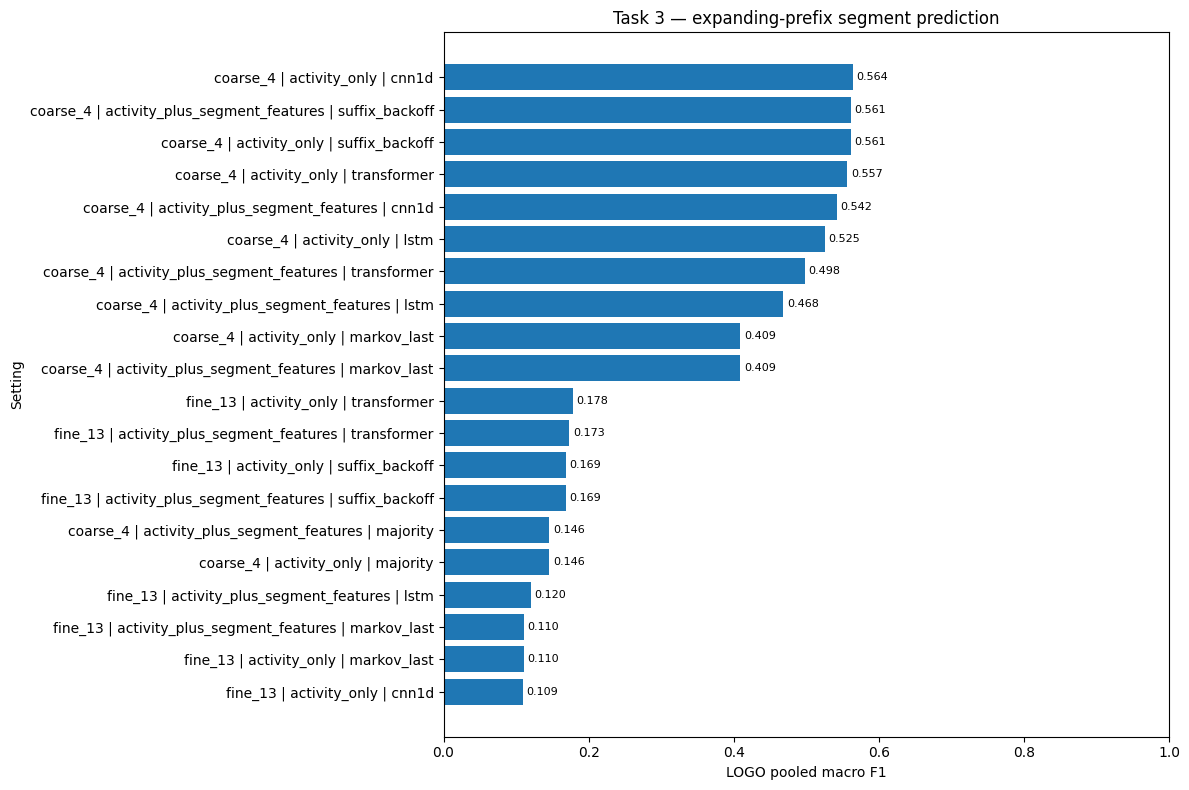

Saved plot: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/task3_expanding_prefix_segment_prediction_top20_macro_f1.png

Best setting for coarse_4
label_mode               coarse_4
feature_mode        activity_only
predictor                   cnn1d
n_samples                     216
n_groups                        9
n_classes                       4
accuracy                 0.657407
macro_f1                 0.564228
weighted_f1              0.683818
max_prefix_len                 37
max_epochs                     80
max_suffix_order                0


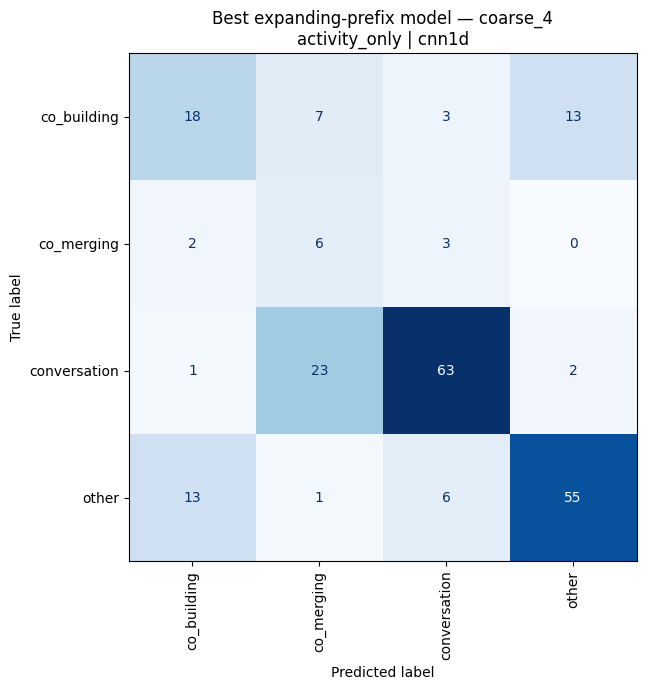

Saved confusion matrix: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/task3_expanding_prefix_segment_prediction_coarse_4_best_confusion_matrix.png

Best setting for fine_13
label_mode                fine_13
feature_mode        activity_only
predictor             transformer
n_samples                     287
n_groups                        9
n_classes                      13
accuracy                 0.254355
macro_f1                 0.178022
weighted_f1               0.27388
max_prefix_len                 51
max_epochs                     80
max_suffix_order                0


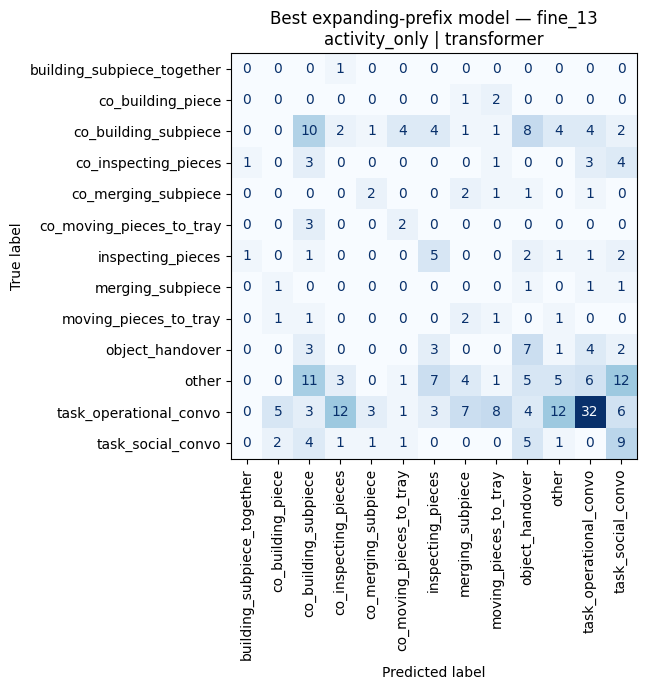

Saved confusion matrix: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/task3_expanding_prefix_segment_prediction_fine_13_best_confusion_matrix.png

AUTOMATIC INTERPRETATION

Label mode: coarse_4
Best overall: activity_only | cnn1d | acc=0.657 | macro-F1=0.564
Best Markov-last: activity_only | acc=0.722 | macro-F1=0.409
Best suffix-backoff: activity_only | acc=0.708 | macro-F1=0.561

Label mode: fine_13
Best overall: activity_only | transformer | acc=0.254 | macro-F1=0.178
Best Markov-last: activity_only | acc=0.418 | macro-F1=0.110
Best suffix-backoff: activity_only | acc=0.355 | macro-F1=0.169

Interpretation guide:
If the best full-prefix model improves macro-F1 over Markov-last, then longer session history provides useful information beyond only the current activity. If coarse_4 improves much more than fine_13, then fine-grained transition prediction is too sparse, but coarse group-state forecasting is more realistic.


In [33]:
# ============================================================
# TASK 3 — EXPANDING-PREFIX SEGMENT PREDICTION
#
# Goal:
#   Predict the next group-activity segment from the full past
#   activity history of the session so far.
#
# Example:
#   [t1] -> t2
#   [t1, t2] -> t3
#   [t1, t2, t3] -> t4
#   ...
#
# Split:
#   Leave-One-Group-Out
#
# Versions:
#   1. fine_13 labels
#   2. coarse_4 labels
#
# Models:
#   majority
#   Markov-last
#   suffix-backoff Markov
#   LSTM
#   CNN-1D
#   Transformer
# ============================================================

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


# ============================================================
# Paths
# ============================================================

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"

INV_PATH = f"{OUT_DIR}/recognition_interaction_window_label_inventory.csv"
ENG3_FEATURES_PATH = f"{OUT_DIR}/interaction_eng3_features.csv"

RESULT_PREFIX = "task3_expanding_prefix_segment_prediction"


# ============================================================
# Settings
# ============================================================

MIN_WINDOWS = 15

LABEL_MODES_TO_RUN = [
    "coarse_4",
    "fine_13",
]

FEATURE_MODES = [
    "activity_only",
    "activity_plus_segment_features",
]

DEEP_MODELS = [
    "lstm",
    "cnn1d",
    "transformer",
]

MAX_EPOCHS = 80
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
EMB_DIM = 16
HIDDEN_DIM = 64

MAX_SUFFIX_ORDER = 5


# ============================================================
# Load data
# ============================================================

inv_original = pd.read_csv(INV_PATH)
features_df = pd.read_csv(ENG3_FEATURES_PATH)

LABEL_COL = "dominant_normalized_label"

print("=" * 80)
print("TASK 3 — EXPANDING-PREFIX SEGMENT PREDICTION")
print("=" * 80)

print("Inventory rows:", len(inv_original))
print("ENG3 feature rows:", len(features_df))
print("Raw distinct activities:", inv_original[LABEL_COL].nunique())

print("\nTop raw activities:")
print(inv_original[LABEL_COL].value_counts().head(20).to_string())


# ============================================================
# Label preparation
# ============================================================

def normalize_text(x):
    x = str(x).strip().lower()
    x = x.replace(" ", "_")
    return x


def make_fine_13_labels(inv):
    """
    Same fine-grained setup as previous Task 3:
    keep labels with >= MIN_WINDOWS windows, rare labels -> other.
    """
    inv = inv.copy()

    counts = inv[LABEL_COL].value_counts()
    keep = set(counts[counts >= MIN_WINDOWS].index)

    inv["activity_for_prediction"] = inv[LABEL_COL].where(
        inv[LABEL_COL].isin(keep),
        "other"
    )

    return inv


def coarse_4_map(raw_label):
    """
    Coarse group-state mapping.

    Priority:
      co_merging > co_building > conversation > other

    This avoids tiny fine-grained transition classes.
    """
    x = normalize_text(raw_label)

    if "merging" in x or "merge" in x:
        return "co_merging"

    if "building" in x or "build" in x:
        return "co_building"

    if "convo" in x or "conversation" in x:
        return "conversation"

    return "other"


def make_coarse_4_labels(inv):
    inv = inv.copy()
    inv["activity_for_prediction"] = inv[LABEL_COL].apply(coarse_4_map)
    return inv


# ============================================================
# Merge helper
# ============================================================

def add_key_columns(d):
    d = d.copy()
    d["group_key"] = d["group"].astype(int)
    d["window_start_key"] = np.round(d["window_start"].astype(float), 6)
    d["window_end_key"] = np.round(d["window_end"].astype(float), 6)
    return d


OPTITRACK_FEATURES = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
]

OPENEAREABLE_FEATURES = [
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

XSENS_FEATURES = [
    "hand_freq_mean",
    "hand_freq_max",
    "hand_power_mean",
    "hand_orient_var",
    "hand_coord",
    "xsens_available",
]

CANDIDATE_FEATURES = (
    OPTITRACK_FEATURES
    + OPENEAREABLE_FEATURES
    + XSENS_FEATURES
)

features_df = add_key_columns(features_df)

SENSOR_FEATURES = [c for c in CANDIDATE_FEATURES if c in features_df.columns]

print("\nSensor features found:", len(SENSOR_FEATURES))
print(SENSOR_FEATURES)


# ============================================================
# Segment construction
# ============================================================

def build_segments_for_label_mode(inv_labelled, label_mode):
    """
    Collapse consecutive same labels into activity segments.
    Each segment receives averaged engineered features.
    """
    inv = inv_labelled.copy()
    inv = add_key_columns(inv)

    merge_cols = [
        "group_key",
        "window_start_key",
        "window_end_key",
    ] + SENSOR_FEATURES

    df = inv.merge(
        features_df[merge_cols],
        on=[
            "group_key",
            "window_start_key",
            "window_end_key",
        ],
        how="left",
        validate="one_to_one",
    )

    df = df.sort_values(["group", "window_start"]).reset_index(drop=True)

    df["prev_activity"] = df.groupby("group")["activity_for_prediction"].shift(1)

    df["new_segment"] = (
        (df["activity_for_prediction"] != df["prev_activity"])
        | (df["prev_activity"].isna())
    )

    df["segment_id_in_group"] = (
        df.groupby("group")["new_segment"]
        .cumsum()
        .astype(int)
    )

    segment_rows = []

    for (g, seg_id), sub in df.groupby(["group", "segment_id_in_group"]):
        sub = sub.sort_values("window_start")

        row = {
            "label_mode": label_mode,
            "group": int(g),
            "segment_id_in_group": int(seg_id),
            "segment_key": f"{int(g)}_{int(seg_id)}",
            "activity": sub["activity_for_prediction"].iloc[0],
            "segment_start": float(sub["window_start"].min()),
            "segment_end": float(sub["window_end"].max()),
            "segment_duration_s": float(sub["window_end"].max() - sub["window_start"].min()),
            "n_windows": int(len(sub)),
        }

        numeric = sub[SENSOR_FEATURES].apply(pd.to_numeric, errors="coerce")
        means = numeric.mean(axis=0, skipna=True)

        for c in SENSOR_FEATURES:
            row[f"full__{c}"] = float(means[c]) if pd.notna(means[c]) else np.nan

        segment_rows.append(row)

    segments = pd.DataFrame(segment_rows).sort_values(
        ["group", "segment_start"]
    ).reset_index(drop=True)

    return segments


# ============================================================
# Build expanding-prefix examples
# ============================================================

def build_prefix_examples(segments):
    """
    For each group:
      [t1] -> t2
      [t1, t2] -> t3
      ...
    """
    label_names = sorted(segments["activity"].unique())
    act_to_id = {a: i for i, a in enumerate(label_names)}
    id_to_act = {i: a for a, i in act_to_id.items()}

    segments = segments.copy()
    segments["activity_id"] = segments["activity"].map(act_to_id)

    numeric_cols = (
        ["segment_duration_s", "n_windows"]
        + [f"full__{c}" for c in SENSOR_FEATURES]
    )

    seq_acts = []
    seq_nums = []
    y = []
    groups = []
    meta_rows = []

    for g, sub in segments.sort_values(["group", "segment_start"]).groupby("group"):
        sub = sub.reset_index(drop=True)

        for i in range(1, len(sub)):
            prefix = sub.iloc[:i]
            target = sub.iloc[i]

            seq_acts.append(prefix["activity_id"].values.astype(np.int64))
            seq_nums.append(prefix[numeric_cols].values.astype(np.float32))
            y.append(int(target["activity_id"]))
            groups.append(int(g))

            meta_rows.append({
                "label_mode": target["label_mode"],
                "group": int(g),
                "target_segment_key": target["segment_key"],
                "target_activity": target["activity"],
                "prefix_len": int(len(prefix)),
                "prefix_activities": " -> ".join(prefix["activity"].tolist()),
            })

    y = np.array(y, dtype=np.int64)
    groups = np.array(groups, dtype=np.int64)
    meta = pd.DataFrame(meta_rows)

    return seq_acts, seq_nums, y, groups, meta, label_names, act_to_id, id_to_act, numeric_cols


# ============================================================
# Padding
# ============================================================

def pad_activity_sequences(seq_acts, max_len, pad_idx):
    X = np.full((len(seq_acts), max_len), pad_idx, dtype=np.int64)
    mask = np.zeros((len(seq_acts), max_len), dtype=bool)

    for i, seq in enumerate(seq_acts):
        L = len(seq)
        X[i, :L] = seq
        mask[i, :L] = True

    return X, mask


def pad_numeric_sequences(seq_nums, max_len, n_numeric):
    X = np.full((len(seq_nums), max_len, n_numeric), np.nan, dtype=np.float32)

    for i, seq in enumerate(seq_nums):
        L = seq.shape[0]
        X[i, :L, :] = seq

    return X


def preprocess_numeric_fold(X_num_train_raw, X_num_test_raw, mask_train, mask_test, use_numeric):
    """
    Fit imputer/scaler only on valid training prefix positions.
    Padding remains zero after transformation.
    """
    if not use_numeric:
        n_train, max_len, _ = X_num_train_raw.shape
        n_test = X_num_test_raw.shape[0]

        return (
            np.zeros((n_train, max_len, 0), dtype=np.float32),
            np.zeros((n_test, max_len, 0), dtype=np.float32),
        )

    n_train, max_len, n_numeric = X_num_train_raw.shape
    n_test = X_num_test_raw.shape[0]

    Xtr = np.zeros((n_train, max_len, n_numeric), dtype=np.float32)
    Xte = np.zeros((n_test, max_len, n_numeric), dtype=np.float32)

    train_valid = X_num_train_raw[mask_train]
    test_valid = X_num_test_raw[mask_test]

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    train_valid_imp = imputer.fit_transform(train_valid)
    train_valid_scaled = scaler.fit_transform(train_valid_imp)

    test_valid_imp = imputer.transform(test_valid)
    test_valid_scaled = scaler.transform(test_valid_imp)

    Xtr[mask_train] = train_valid_scaled.astype(np.float32)
    Xte[mask_test] = test_valid_scaled.astype(np.float32)

    return Xtr, Xte


# ============================================================
# Dataset
# ============================================================

class PrefixDataset(torch.utils.data.Dataset):
    def __init__(self, X_act, X_num, mask, y):
        self.X_act = torch.tensor(X_act, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_act[idx], self.X_num[idx], self.mask[idx], self.y[idx]


# ============================================================
# Models
# ============================================================

class PrefixLSTM(nn.Module):
    def __init__(self, n_classes, pad_idx, n_numeric, emb_dim=16, hidden_dim=64, dropout=0.2):
        super().__init__()

        self.emb = nn.Embedding(
            n_classes + 1,
            emb_dim,
            padding_idx=pad_idx,
        )

        self.use_numeric = n_numeric > 0

        if self.use_numeric:
            self.num_proj = nn.Sequential(
                nn.Linear(n_numeric, emb_dim),
                nn.ReLU(),
            )
            input_dim = emb_dim * 2
        else:
            input_dim = emb_dim

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x_act, x_num, mask):
        e = self.emb(x_act)

        if self.use_numeric:
            n = self.num_proj(x_num)
            x = torch.cat([e, n], dim=-1)
        else:
            x = e

        out, _ = self.lstm(x)

        lengths = mask.sum(dim=1).clamp(min=1)
        idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, out.shape[-1])
        h_last = out.gather(1, idx).squeeze(1)

        return self.head(h_last)


class PrefixCNN1D(nn.Module):
    def __init__(self, n_classes, pad_idx, n_numeric, emb_dim=16, hidden_dim=64, dropout=0.2):
        super().__init__()

        self.emb = nn.Embedding(
            n_classes + 1,
            emb_dim,
            padding_idx=pad_idx,
        )

        self.use_numeric = n_numeric > 0

        if self.use_numeric:
            self.num_proj = nn.Sequential(
                nn.Linear(n_numeric, emb_dim),
                nn.ReLU(),
            )
            input_dim = emb_dim * 2
        else:
            input_dim = emb_dim

        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x_act, x_num, mask):
        e = self.emb(x_act)

        if self.use_numeric:
            n = self.num_proj(x_num)
            x = torch.cat([e, n], dim=-1)
        else:
            x = e

        # B x L x D -> B x D x L
        x = x.transpose(1, 2)

        h = self.conv(x)

        # mask padded positions before max pooling
        mask_for_pool = mask.unsqueeze(1)
        h = h.masked_fill(~mask_for_pool, -1e9)

        h_pool = h.max(dim=-1).values

        return self.head(h_pool)


class PrefixTransformer(nn.Module):
    def __init__(self, n_classes, pad_idx, n_numeric, max_len, emb_dim=16, hidden_dim=64, n_heads=4, dropout=0.2):
        super().__init__()

        self.emb = nn.Embedding(
            n_classes + 1,
            emb_dim,
            padding_idx=pad_idx,
        )

        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, emb_dim))

        self.use_numeric = n_numeric > 0

        if self.use_numeric:
            self.num_proj = nn.Sequential(
                nn.Linear(n_numeric, emb_dim),
                nn.ReLU(),
            )
            input_dim = emb_dim * 2
        else:
            input_dim = emb_dim

        heads = n_heads if input_dim % n_heads == 0 else 1

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=heads,
            dim_feedforward=hidden_dim * 2,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1,
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, n_classes),
        )

    def forward(self, x_act, x_num, mask):
        e = self.emb(x_act)
        e = e + self.pos_emb[:, :e.shape[1], :]

        if self.use_numeric:
            n = self.num_proj(x_num)
            x = torch.cat([e, n], dim=-1)
        else:
            x = e

        padding_mask = ~mask

        h = self.encoder(
            x,
            src_key_padding_mask=padding_mask,
        )

        lengths = mask.sum(dim=1).clamp(min=1)
        idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, h.shape[-1])
        h_last = h.gather(1, idx).squeeze(1)

        return self.head(h_last)


def build_deep_model(model_name, n_classes, pad_idx, n_numeric, max_len):
    if model_name == "lstm":
        return PrefixLSTM(
            n_classes=n_classes,
            pad_idx=pad_idx,
            n_numeric=n_numeric,
            emb_dim=EMB_DIM,
            hidden_dim=HIDDEN_DIM,
        )

    if model_name == "cnn1d":
        return PrefixCNN1D(
            n_classes=n_classes,
            pad_idx=pad_idx,
            n_numeric=n_numeric,
            emb_dim=EMB_DIM,
            hidden_dim=HIDDEN_DIM,
        )

    if model_name == "transformer":
        return PrefixTransformer(
            n_classes=n_classes,
            pad_idx=pad_idx,
            n_numeric=n_numeric,
            max_len=max_len,
            emb_dim=EMB_DIM,
            hidden_dim=HIDDEN_DIM,
        )

    raise ValueError(model_name)


# ============================================================
# Baselines
# ============================================================

def predict_majority(y_train, n_test):
    maj = Counter(y_train.tolist()).most_common(1)[0][0]
    return np.array([maj] * n_test, dtype=np.int64)


def predict_markov_last(X_act_train, y_train, X_act_test, pad_idx):
    table = defaultdict(Counter)

    for x, target in zip(X_act_train, y_train):
        valid = x[x != pad_idx]
        if len(valid) == 0:
            continue
        last = int(valid[-1])
        table[last][int(target)] += 1

    fallback = Counter(y_train.tolist()).most_common(1)[0][0]

    preds = []

    for x in X_act_test:
        valid = x[x != pad_idx]
        if len(valid) == 0:
            preds.append(fallback)
            continue

        last = int(valid[-1])

        if last in table and len(table[last]) > 0:
            preds.append(table[last].most_common(1)[0][0])
        else:
            preds.append(fallback)

    return np.array(preds, dtype=np.int64)


def train_suffix_tables(X_act_train, y_train, pad_idx, max_order=5):
    """
    Variable-order Markov / suffix-backoff model.

    It stores:
      last 1 item -> next
      last 2 items -> next
      ...
      last max_order items -> next

    Prediction uses the longest suffix seen during training.
    """
    tables = {
        k: defaultdict(Counter)
        for k in range(1, max_order + 1)
    }

    for x, target in zip(X_act_train, y_train):
        valid = tuple([int(v) for v in x if int(v) != pad_idx])

        for k in range(1, min(max_order, len(valid)) + 1):
            key = valid[-k:]
            tables[k][key][int(target)] += 1

    fallback = Counter(y_train.tolist()).most_common(1)[0][0]

    return tables, fallback


def predict_suffix_backoff(X_act_test, tables, fallback, pad_idx, max_order=5):
    preds = []

    for x in X_act_test:
        valid = tuple([int(v) for v in x if int(v) != pad_idx])

        pred = fallback

        for k in range(min(max_order, len(valid)), 0, -1):
            key = valid[-k:]

            if key in tables[k] and len(tables[k][key]) > 0:
                pred = tables[k][key].most_common(1)[0][0]
                break

        preds.append(pred)

    return np.array(preds, dtype=np.int64)


# ============================================================
# Deep training
# ============================================================

def train_eval_deep(
    model_name,
    X_act_train,
    X_num_train,
    mask_train,
    y_train,
    X_act_test,
    X_num_test,
    mask_test,
    y_test,
    n_classes,
    pad_idx,
    max_len,
):
    n_numeric = X_num_train.shape[-1]

    model = build_deep_model(
        model_name=model_name,
        n_classes=n_classes,
        pad_idx=pad_idx,
        n_numeric=n_numeric,
        max_len=max_len,
    ).to(device)

    class_counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)

    class_weights = np.zeros(n_classes, dtype=np.float32)

    nonzero = class_counts > 0
    class_weights[nonzero] = class_counts.sum() / class_counts[nonzero]

    if class_weights[nonzero].mean() > 0:
        class_weights[nonzero] = class_weights[nonzero] / class_weights[nonzero].mean()

    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32).to(device)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    train_ds = PrefixDataset(
        X_act_train,
        X_num_train,
        mask_train,
        y_train,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False,
    )

    model.train()

    for epoch in range(MAX_EPOCHS):
        for xb_act, xb_num, xb_mask, yb in train_loader:
            xb_act = xb_act.to(device)
            xb_num = xb_num.to(device)
            xb_mask = xb_mask.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb_act, xb_num, xb_mask)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    model.eval()

    test_ds = PrefixDataset(
        X_act_test,
        X_num_test,
        mask_test,
        y_test,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
    )

    preds = []

    with torch.no_grad():
        for xb_act, xb_num, xb_mask, yb in test_loader:
            xb_act = xb_act.to(device)
            xb_num = xb_num.to(device)
            xb_mask = xb_mask.to(device)

            logits = model(xb_act, xb_num, xb_mask)
            pred = logits.argmax(dim=1).cpu().numpy()
            preds.extend(pred.tolist())

    return np.array(preds, dtype=np.int64)


# ============================================================
# Scoring
# ============================================================

def score_predictions(y_true, y_pred, labels):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(
            y_true,
            y_pred,
            labels=labels,
            average="macro",
            zero_division=0,
        )),
        "weighted_f1": float(f1_score(
            y_true,
            y_pred,
            labels=labels,
            average="weighted",
            zero_division=0,
        )),
    }


# ============================================================
# Main experiment
# ============================================================

all_summary = []
all_predictions = []

for label_mode in LABEL_MODES_TO_RUN:

    print("\n" + "#" * 100)
    print(f"LABEL MODE: {label_mode}")
    print("#" * 100)

    if label_mode == "fine_13":
        inv_labelled = make_fine_13_labels(inv_original)

    elif label_mode == "coarse_4":
        inv_labelled = make_coarse_4_labels(inv_original)

    else:
        raise ValueError(label_mode)

    print("\nWindow-level label counts:")
    print(inv_labelled["activity_for_prediction"].value_counts().to_string())

    segments = build_segments_for_label_mode(inv_labelled, label_mode)

    print("\nTotal segments:", len(segments))
    print("Segments per group:")
    print(segments.groupby("group").size().to_string())

    print("\nSegment label counts:")
    print(segments["activity"].value_counts().to_string())

    (
        seq_acts,
        seq_nums,
        y,
        groups,
        meta,
        label_names,
        act_to_id,
        id_to_act,
        numeric_cols,
    ) = build_prefix_examples(segments)

    n_classes = len(label_names)
    labels_ids = list(range(n_classes))
    pad_idx = n_classes
    max_len = max(len(s) for s in seq_acts)
    n_numeric = len(numeric_cols)

    print("\nExpanding-prefix examples:", len(y))
    print("Max prefix length:", max_len)
    print("Number of classes:", n_classes)
    print("Classes:", label_names)

    print("\nTarget counts:")
    print(pd.Series([id_to_act[int(i)] for i in y]).value_counts().to_string())

    X_act_all, mask_all = pad_activity_sequences(
        seq_acts,
        max_len=max_len,
        pad_idx=pad_idx,
    )

    X_num_all_raw = pad_numeric_sequences(
        seq_nums,
        max_len=max_len,
        n_numeric=n_numeric,
    )

    for feature_mode in FEATURE_MODES:

        use_numeric = feature_mode == "activity_plus_segment_features"

        if not use_numeric:
            print(f"\nFeature mode: {feature_mode} | using activity sequence only")
        else:
            print(f"\nFeature mode: {feature_mode} | using activity sequence + {n_numeric} numeric segment features")

        predictors = [
            "majority",
            "markov_last",
            "suffix_backoff",
        ] + DEEP_MODELS

        for predictor in predictors:

            print("\n" + "=" * 100)
            print(f"label_mode={label_mode} | feature_mode={feature_mode} | predictor={predictor}")
            print("=" * 100)

            y_true_all = []
            y_pred_all = []
            held_group_all = []
            row_meta_all = []

            logo = LeaveOneGroupOut()

            for fold, (tr, te) in enumerate(
                logo.split(X_act_all, y, groups),
                start=1,
            ):
                held_group = int(groups[te][0])

                X_act_train = X_act_all[tr]
                X_act_test = X_act_all[te]

                mask_train = mask_all[tr]
                mask_test = mask_all[te]

                X_num_train_raw = X_num_all_raw[tr]
                X_num_test_raw = X_num_all_raw[te]

                y_train = y[tr]
                y_test = y[te]

                X_num_train, X_num_test = preprocess_numeric_fold(
                    X_num_train_raw,
                    X_num_test_raw,
                    mask_train,
                    mask_test,
                    use_numeric=use_numeric,
                )

                if predictor == "majority":
                    y_pred = predict_majority(
                        y_train,
                        n_test=len(y_test),
                    )

                elif predictor == "markov_last":
                    y_pred = predict_markov_last(
                        X_act_train,
                        y_train,
                        X_act_test,
                        pad_idx=pad_idx,
                    )

                elif predictor == "suffix_backoff":
                    tables, fallback = train_suffix_tables(
                        X_act_train,
                        y_train,
                        pad_idx=pad_idx,
                        max_order=MAX_SUFFIX_ORDER,
                    )

                    y_pred = predict_suffix_backoff(
                        X_act_test,
                        tables,
                        fallback,
                        pad_idx=pad_idx,
                        max_order=MAX_SUFFIX_ORDER,
                    )

                elif predictor in DEEP_MODELS:
                    y_pred = train_eval_deep(
                        model_name=predictor,
                        X_act_train=X_act_train,
                        X_num_train=X_num_train,
                        mask_train=mask_train,
                        y_train=y_train,
                        X_act_test=X_act_test,
                        X_num_test=X_num_test,
                        mask_test=mask_test,
                        y_test=y_test,
                        n_classes=n_classes,
                        pad_idx=pad_idx,
                        max_len=max_len,
                    )

                else:
                    raise ValueError(predictor)

                fold_scores = score_predictions(
                    y_test,
                    y_pred,
                    labels=labels_ids,
                )

                print(
                    f"Fold {fold} | group={held_group} | "
                    f"acc={fold_scores['accuracy']:.3f} | "
                    f"macroF1={fold_scores['macro_f1']:.3f} | "
                    f"n={len(y_test)}"
                )

                y_true_all.extend(y_test.tolist())
                y_pred_all.extend(y_pred.tolist())
                held_group_all.extend([held_group] * len(y_test))
                row_meta_all.extend(meta.iloc[te].to_dict("records"))

            y_true_all = np.array(y_true_all, dtype=np.int64)
            y_pred_all = np.array(y_pred_all, dtype=np.int64)

            pooled = score_predictions(
                y_true_all,
                y_pred_all,
                labels=labels_ids,
            )

            all_summary.append({
                "label_mode": label_mode,
                "feature_mode": feature_mode,
                "predictor": predictor,
                "n_samples": int(len(y_true_all)),
                "n_groups": int(len(np.unique(groups))),
                "n_classes": int(n_classes),
                "accuracy": pooled["accuracy"],
                "macro_f1": pooled["macro_f1"],
                "weighted_f1": pooled["weighted_f1"],
                "max_prefix_len": int(max_len),
                "max_epochs": int(MAX_EPOCHS) if predictor in DEEP_MODELS else 0,
                "max_suffix_order": int(MAX_SUFFIX_ORDER) if predictor == "suffix_backoff" else 0,
            })

            for m, yt, yp, hg in zip(
                row_meta_all,
                y_true_all,
                y_pred_all,
                held_group_all,
            ):
                all_predictions.append({
                    "label_mode": label_mode,
                    "feature_mode": feature_mode,
                    "predictor": predictor,
                    "held_group": int(hg),
                    "prefix_len": int(m["prefix_len"]),
                    "prefix_activities": m["prefix_activities"],
                    "true_activity": id_to_act[int(yt)],
                    "predicted_activity": id_to_act[int(yp)],
                    "correct": bool(int(yt) == int(yp)),
                })

            print("\nPOOLED:")
            print(
                f"accuracy={pooled['accuracy']:.3f} | "
                f"macroF1={pooled['macro_f1']:.3f} | "
                f"weightedF1={pooled['weighted_f1']:.3f}"
            )


# ============================================================
# Results
# ============================================================

summary_df = pd.DataFrame(all_summary).sort_values(
    ["label_mode", "macro_f1"],
    ascending=[True, False],
)

pred_df = pd.DataFrame(all_predictions)

print("\n" + "=" * 100)
print("EXPANDING-PREFIX SEGMENT PREDICTION SUMMARY")
print("=" * 100)
display(summary_df.round(3))

print("\nMacro-F1 pivot:")
pivot = summary_df.pivot_table(
    index=["label_mode", "feature_mode"],
    columns="predictor",
    values="macro_f1",
)
display(pivot.round(3))


# ============================================================
# Save outputs
# ============================================================

summary_path = f"{OUT_DIR}/{RESULT_PREFIX}_summary.csv"
pred_path = f"{OUT_DIR}/{RESULT_PREFIX}_predictions.csv"
pivot_path = f"{OUT_DIR}/{RESULT_PREFIX}_macro_f1_pivot.csv"

summary_df.to_csv(summary_path, index=False)
pred_df.to_csv(pred_path, index=False)
pivot.to_csv(pivot_path)

print("\nSaved:")
print(summary_path)
print(pred_path)
print(pivot_path)


# ============================================================
# Plot top results
# ============================================================

plot_df = summary_df.copy()

plot_df["setting"] = (
    plot_df["label_mode"]
    + " | "
    + plot_df["feature_mode"]
    + " | "
    + plot_df["predictor"]
)

plot_top = plot_df.sort_values("macro_f1", ascending=True).tail(20)

plt.figure(figsize=(12, 8))
plt.barh(plot_top["setting"], plot_top["macro_f1"])
plt.xlabel("LOGO pooled macro F1")
plt.ylabel("Setting")
plt.title("Task 3 — expanding-prefix segment prediction")

for i, v in enumerate(plot_top["macro_f1"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

plt.xlim(0, 1)
plt.tight_layout()

plot_path = f"{OUT_DIR}/{RESULT_PREFIX}_top20_macro_f1.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)


# ============================================================
# Confusion matrix for best result in each label mode
# ============================================================

for label_mode in summary_df["label_mode"].unique():

    best = (
        summary_df[summary_df["label_mode"] == label_mode]
        .sort_values("macro_f1", ascending=False)
        .iloc[0]
    )

    best_feature_mode = best["feature_mode"]
    best_predictor = best["predictor"]

    print("\nBest setting for", label_mode)
    print(best.round(3).to_string())

    best_preds = pred_df[
        (pred_df["label_mode"] == label_mode)
        & (pred_df["feature_mode"] == best_feature_mode)
        & (pred_df["predictor"] == best_predictor)
    ].copy()

    labels_for_cm = sorted(best_preds["true_activity"].unique())

    cm = confusion_matrix(
        best_preds["true_activity"],
        best_preds["predicted_activity"],
        labels=labels_for_cm,
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels_for_cm,
    )

    disp.plot(
        ax=ax,
        xticks_rotation=90,
        cmap="Blues",
        colorbar=False,
    )

    plt.title(
        f"Best expanding-prefix model — {label_mode}\n"
        + f"{best_feature_mode} | {best_predictor}"
    )

    plt.tight_layout()

    cm_path = f"{OUT_DIR}/{RESULT_PREFIX}_{label_mode}_best_confusion_matrix.png"
    plt.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved confusion matrix:", cm_path)


# ============================================================
# Automatic interpretation
# ============================================================

print("\n" + "=" * 100)
print("AUTOMATIC INTERPRETATION")
print("=" * 100)

for label_mode in summary_df["label_mode"].unique():

    sub = summary_df[summary_df["label_mode"] == label_mode].copy()
    best = sub.sort_values("macro_f1", ascending=False).iloc[0]

    best_markov = sub[sub["predictor"] == "markov_last"].sort_values(
        "macro_f1",
        ascending=False,
    ).iloc[0]

    best_suffix = sub[sub["predictor"] == "suffix_backoff"].sort_values(
        "macro_f1",
        ascending=False,
    ).iloc[0]

    print("\nLabel mode:", label_mode)

    print(
        f"Best overall: {best['feature_mode']} | {best['predictor']} | "
        f"acc={best['accuracy']:.3f} | macro-F1={best['macro_f1']:.3f}"
    )

    print(
        f"Best Markov-last: {best_markov['feature_mode']} | "
        f"acc={best_markov['accuracy']:.3f} | macro-F1={best_markov['macro_f1']:.3f}"
    )

    print(
        f"Best suffix-backoff: {best_suffix['feature_mode']} | "
        f"acc={best_suffix['accuracy']:.3f} | macro-F1={best_suffix['macro_f1']:.3f}"
    )

print("\nInterpretation guide:")
print(
    "If the best full-prefix model improves macro-F1 over Markov-last, "
    "then longer session history provides useful information beyond only the current activity. "
    "If coarse_4 improves much more than fine_13, then fine-grained transition prediction is too sparse, "
    "but coarse group-state forecasting is more realistic."
)


In [34]:
# Add held-out-group mean ± SD to the expanding-prefix results.
prefix_fold_rows = []

for (label_mode, feature_mode, predictor), subset in pred_df.groupby(
    ['label_mode', 'feature_mode', 'predictor']
):
    labels = sorted(subset['true_activity'].astype(str).unique())
    for held_group, group_df in subset.groupby('held_group'):
        prefix_fold_rows.append({
            'label_mode': label_mode,
            'feature_mode': feature_mode,
            'predictor': predictor,
            'held_group': held_group,
            'n': len(group_df),
            'accuracy': accuracy_score(
                group_df['true_activity'], group_df['predicted_activity']
            ),
            'macro_f1': f1_score(
                group_df['true_activity'],
                group_df['predicted_activity'],
                labels=labels,
                average='macro',
                zero_division=0,
            ),
        })

prefix_fold_metrics = pd.DataFrame(prefix_fold_rows)
prefix_std = (
    prefix_fold_metrics
    .groupby(['label_mode', 'feature_mode', 'predictor'], as_index=False)
    .agg(
        fold_accuracy_mean=('accuracy', 'mean'),
        fold_accuracy_std=('accuracy', 'std'),
        fold_macro_f1_mean=('macro_f1', 'mean'),
        fold_macro_f1_std=('macro_f1', 'std'),
        n_folds=('held_group', 'nunique'),
    )
)
prefix_std.to_csv(
    f'{OUT_DIR}/{RESULT_PREFIX}_fold_std.csv',
    index=False,
)
display(prefix_std.sort_values('fold_macro_f1_mean', ascending=False).head(20).round(4))


,label_mode,feature_mode,predictor,fold_accuracy_mean,fold_accuracy_std,fold_macro_f1_mean,fold_macro_f1_std,n_folds
5,coarse_4,activity_only,transformer,0.6790,0.1377,0.5218,0.1057,9
4,coarse_4,activity_only,suffix_backoff,0.7152,0.1247,0.5059,0.0863,9
10,coarse_4,activity_plus_segment_features,suffix_backoff,0.7152,0.1247,0.5059,0.0863,9
0,coarse_4,activity_only,cnn1d,0.6702,0.1505,0.5028,0.0769,9
1,coarse_4,activity_only,lstm,0.6776,0.1526,0.4967,0.1038,9
6,coarse_4,activity_plus_segment_features,cnn1d,0.6562,0.1783,0.4828,0.0913,9
11,coarse_4,activity_plus_segment_features,transformer,0.5977,0.1804,0.4189,0.1096,9
7,coarse_4,activity_plus_segment_features,lstm,0.5838,0.1369,0.4159,0.0802,9
9,coarse_4,activity_plus_segment_features,markov_last,0.7001,0.1460,0.3952,0.0613,9
3,coarse_4,activity_only,markov_last,0.7001,0.1460,0.3952,0.0613,9


# Optional Appendix D — HMM and collective-state analyses

These cells reproduce the report's 3-class transition-only HMM and 5-class collective-state HMM analyses. Viterbi results are smoothing results and must not be described as causal next-state prediction.

In [35]:
# ================================================================
# RQ3 — HMM NEXT-ACTIVITY PREDICTION (headline = TRANSITION-ONLY)
# Rivals: repeat-last, Markov (argmax next), Markov-transition (argmax
#         next DIFFERENT state = the fair opponent at switch points).
# Supervised HMM: states = activities; transitions learned; Gaussian
# emissions on a richer robust feature set. LOGO, no leakage.
# ================================================================
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
try:
    from hmmlearn import hmm
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable,"-m","pip","install","-q","hmmlearn"]); from hmmlearn import hmm

PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"
CORE = ["co_building","co_merging","conversation"]
df = pd.read_csv(PATH)
df = df[df["recognition_label"].isin(CORE)].sort_values(["group","window_start"]).reset_index(drop=True)

# richer emission set (still modest — HMMs overfit on hundreds of features)
cand = ["dist_close_mean","dist_close_min","dist_mid_mean","dist_far_mean","dist_disp_mean",
        "dist_disp_std","centroid_speed","speed_max","accE_min","accE_mid","accE_max",
        "gyrE_min","gyrE_mid","gyrE_max","move_coord","hand_freq_mean","hand_freq_max",
        "hand_power_mean","hand_orient_var","hand_coord"]
EMIT = [c for c in cand if c in df.columns]
print("emission features:", len(EMIT), EMIT)

classes = CORE; cls2i={c:i for i,c in enumerate(classes)}; n=len(classes)

def fit_hmm(train):
    A=np.ones((n,n)); start=np.ones(n)
    for g,s in train.groupby("group"):
        seq=[cls2i[l] for l in s["recognition_label"].values]
        start[seq[0]]+=1
        for a,b in zip(seq[:-1],seq[1:]): A[a,b]+=1
    A=A/A.sum(1,keepdims=True); start=start/start.sum()
    X=train[EMIT].values
    means=np.vstack([X[train["recognition_label"].values==c].mean(0) for c in classes])
    covs =np.vstack([X[train["recognition_label"].values==c].var(0)[None]+1e-3 for c in classes])
    m=hmm.GaussianHMM(n_components=n,covariance_type="diag",init_params="",params="")
    m.startprob_=start; m.transmat_=A; m.means_=means; m.covars_=covs
    return m

y=df["recognition_label"].values; groups=df["group"].values; logo=LeaveOneGroupOut()
P={k:[] for k in ["HMM","Markov","Markov_transition","repeat_last"]}
Ptr={k:[] for k in P}; truth_all=[]; truth_tr=[]

for tr,te in logo.split(df,y,groups):
    train,test=df.iloc[tr].copy(),df.iloc[te].copy()
    imp=SimpleImputer(strategy="median").fit(train[EMIT])
    sc=StandardScaler().fit(imp.transform(train[EMIT]))
    train[EMIT]=sc.transform(imp.transform(train[EMIT]))
    tf=sc.transform(imp.transform(test[EMIT]))
    model=fit_hmm(train); A=model.transmat_
    # "most likely DIFFERENT next state" per current state (fair transition rival)
    A_off=A.copy(); np.fill_diagonal(A_off,-1); diff_next=np.argmax(A_off,axis=1)
    for g,s in test.groupby("group"):
        loc=[test.index.get_loc(i) for i in s.index]
        Xseq=tf[loc]; seq=[cls2i[l] for l in s["recognition_label"].values]
        post=model.predict_proba(Xseq); hmm_next=np.argmax(post@A,axis=1)
        for j in range(len(seq)-1):
            cur,nt=seq[j],seq[j+1]; true=classes[nt]
            preds={"HMM":classes[hmm_next[j]],"Markov":classes[np.argmax(A[cur])],
                   "Markov_transition":classes[diff_next[cur]],"repeat_last":classes[cur]}
            for k in P: P[k].append(preds[k])
            truth_all.append(true)
            if nt!=cur:
                for k in Ptr: Ptr[k].append(preds[k])
                truth_tr.append(true)

def rep(name,preds,truth):
    yt,yp=np.array(truth),np.array(preds)
    return dict(model=name,n=len(yt),acc=round(accuracy_score(yt,yp),3),
                macroF1=round(f1_score(yt,yp,average="macro",zero_division=0),3))

print("\n=== TRANSITION-ONLY  (THE HEADLINE — can it call the switches?) ===")
print(pd.DataFrame([rep(k,Ptr[k],truth_tr) for k in ["repeat_last","Markov","Markov_transition","HMM"]]).to_string(index=False))
print("\n=== ALL windows (dominated by persistence — context only) ===")
print(pd.DataFrame([rep(k,P[k],truth_all) for k in ["repeat_last","Markov","Markov_transition","HMM"]]).to_string(index=False))
print("\nHMM transition-only confusion (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(truth_tr,Ptr["HMM"],labels=classes),index=classes,columns=classes).to_string())


emission features: 20 ['dist_close_mean', 'dist_close_min', 'dist_mid_mean', 'dist_far_mean', 'dist_disp_mean', 'dist_disp_std', 'centroid_speed', 'speed_max', 'accE_min', 'accE_mid', 'accE_max', 'gyrE_min', 'gyrE_mid', 'gyrE_max', 'move_coord', 'hand_freq_mean', 'hand_freq_max', 'hand_power_mean', 'hand_orient_var', 'hand_coord']

=== TRANSITION-ONLY  (THE HEADLINE — can it call the switches?) ===
            model  n   acc  macroF1
      repeat_last 79 0.000    0.000
           Markov 79 0.000    0.000
Markov_transition 79 0.886    0.627
              HMM 79 0.304    0.301

=== ALL windows (dominated by persistence — context only) ===
            model    n   acc  macroF1
      repeat_last 1773 0.955    0.955
           Markov 1773 0.955    0.955
Markov_transition 1773 0.039    0.029
              HMM 1773 0.496    0.492

HMM transition-only confusion (rows=true, cols=pred):
              co_building  co_merging  conversation
co_building             9          15            12
co_mer

windows: 759 | target dist: {'individual_phase': 211, 'conversation': 193, 'co_building': 179, 'other_collective': 98, 'co_merging': 78}
examples: 732

=== 5-class collective-state: LogReg vs HMM (30s, LOGO) ===
                  model   acc  macroF1
        LogReg (before) 0.582    0.579
HMM causal (prediction) 0.585    0.546
HMM Viterbi (smoothing) 0.643    0.599

per-class F1:
           state  LogReg  HMM_causal  HMM_viterbi
individual_phase    0.59        0.60         0.67
    conversation    0.43        0.42         0.48
     co_building    0.78        0.77         0.81
      co_merging    0.87        0.84         0.89
other_collective    0.23        0.10         0.13

learned transition matrix (rows=from, cols=to):
                  individual_phase  conversation  co_building  co_merging  other_collective
individual_phase             0.646         0.155        0.024       0.005             0.170
conversation                 0.195         0.541        0.114       0.022           

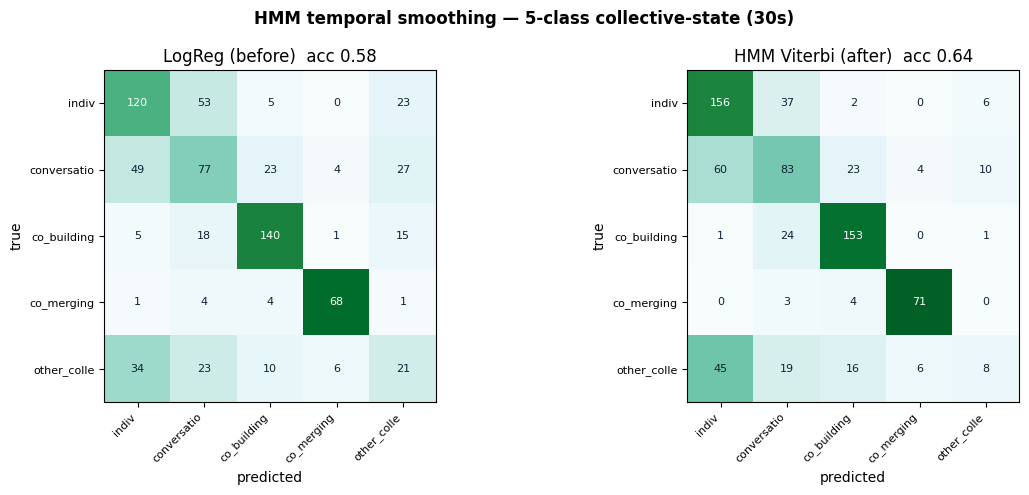

In [36]:
# ================================================================
# ONE-CELL: 5-class collective-state prediction + HMM (30s, LOGO)
# Self-contained: rebuilds TL_30 from Drive, LogReg baseline, then HMM
# (transitions learned from train groups; LogReg probs as emissions;
#  causal filter = honest prediction, Viterbi = smoothing/analysis).
# Needs only: Google Drive mounted.
# ================================================================
import pandas as pd, numpy as np, glob, os, re, matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
GROUPS=[1,2,3,5,6,7,8,9,10]; WIN=30.0; K=3
IND=["label_Participant1","label_Participant2","label_Participant3"]
PAIR=["label_Participant1_Participant2","label_Participant1_Participant3","label_Participant2_Participant3"]
WG="label_Whole_Group"; ALL_TIERS=IND+PAIR+[WG]
TYPO={"object_handiver":"object_handover"}
def norm(x):
    x=str(x).strip().lower(); x=re.split(r"[+|/]",x)[0].strip(); return TYPO.get(x,x)
def to_coll(label):
    a=norm(label)
    if a in ("co_building_subpiece","co_building_piece","building_subpiece_together","co_building"): return "co_building"
    if a in ("co_merging_subpiece","merging_subpiece","co_merging"): return "co_merging"
    if a in ("task_operational_convo","task_social_convo","task_related_convo","task_related_social_convo","non_task_convo"): return "conversation"
    return "other_collective"
def nonempty(s):
    s=s.astype(str).str.strip(); return (s!="")&(s.str.lower()!="nan")&(s.str.lower()!="none")
def find(g):
    c=glob.glob(os.path.join(INPUT_DIR,f"group_{g}_openearable_model_ready.csv")); return c[0] if c else None
def dominant(series):
    s=series[nonempty(series)]; return s.mode().iloc[0] if len(s) else None

# ---- rebuild TL_30 ----
recs=[]
for g in GROUPS:
    f=find(g)
    if not f: continue
    d=pd.read_csv(f,low_memory=False); d["t"]=pd.to_numeric(d["video_time_s"],errors="coerce"); d=d.dropna(subset=["t"])
    t0,t1=d["t"].min(),d["t"].max()
    for ws in np.arange(t0,t1-WIN+1e-9,WIN):
        m=(d["t"]>=ws)&(d["t"]<ws+WIN)
        if m.sum()==0: continue
        sub=d[m]
        wg=dominant(sub[WG]) if WG in sub else None
        if wg is not None: state=to_coll(wg)
        else:
            pl=None
            for pt in PAIR:
                if pt in sub:
                    x=dominant(sub[pt])
                    if x is not None: pl=x; break
            state="individual_phase" if pl is None else to_coll(pl)
        feat={tcol:(norm(dominant(sub[tcol])) if (tcol in sub and dominant(sub[tcol]) is not None) else "none") for tcol in ALL_TIERS}
        recs.append({"group":g,"win_start":ws,"state":state,**feat})
TL=pd.DataFrame(recs)
KEEP={"individual_phase","conversation","co_building","co_merging"}
TL["state"]=TL["state"].where(TL["state"].isin(KEEP),"other_collective")
CL=["individual_phase","conversation","co_building","co_merging","other_collective"]
n=len(CL); cls2i={c:i for i,c in enumerate(CL)}; EPS=1e-9
print("windows:",len(TL),"| target dist:",TL["state"].value_counts().to_dict())

# ---- build supervised examples (prev K tier-labels + prev_state -> next state) ----
rows=[]; Y=[]; G=[]; ORD=[]
for g,sub in TL.groupby("group"):
    sub=sub.sort_values("win_start").reset_index(drop=True)
    for i in range(K,len(sub)):
        feat={f"{t}__lag{lag}":sub.iloc[i-lag][t] for lag in range(1,K+1) for t in ALL_TIERS}
        feat["prev_state"]=sub.iloc[i-1]["state"]
        rows.append(feat); Y.append(sub.iloc[i]["state"]); G.append(g); ORD.append((g,i))
Xdf=pd.DataFrame(rows).fillna("none"); Y=np.array(Y); G=np.array(G); order=pd.DataFrame(ORD,columns=["group","pos"])
print("examples:",len(Xdf))

# ---- HMM helpers ----
def learn(seqs):
    A=np.ones((n,n)); st=np.ones(n)
    for s in seqs:
        idx=[cls2i[x] for x in s]; st[idx[0]]+=1
        for a,b in zip(idx[:-1],idx[1:]): A[a,b]+=1
    return A/A.sum(1,keepdims=True), st/st.sum()
def causal(lp,A,st):
    T=len(lp); out=np.zeros(T,int); a=np.log(st+EPS)+lp[0]; out[0]=a.argmax(); pr=a-np.logaddexp.reduce(a)
    for t in range(1,T):
        pred=np.logaddexp.reduce(pr[:,None]+np.log(A+EPS),0); a=pred+lp[t]; out[t]=a.argmax(); pr=a-np.logaddexp.reduce(a)
    return out
def viterbi(lp,A,st):
    T=len(lp); lA=np.log(A+EPS); d=np.log(st+EPS)+lp[0]; bp=np.zeros((T,n),int)
    for t in range(1,T):
        mm=d[:,None]+lA; bp[t]=mm.argmax(0); d=mm.max(0)+lp[t]
    o=np.zeros(T,int); o[-1]=d.argmax()
    for t in range(T-1,0,-1): o[t-1]=bp[t,o[t]]
    return o

# ---- LOGO: LogReg emissions + HMM decode ----
logo=LeaveOneGroupOut(); yt,yp_lr,yp_c,yp_v=[],[],[],[]
for tr,te in logo.split(Xdf,Y,G):
    m=make_pipeline(OneHotEncoder(handle_unknown="ignore"),LogisticRegression(max_iter=3000,class_weight="balanced"))
    m.fit(Xdf.iloc[tr],Y[tr])
    pr=m.predict_proba(Xdf.iloc[te]); pr=pr[:,[list(m.classes_).index(c) for c in CL]]
    base=np.array(CL)[pr.argmax(1)]
    seqs=[Y[tr][order.iloc[tr]["group"].values==g] for g in np.unique(G[tr])]
    A,st=learn(seqs)
    to=order.iloc[te].copy(); to["r"]=np.arange(len(te)); to["yt"]=Y[te]
    for g,s in to.groupby("group"):
        s=s.sort_values("pos"); ri=s["r"].values; lp=np.log(pr[ri]+EPS)
        yt+=list(s["yt"]); yp_lr+=list(base[ri]); yp_c+=[CL[i] for i in causal(lp,A,st)]; yp_v+=[CL[i] for i in viterbi(lp,A,st)]
yt=np.array(yt)
def sc(nm,yp): yp=np.array(yp); return dict(model=nm,acc=round(accuracy_score(yt,yp),3),macroF1=round(f1_score(yt,yp,average="macro",zero_division=0),3))
print("\n=== 5-class collective-state: LogReg vs HMM (30s, LOGO) ===")
print(pd.DataFrame([sc("LogReg (before)",yp_lr),sc("HMM causal (prediction)",yp_c),sc("HMM Viterbi (smoothing)",yp_v)]).to_string(index=False))
print("\nper-class F1:")
print(pd.DataFrame({"state":CL,
  "LogReg":[round(f1_score(yt==c,np.array(yp_lr)==c,zero_division=0),2) for c in CL],
  "HMM_causal":[round(f1_score(yt==c,np.array(yp_c)==c,zero_division=0),2) for c in CL],
  "HMM_viterbi":[round(f1_score(yt==c,np.array(yp_v)==c,zero_division=0),2) for c in CL]}).to_string(index=False))
print("\nlearned transition matrix (rows=from, cols=to):")
A_all,_=learn([Y[G==g] for g in np.unique(G)])
print(pd.DataFrame(A_all.round(3),index=CL,columns=CL).to_string())

fig,ax=plt.subplots(1,2,figsize=(12,5))
for k,(ti,yp) in enumerate([("LogReg (before)",yp_lr),("HMM Viterbi (after)",yp_v)]):
    cm=confusion_matrix(yt,yp,labels=CL); cmn=cm/cm.sum(1,keepdims=True).clip(min=1); ax[k].imshow(cmn,cmap="BuGn",vmin=0,vmax=1)
    sh=[c.replace("_phase","").replace("individual","indiv")[:11] for c in CL]
    ax[k].set_xticks(range(n)); ax[k].set_yticks(range(n)); ax[k].set_xticklabels(sh,rotation=45,ha="right",fontsize=8); ax[k].set_yticklabels(sh,fontsize=8)
    for i in range(n):
        for j in range(n): ax[k].text(j,i,cm[i,j],ha="center",va="center",fontsize=8,color="white" if cmn[i,j]>0.5 else "#0E2233")
    ax[k].set_title(f"{ti}  acc {accuracy_score(yt,yp):.2f}"); ax[k].set_xlabel("predicted"); ax[k].set_ylabel("true")
plt.suptitle("HMM temporal smoothing — 5-class collective-state (30s)",fontweight="bold"); plt.tight_layout(); plt.show()


In [37]:
# ================================================================
# 5-CLASS COLLECTIVE-STATE **NEXT-STATE PREDICTION** (30s, LOGO)
# HMM (causal forward-filter -> transition -> predict next) with TWO
# emission types, side by side:
#   (A) categorical  = tier-label history (your 0.58 setup)
#   (B) sensor       = Gaussian on OPTI2+OE features (10s -> aggregated to 30s)
# Baselines: repeat-last, Markov, Markov-transition (honest rival at switches).
# Reported on ALL windows and TRANSITION-ONLY.
# ================================================================
import numpy as np, pandas as pd, glob, os, re, warnings
warnings.filterwarnings("ignore")
from collections import Counter, defaultdict
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score

D="/content/drive/MyDrive/thesis/data"
INPUT_DIR=f"{D}/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OPTI2=f"{D}/INTERACTION_OPTI2/interaction_opti2_10s.csv"
OE10 =f"{D}/INTERACTION_OE10/interaction_oe10_10s.csv"
GROUPS=[1,2,3,5,6,7,8,9,10]; WIN=30.0; K=3
IND=["label_Participant1","label_Participant2","label_Participant3"]
PAIR=["label_Participant1_Participant2","label_Participant1_Participant3","label_Participant2_Participant3"]
WG="label_Whole_Group"; ALL_TIERS=IND+PAIR+[WG]
CL=["individual_phase","conversation","co_building","co_merging","other_collective"]
n=len(CL); cls2i={c:i for i,c in enumerate(CL)}; EPS=1e-9

# ---------- build 30s timeline (state + tier-history features) ----------
TYPO={"object_handiver":"object_handover"}
def norm(x): x=str(x).strip().lower(); x=re.split(r"[+|/]",x)[0].strip(); return TYPO.get(x,x)
def to_coll(l):
    a=norm(l)
    if a in ("co_building_subpiece","co_building_piece","building_subpiece_together","co_building"): return "co_building"
    if a in ("co_merging_subpiece","merging_subpiece","co_merging"): return "co_merging"
    if a in ("task_operational_convo","task_social_convo","task_related_convo","task_related_social_convo","non_task_convo"): return "conversation"
    return "other_collective"
def nonempty(s): s=s.astype(str).str.strip(); return (s!="")&(s.str.lower()!="nan")&(s.str.lower()!="none")
def dom(series): s=series[nonempty(series)]; return s.mode().iloc[0] if len(s) else None
def find(g): c=glob.glob(os.path.join(INPUT_DIR,f"group_{g}_openearable_model_ready.csv")); return c[0] if c else None

recs=[]
for g in GROUPS:
    f=find(g)
    if not f: continue
    d=pd.read_csv(f,low_memory=False); d["t"]=pd.to_numeric(d["video_time_s"],errors="coerce"); d=d.dropna(subset=["t"])
    for ws in np.arange(d["t"].min(),d["t"].max()-WIN+1e-9,WIN):
        sub=d[(d["t"]>=ws)&(d["t"]<ws+WIN)]
        if len(sub)==0: continue
        wg=dom(sub[WG]) if WG in sub else None
        if wg is not None: state=to_coll(wg)
        else:
            pl=None
            for pt in PAIR:
                if pt in sub:
                    x=dom(sub[pt])
                    if x is not None: pl=x; break
            state="individual_phase" if pl is None else to_coll(pl)
        feat={t:(norm(dom(sub[t])) if (t in sub and dom(sub[t]) is not None) else "none") for t in ALL_TIERS}
        recs.append({"group":g,"win_start":ws,"win_end":ws+WIN,"state":state,**feat})
TL=pd.DataFrame(recs)
KEEP={"individual_phase","conversation","co_building","co_merging"}
TL["state"]=TL["state"].where(TL["state"].isin(KEEP),"other_collective")

# ---------- attach sensor features (10s -> aggregate to 30s window) ----------
def load_sensor(path,prefix):
    df=pd.read_csv(path); cols=[c for c in df.columns if c.startswith(prefix)]
    return df[["group","window_start","window_end"]+cols], cols
opti,ocols=load_sensor(OPTI2,"opti2_"); oe,ecols1=load_sensor(OE10,"oe_"); _,ecols2=load_sensor(OE10,"mag_")
oe2=pd.read_csv(OE10); ecols=[c for c in oe2.columns if c.startswith("oe_") or c.startswith("mag_")]
oe=oe2[["group","window_start","window_end"]+ecols]
SENS=pd.merge(opti,oe,on=["group","window_start","window_end"],how="outer")
SCOLS=ocols+ecols
def agg30(row):
    m=SENS[(SENS.group==row.group)&(SENS.window_start>=row.win_start-1e-6)&(SENS.window_start<row.win_end)]
    return m[SCOLS].mean() if len(m) else pd.Series({c:np.nan for c in SCOLS})
sens_feats=TL.apply(agg30,axis=1)
TL=pd.concat([TL.reset_index(drop=True),sens_feats.reset_index(drop=True)],axis=1)

# ---------- supervised examples: previous K -> next state ----------
rows=[];Y=[];G=[];ORD=[]
for g,sub in TL.groupby("group"):
    sub=sub.sort_values("win_start").reset_index(drop=True)
    for i in range(K,len(sub)):
        f={f"{t}__lag{lag}":sub.iloc[i-lag][t] for lag in range(1,K+1) for t in ALL_TIERS}
        f["prev_state"]=sub.iloc[i-1]["state"]
        for c in SCOLS: f[c]=sub.iloc[i-1][c]          # sensor emission = features at CURRENT window (t-1 -> predict t)
        rows.append(f); Y.append(sub.iloc[i]["state"]); G.append(g); ORD.append((g,i))
Xdf=pd.DataFrame(rows); Y=np.array(Y); G=np.array(G); order=pd.DataFrame(ORD,columns=["group","pos"])
CAT=[c for c in Xdf.columns if c.endswith(tuple(f"lag{l}" for l in range(1,K+1))) or c=="prev_state"]
NUM=[c for c in SCOLS if c in Xdf.columns]
print("examples:",len(Xdf),"| categorical:",len(CAT),"| sensor:",len(NUM))

# ---------- HMM helpers ----------
def learn(seqs):
    A=np.ones((n,n)); st=np.ones(n)
    for s in seqs:
        idx=[cls2i[x] for x in s]; st[idx[0]]+=1
        for a,b in zip(idx[:-1],idx[1:]): A[a,b]+=1
    return A/A.sum(1,keepdims=True), st/st.sum()
def causal_next(logp,A,st):
    """forward filter; at each t predict NEXT state (past+present only)."""
    T=len(logp); preds=np.zeros(T,int); a=np.log(st+EPS)+logp[0]
    for t in range(T):
        bel=a-np.logaddexp.reduce(a)                       # belief over current state
        nxt=np.logaddexp.reduce(bel[:,None]+np.log(A+EPS),axis=0)  # -> next state dist
        preds[t]=nxt.argmax()
        if t+1<T: a=np.logaddexp.reduce(bel[:,None]+np.log(A+EPS),axis=0)+logp[t+1]
    return preds

logo=LeaveOneGroupOut()
P={k:[] for k in ["repeat","Markov","Markov_transition","HMM_categorical","HMM_sensor"]}
Ptr={k:[] for k in P}; ta=[]; tt=[]
for tr,te in logo.split(Xdf,Y,G):
    # emissions A: categorical LogReg ; emissions B: sensor LogReg
    mc=make_pipeline(OneHotEncoder(handle_unknown="ignore"),LogisticRegression(max_iter=3000,class_weight="balanced")).fit(Xdf.iloc[tr][CAT],Y[tr])
    ms=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),LogisticRegression(max_iter=3000,class_weight="balanced")).fit(Xdf.iloc[tr][NUM],Y[tr])
    pc=mc.predict_proba(Xdf.iloc[te][CAT])[:,[list(mc.classes_).index(c) for c in CL]]
    ps=ms.predict_proba(Xdf.iloc[te][NUM])[:,[list(ms.classes_).index(c) for c in CL]]
    A,st=learn([Y[tr][order.iloc[tr]["group"].values==g] for g in np.unique(G[tr])])
    A_off=A.copy(); np.fill_diagonal(A_off,-1); diff=np.argmax(A_off,1)
    to=order.iloc[te].copy(); to["r"]=np.arange(len(te)); to["yt"]=Y[te]
    for g,s in to.groupby("group"):
        s=s.sort_values("pos"); ri=s["r"].values; seq=[cls2i[x] for x in s["yt"]]
        hc=causal_next(np.log(pc[ri]+EPS),A,st); hs=causal_next(np.log(ps[ri]+EPS),A,st)
        for j in range(len(seq)-1):
            cur,nt=seq[j],seq[j+1]; true=CL[nt]
            d={"repeat":CL[cur],"Markov":CL[A[cur].argmax()],"Markov_transition":CL[diff[cur]],
               "HMM_categorical":CL[hc[j]],"HMM_sensor":CL[hs[j]]}
            for k in P: P[k].append(d[k])
            ta.append(true)
            if nt!=cur:
                for k in Ptr: Ptr[k].append(d[k])
                tt.append(true)
def rep(nm,pr,tru): pr,tru=np.array(pr),np.array(tru); return dict(model=nm,n=len(tru),acc=round(accuracy_score(tru,pr),3),macroF1=round(f1_score(tru,pr,average="macro",zero_division=0),3))
order_m=["repeat","Markov","Markov_transition","HMM_categorical","HMM_sensor"]
print("\n=== TRANSITION-ONLY (the honest test) ===")
print(pd.DataFrame([rep(k,Ptr[k],tt) for k in order_m]).to_string(index=False))
print("\n=== ALL windows ===")
print(pd.DataFrame([rep(k,P[k],ta) for k in order_m]).to_string(index=False))


examples: 732 | categorical: 22 | sensor: 1037

=== TRANSITION-ONLY (the honest test) ===
            model   n   acc  macroF1
           repeat 259 0.000    0.000
           Markov 259 0.066    0.037
Markov_transition 259 0.382    0.244
  HMM_categorical 259 0.282    0.265
       HMM_sensor 259 0.282    0.202

=== ALL windows ===
            model   n   acc  macroF1
           repeat 723 0.642    0.634
           Markov 723 0.633    0.573
Markov_transition 723 0.137    0.100
  HMM_categorical 723 0.533    0.477
       HMM_sensor 723 0.360    0.272


## Appendix R — Exact reproduction of the original report protocol

The comparison in Parts II–IV uses a **corrected, common-target** protocol: every model
predicts the same 217 targets (token positions 3 onward) and macro-F1 is always averaged
over the full six-class label set.

The historical report used a **different, looser protocol**. Three concrete differences:

| | Report protocol (Appendix R) | Corrected protocol (Parts II–IV) |
|---|---|---|
| Evaluation start | position 1 for every n-gram order (back-off covers short history); position 2 for the second-order model | position 3 for all models |
| Targets evaluated | 235 (n-gram) / 226 (second-order) | 217 for every model |
| macro-F1 averaging | only over classes present in that comparison | always over all six classes |
| Prediction rule | argmax of raw counts (`most_common`) | argmax of Laplace-smoothed probabilities |

Because those choices differ **per model**, the report numbers are not directly comparable
across rows — which is why the corrected panel exists. This appendix runs the original code
**verbatim** so the published notebook can reproduce every number in report Table 22 exactly,
and adds held-out-group mean ± SD, which the original run never recorded.

Both protocols are reported. The corrected panel is the defensible comparison; this appendix
is the reproduction of record.

In [48]:
# ================================================================
# APPENDIX R — SETUP FOR LEGACY REPRODUCTION
# ================================================================
# The original cells expect `datasets["6label"] = (T, fcols)`.
# T and fcols come from Part I of this notebook.

# The historical token table stored `group` as TEXT, so training groups were
# iterated 1, 10, 2, 3, 5, ... Counter tie-breaks follow that insertion order.
# Verified: int order -> h=2 0.596/0.460 ; text order -> 0.604/0.499.
T_LEGACY_TEXT_GROUP = T.assign(group=T["group"].astype(str))
datasets      = {"6label": (T, fcols)}                      # numeric order (HMM)
datasets_text = {"6label": (T_LEGACY_TEXT_GROUP, fcols)}    # text order (grammar)

LEGACY_ROWS = []
LEGACY_FOLD_ROWS = []

# --- fold-level uncertainty (added; evaluation logic above is unchanged) ---
def _legacy_fold_table(model_name, yt, yp, fold_ids):
    yt = np.asarray(yt); yp = np.asarray(yp); fold_ids = np.asarray(fold_ids, dtype=object)
    per_fold = []
    for g in pd.unique(fold_ids):
        m = fold_ids == g
        per_fold.append({
            "held_group": g,
            "n": int(m.sum()),
            "accuracy": accuracy_score(yt[m], yp[m]),
            "macro_f1": f1_score(yt[m], yp[m], average="macro", zero_division=0),
        })
    fold_df = pd.DataFrame(per_fold)
    LEGACY_FOLD_ROWS.extend({"model": model_name, **r} for r in per_fold)
    LEGACY_ROWS.append({
        "model": model_name,
        "n": int(len(yt)),
        "n_folds": int(len(fold_df)),
        "pooled_accuracy": accuracy_score(yt, yp),
        "pooled_macro_f1": f1_score(yt, yp, average="macro", zero_division=0),
        "fold_accuracy_mean": fold_df["accuracy"].mean(),
        "fold_accuracy_std": fold_df["accuracy"].std(ddof=FOLD_STD_DDOF),
        "fold_macro_f1_mean": fold_df["macro_f1"].mean(),
        "fold_macro_f1_std": fold_df["macro_f1"].std(ddof=FOLD_STD_DDOF),
    })
    print(f"      fold mean +/- SD: acc {fold_df['accuracy'].mean():.3f} "
          f"+/- {fold_df['accuracy'].std(ddof=FOLD_STD_DDOF):.3f} | "
          f"macroF1 {fold_df['macro_f1'].mean():.3f} "
          f"+/- {fold_df['macro_f1'].std(ddof=FOLD_STD_DDOF):.3f}")


# --- reproduction preconditions -------------------------------------------
print("tokens:", len(T), "| groups:", T["group"].nunique(),
      "| classes:", len(sorted(T["label"].astype(str).unique())))
print("expected for exact reproduction: 244 tokens, 9 groups, 6 classes")

_counts = T.groupby("group").size()
print("\ntokens per group:", dict(_counts))
print("n-gram targets (start=1):", int(len(T) - T["group"].nunique()), "| report used 235")
print("second-order targets (start=2):", int(len(T) - 2 * T["group"].nunique()), "| report used 226")

_sorted_ok = all(
    sub["start_time"].is_monotonic_increasing
    for _, sub in T.groupby("group")
) if "start_time" in T.columns else None
print("\ntoken order is chronological within every group:", _sorted_ok)
print("If this prints False, sort with T = T.sort_values(['group','start_time'])")
print("     .reset_index(drop=True) before running the cells below, otherwise the")
print("     legacy numbers will not match the report.")

tokens: 244 | groups: 9 | classes: 6
expected for exact reproduction: 244 tokens, 9 groups, 6 classes

tokens per group: {'1': np.int64(15), '10': np.int64(11), '2': np.int64(31), '3': np.int64(39), '5': np.int64(23), '6': np.int64(12), '7': np.int64(33), '8': np.int64(40), '9': np.int64(40)}
n-gram targets (start=1): 235 | report used 235
second-order targets (start=2): 226 | report used 226

token order is chronological within every group: True
If this prints False, sort with T = T.sort_values(['group','start_time'])
     .reset_index(drop=True) before running the cells below, otherwise the
     legacy numbers will not match the report.


In [49]:
# LEGACY REPRODUCTION — original CELL A, verbatim except 3 fold-tracking lines
# Target (report Table 22): h=2 acc 0.604 / macroF1 0.499 ; h=3 0.583 / 0.513
# ================================================================
# CELL A - HIGHER-ORDER n-GRAM MARKOV over ACTIVITY TOKENS (6-label)
# Uses the last h token labels (not windows!) with back-off to shorter
# contexts when unseen. Same token sequences as the Transformer -> fair.
# ================================================================
from collections import defaultdict, Counter

datasets = datasets_text   # historical text-group ordering (tie-sensitive models)

HIST_LENS = [1, 2, 3, 5]

for kind in ["6label"]:
    if kind not in datasets: continue
    T, fcols = datasets[kind]
    classes = sorted(T["label"].unique()); cls2i = {c:i for i,c in enumerate(classes)}
    groups = T["group"].values
    logo = LeaveOneGroupOut()
    print(f"\n===== {kind}: n-gram Markov over token history =====")
    for H in HIST_LENS:
        yt, yp, fold_ids = [], [], []
        for tr, te in logo.split(T, T["label"].values, groups):
            # count n-grams of every order 1..H from training token sequences
            tables = [defaultdict(Counter) for _ in range(H)]   # tables[o][context][next]
            for g in np.unique(groups[tr]):
                s = [cls2i[l] for l in T[T["group"]==g]["label"].values]
                for t in range(1, len(s)):
                    for o in range(1, H+1):
                        if t-o >= 0:
                            ctx = tuple(s[t-o:t])
                            tables[o-1][ctx][s[t]] += 1
            # predict on held-out group with back-off (longest context seen wins)
            for g in np.unique(groups[te]):
                s = [cls2i[l] for l in T[T["group"]==g]["label"].values]
                for t in range(1, len(s)):
                    pred = None
                    for o in range(min(H, t), 0, -1):          # try longest context first
                        ctx = tuple(s[t-o:t])
                        if ctx in tables[o-1]:
                            pred = tables[o-1][ctx].most_common(1)[0][0]; break
                    if pred is None:                            # global fallback
                        pred = Counter([cls2i[l] for l in T.iloc[tr]["label"]]).most_common(1)[0][0]
                    yt.append(s[t]); yp.append(pred); fold_ids.append(g)
        yt, yp = np.array(yt), np.array(yp)
        acc = accuracy_score(yt, yp); mf = f1_score(yt, yp, average="macro", zero_division=0)
        per = {classes[ci]: round(f1_score(yt==ci, yp==ci, zero_division=0), 2) for ci in range(len(classes))}
        print(f"  h={H}: acc={acc:.3f} macroF1={mf:.3f}  per-class={per}")
        _legacy_fold_table(f"ngram_backoff_h{H}", yt, yp, fold_ids)


===== 6label: n-gram Markov over token history =====
  h=1: acc=0.515 macroF1=0.304  per-class={'building': 0.0, 'conversation': 0.76, 'inspection': 0.5, 'merging': 0.41, 'moving_transport': 0.15, 'object_handover': 0.0}
      fold mean +/- SD: acc 0.478 +/- 0.163 | macroF1 0.255 +/- 0.112
  h=2: acc=0.604 macroF1=0.499  per-class={'building': 0.55, 'conversation': 0.75, 'inspection': 0.56, 'merging': 0.42, 'moving_transport': 0.29, 'object_handover': 0.42}
      fold mean +/- SD: acc 0.611 +/- 0.047 | macroF1 0.426 +/- 0.087
  h=3: acc=0.583 macroF1=0.513  per-class={'building': 0.52, 'conversation': 0.74, 'inspection': 0.52, 'merging': 0.61, 'moving_transport': 0.26, 'object_handover': 0.43}
      fold mean +/- SD: acc 0.585 +/- 0.061 | macroF1 0.435 +/- 0.113
  h=5: acc=0.519 macroF1=0.442  per-class={'building': 0.38, 'conversation': 0.7, 'inspection': 0.53, 'merging': 0.44, 'moving_transport': 0.23, 'object_handover': 0.38}
      fold mean +/- SD: acc 0.524 +/- 0.116 | macroF1 0.

In [50]:
# LEGACY REPRODUCTION — original CELL F, verbatim except 3 fold-tracking lines
# Target (report Table 22): HMM2_categorical acc 0.606 / macroF1 0.443
# ================================================================
# CELL F - SECOND-ORDER HMM over ACTIVITY TOKENS (6-label)
# State = (prev_label, current_label) pair -> n*n = 36 composite states.
# Transition: (a,b) -> (b,c) counted from training token sequences
# (structurally constrained: next composite must start with current b).
# Emissions: P(sensor features of current token | current label b),
# from LogReg probabilities (in-fold SelectKBest k=40, train-only).
# Causal forward filter; predict NEXT label = argmax_c of belief pushed
# through transitions. Two variants: sensor emissions & categorical.
# ================================================================
from sklearn.linear_model import LogisticRegression
EPS = 1e-9

for kind in ["6label"]:
    if kind not in datasets: continue
    T, fcols = datasets[kind]
    classes = sorted(T["label"].unique()); cls2i = {c: i for i, c in enumerate(classes)}
    n = len(classes); N2 = n * n
    def pid(a, b): return a * n + b                      # composite state id
    groups = T["group"].values; logo = LeaveOneGroupOut()
    res = {"HMM2_sensor": ([], []), "HMM2_categorical": ([], [])}
    res_folds = {"HMM2_sensor": [], "HMM2_categorical": []}

    for tr, te in logo.split(T, T["label"].values, groups):
        # ---- second-order transitions: (a,b) -> c  (composite (a,b)->(b,c)) ----
        A2 = np.ones((N2, n))                             # Laplace over next label c
        st2 = np.ones(N2)
        for g in np.unique(groups[tr]):
            s = [cls2i[l] for l in T[T["group"] == g]["label"].values]
            if len(s) >= 2: st2[pid(s[0], s[1])] += 1
            for t in range(2, len(s)):
                A2[pid(s[t-2], s[t-1]), s[t]] += 1
        A2 = A2 / A2.sum(1, keepdims=True); st2 = st2 / st2.sum()

        # ---- emission model on current label (same as before) ----
        imp = SimpleImputer(strategy="median").fit(T.iloc[tr][fcols])
        Xtr = imp.transform(T.iloc[tr][fcols])
        sel = SelectKBest(f_classif, k=min(40, Xtr.shape[1])).fit(Xtr, T.iloc[tr]["label"].values)
        sc  = StandardScaler().fit(sel.transform(Xtr))
        clf = LogisticRegression(max_iter=2000, class_weight="balanced")
        clf.fit(sc.transform(sel.transform(Xtr)), T.iloc[tr]["label"].values)
        col = [list(clf.classes_).index(c) for c in classes]

        for g in np.unique(groups[te]):
            sub = T[T["group"] == g]
            s = [cls2i[l] for l in sub["label"].values]
            if len(s) < 4: continue
            proba = clf.predict_proba(sc.transform(sel.transform(imp.transform(sub[fcols]))))[:, col]
            lp_sen = np.log(proba + EPS)                  # (T, n): P(features_t | label b)

            for key in ["HMM2_sensor", "HMM2_categorical"]:
                # belief over composite states, log-space
                a = np.log(st2 + EPS).copy()
                # incorporate emission for t=0 and t=1 (emission depends on CURRENT label b of pair)
                def emis_vec(t):
                    if key == "HMM2_sensor":
                        e = lp_sen[t]
                    else:
                        e = np.full(n, np.log(EPS)); e[s[t]] = 0.0
                    return e
                # pair (a0,b0): emission of b0 at t=1 (and a0 at t=0, approximated into start)
                a = a + np.repeat(emis_vec(0), n) + np.tile(emis_vec(1), n)
                for t in range(1, len(s) - 1):
                    bel = a - np.logaddexp.reduce(a)          # belief over (prev,cur)
                    # predict next label: sum_(a,b) bel[(a,b)] * A2[(a,b), c]
                    nxt = np.logaddexp.reduce(bel[:, None] + np.log(A2 + EPS), axis=0)  # (n,)
                    res[key][0].append(s[t+1]); res[key][1].append(int(nxt.argmax())); res_folds[key].append(g)
                    # advance belief to pairs (b, c) with emission of c at t+1
                    new = np.full(N2, -np.inf)
                    belm = bel.reshape(n, n)                  # [a, b]
                    m = np.logaddexp.reduce(belm, axis=0)     # marginal over current b
                    for b in range(n):
                        for c in range(n):
                            new[pid(b, c)] = m[b] + np.log(A2[pid(0, b) % N2][c] + EPS)  # approx: avg over a
                    # better: exact -> new[(b,c)] = logsumexp_a bel[(a,b)] + log A2[(a,b),c]
                    for b in range(n):
                        col_ab = belm[:, b] + np.log(A2[[pid(aa, b) for aa in range(n)], :] + EPS).T  # (n_c, n_a)
                        for c in range(n):
                            new[pid(b, c)] = np.logaddexp.reduce(belm[:, b] + np.log(A2[[pid(aa, b) for aa in range(n)], c] + EPS))
                    a = new + np.tile(emis_vec(t + 1), n)

    print(f"\n===== {kind}: SECOND-ORDER HMM over tokens =====")
    for k, (yt, yp) in res.items():
        yt, yp = np.array(yt), np.array(yp)
        acc = accuracy_score(yt, yp); mf = f1_score(yt, yp, average="macro", zero_division=0)
        per = {classes[ci]: round(f1_score(yt == ci, yp == ci, zero_division=0), 2) for ci in range(n)}
        print(f"  {k:18s} acc={acc:.3f} macroF1={mf:.3f}  per-class={per}")
        _legacy_fold_table(k, yt, yp, res_folds[k])
    print(f"  reference: ngram h=2 0.604/0.499 | ngram h=3 0.583/0.513 | 1st-order HMM_cat 0.506/0.297")


===== 6label: SECOND-ORDER HMM over tokens =====
  HMM2_sensor        acc=0.389 macroF1=0.194  per-class={'building': 0.36, 'conversation': 0.57, 'inspection': 0.24, 'merging': 0.0, 'moving_transport': 0.0, 'object_handover': 0.0}
      fold mean +/- SD: acc 0.386 +/- 0.085 | macroF1 0.175 +/- 0.041
  HMM2_categorical   acc=0.606 macroF1=0.443  per-class={'building': 0.55, 'conversation': 0.75, 'inspection': 0.58, 'merging': 0.0, 'moving_transport': 0.31, 'object_handover': 0.46}
      fold mean +/- SD: acc 0.599 +/- 0.070 | macroF1 0.393 +/- 0.054
  reference: ngram h=2 0.604/0.499 | ngram h=3 0.583/0.513 | 1st-order HMM_cat 0.506/0.297


In [51]:
# LEGACY REPRODUCTION — original CELL C, verbatim except 3 fold-tracking lines
# Target (report Table 22): hybrid acc 0.583 / macroF1 0.495
# ================================================================
# CELL C - HYBRID: n-gram grammar prior x sensor evidence (6-label)
# P_hybrid(next) = lam * P_ngram(next | last h labels)
#                + (1-lam) * P_sensor(next | current token's features)
# - P_ngram: back-off counts (h=3 with fallback to 2,1), Laplace-smoothed
# - P_sensor: LogReg trained to predict the NEXT token's label from the
#   CURRENT token's sensor features (in-fold SelectKBest k=40, train-only)
# - lam selected per fold on a held-out TRAIN group (never test) from
#   {0.0,0.1,...,1.0}
# Same evaluation walk as Cells A/B -> directly comparable.
# ================================================================
from collections import defaultdict, Counter
from sklearn.linear_model import LogisticRegression

datasets = datasets_text   # historical text-group ordering (tie-sensitive models)

EPS = 1e-9
H = 3          # max n-gram history (best from Cell A: h=2-3)
LAMBDAS = np.linspace(0.0, 1.0, 11)

for kind in ["6label"]:
    if kind not in datasets: continue
    T, fcols = datasets[kind]
    classes = sorted(T["label"].unique()); cls2i = {c: i for i, c in enumerate(classes)}
    n = len(classes); groups = T["group"].values
    logo = LeaveOneGroupOut()
    yt_all, yp_all, lam_used, fold_all = [], [], [], []

    def ngram_tables(gids):
        tabs = [defaultdict(Counter) for _ in range(H)]
        glob = Counter()
        for g in gids:
            s = [cls2i[l] for l in T[T["group"] == g]["label"].values]
            for t in range(1, len(s)):
                glob[s[t]] += 1
                for o in range(1, H + 1):
                    if t - o >= 0:
                        tabs[o - 1][tuple(s[t - o:t])][s[t]] += 1
        return tabs, glob

    def p_ngram(tabs, glob, s, t):
        """back-off distribution over next label given history up to t-1 (predicting s[t])."""
        for o in range(min(H, t), 0, -1):
            ctx = tuple(s[t - o:t])
            if ctx in tabs[o - 1]:
                c = tabs[o - 1][ctx]
                v = np.full(n, 1.0)                    # Laplace
                for k_, cnt in c.items(): v[k_] += cnt
                return v / v.sum()
        v = np.full(n, 1.0)
        for k_, cnt in glob.items(): v[k_] += cnt
        return v / v.sum()

    for tr, te in logo.split(T, T["label"].values, groups):
        tr_groups = np.unique(groups[tr]); te_groups = np.unique(groups[te])
        val_g = tr_groups[-1]                          # held-out TRAIN group for lambda
        fit_groups = [g for g in tr_groups if g != val_g]

        # ---- sensor model: current token features -> NEXT token label (fit on fit_groups) ----
        def make_xy(gids):
            X, y = [], []
            for g in gids:
                sub = T[T["group"] == g]
                F = sub[fcols].values
                s = [cls2i[l] for l in sub["label"].values]
                for t in range(len(s) - 1):
                    X.append(F[t]); y.append(s[t + 1])   # current features -> next label
            return np.array(X, dtype=float), np.array(y)
        Xf, yf = make_xy(fit_groups)
        imp = SimpleImputer(strategy="median").fit(Xf)
        sel = SelectKBest(f_classif, k=min(40, Xf.shape[1])).fit(imp.transform(Xf), yf)
        sc  = StandardScaler().fit(sel.transform(imp.transform(Xf)))
        clf = LogisticRegression(max_iter=2000, class_weight="balanced")
        clf.fit(sc.transform(sel.transform(imp.transform(Xf))), yf)
        present = list(clf.classes_)                     # some classes may be absent as "next"
        def p_sensor(feat_row):
            pr = clf.predict_proba(sc.transform(sel.transform(imp.transform(feat_row[None, :]))))[0]
            v = np.full(n, EPS)
            for ci, cl in enumerate(present): v[cl] = pr[ci]
            return v / v.sum()

        tabs_fit, glob_fit = ngram_tables(fit_groups)

        # ---- pick lambda on the validation train-group ----
        best_lam, best_f1 = 1.0, -1
        sub = T[T["group"] == val_g]
        sv = [cls2i[l] for l in sub["label"].values]; Fv = sub[fcols].values
        if len(sv) >= 3:
            for lam in LAMBDAS:
                yv_t, yv_p = [], []
                for t in range(1, len(sv)):
                    pg = p_ngram(tabs_fit, glob_fit, sv, t)
                    ps = p_sensor(Fv[t - 1])             # features of the CURRENT token (t-1) predict s[t]
                    yv_t.append(sv[t]); yv_p.append(int((lam * pg + (1 - lam) * ps).argmax()))
                f1v = f1_score(yv_t, yv_p, average="macro", zero_division=0)
                if f1v > best_f1: best_f1, best_lam = f1v, lam

        # ---- refit n-gram + sensor on ALL training groups, evaluate on test ----
        tabs_all, glob_all = ngram_tables(tr_groups)
        Xa, ya = make_xy(list(tr_groups))
        imp = SimpleImputer(strategy="median").fit(Xa)
        sel = SelectKBest(f_classif, k=min(40, Xa.shape[1])).fit(imp.transform(Xa), ya)
        sc  = StandardScaler().fit(sel.transform(imp.transform(Xa)))
        clf = LogisticRegression(max_iter=2000, class_weight="balanced")
        clf.fit(sc.transform(sel.transform(imp.transform(Xa))), ya)
        present = list(clf.classes_)

        for g in te_groups:
            sub = T[T["group"] == g]
            s = [cls2i[l] for l in sub["label"].values]; F = sub[fcols].values
            for t in range(1, len(s)):
                pg = p_ngram(tabs_all, glob_all, s, t)
                ps = p_sensor(F[t - 1])
                yp_all.append(int((best_lam * pg + (1 - best_lam) * ps).argmax()))
                yt_all.append(s[t]); lam_used.append(best_lam); fold_all.append(g)

    yt_all, yp_all = np.array(yt_all), np.array(yp_all)
    acc = accuracy_score(yt_all, yp_all)
    mf  = f1_score(yt_all, yp_all, average="macro", zero_division=0)
    per = {classes[ci]: round(f1_score(yt_all == ci, yp_all == ci, zero_division=0), 2) for ci in range(n)}
    print(f"\n===== {kind}: HYBRID n-gram(h<={H}) x sensor->next =====")
    print(f"  acc={acc:.3f} macroF1={mf:.3f}")
    print(f"  lambda per fold (1.0 = pure grammar): {sorted(set(lam_used))}")
    print(f"  per-class: {per}")
    _legacy_fold_table("hybrid_ngram3_sensor", yt_all, yp_all, fold_all)
    print(f"  reference: ngram h=3 alone 0.583/0.513 | ngram h=2 0.604/0.499 | transformer+sensors 0.563/0.424")


===== 6label: HYBRID n-gram(h<=3) x sensor->next =====
  acc=0.583 macroF1=0.495
  lambda per fold (1.0 = pure grammar): [np.float64(0.6000000000000001), np.float64(0.9), np.float64(1.0)]
  per-class: {'building': 0.48, 'conversation': 0.75, 'inspection': 0.53, 'merging': 0.55, 'moving_transport': 0.23, 'object_handover': 0.43}
      fold mean +/- SD: acc 0.578 +/- 0.064 | macroF1 0.423 +/- 0.114
  reference: ngram h=3 alone 0.583/0.513 | ngram h=2 0.604/0.499 | transformer+sensors 0.563/0.424


In [52]:
# ================================================================
# APPENDIX R — LEGACY SUMMARY TABLE (report Table 22 + recovered SD)
# ================================================================

legacy = pd.DataFrame(LEGACY_ROWS)
legacy_folds = pd.DataFrame(LEGACY_FOLD_ROWS)

for metric in ["accuracy", "macro_f1"]:
    legacy[f"{metric}_mean_pm_std"] = legacy.apply(
        lambda row: f"{row[f'fold_{metric}_mean']:.3f} ± {row[f'fold_{metric}_std']:.3f}",
        axis=1,
    )

# Published report values, for automatic verification.
REPORT_REFERENCE = {
    "ngram_backoff_h2":    (0.604, 0.499),
    "ngram_backoff_h3":    (0.583, 0.513),
    "HMM2_categorical":    (0.606, 0.443),
    "HMM2_sensor":         (0.389, 0.194),
    "hybrid_ngram3_sensor":(0.583, 0.495),
    "ngram_backoff_h1":    (0.515, 0.304),
    "ngram_backoff_h5":    (0.519, 0.442),
}

check = []
for _, row in legacy.iterrows():
    ref = REPORT_REFERENCE.get(row["model"])
    check.append({
        "model": row["model"],
        "n": row["n"],
        "pooled_acc": round(row["pooled_accuracy"], 3),
        "report_acc": ref[0] if ref else None,
        "pooled_macro_f1": round(row["pooled_macro_f1"], 3),
        "report_macro_f1": ref[1] if ref else None,
        "match": (
            "—" if ref is None else
            "EXACT" if (abs(row["pooled_accuracy"] - ref[0]) < 0.0006
                        and abs(row["pooled_macro_f1"] - ref[1]) < 0.0006)
            else "DIFFERS"
        ),
        "accuracy_mean_pm_std": row["accuracy_mean_pm_std"],
        "macro_f1_mean_pm_std": row["macro_f1_mean_pm_std"],
    })

check = pd.DataFrame(check)
print("REPRODUCTION CHECK AGAINST THE PUBLISHED REPORT")
display(check)

n_exact = int((check["match"] == "EXACT").sum())
n_ref = int(check["match"].isin(["EXACT", "DIFFERS"]).sum())
print(f"\n{n_exact} of {n_ref} referenced rows reproduce the report exactly.")
if n_exact < n_ref:
    print("Any DIFFERS row means the token table here is not identical to the "
          "historical one; check the token count and ordering printed above.")

legacy.to_csv(os.path.join(CORE_OUT, "appendix_r_legacy_summary_with_std.csv"), index=False)
legacy_folds.to_csv(os.path.join(CORE_OUT, "appendix_r_legacy_fold_metrics.csv"), index=False)
check.to_csv(os.path.join(CORE_OUT, "appendix_r_report_reproduction_check.csv"), index=False)
print("\nSaved to:", CORE_OUT)

REPRODUCTION CHECK AGAINST THE PUBLISHED REPORT


,model,n,pooled_acc,report_acc,pooled_macro_f1,report_macro_f1,match,accuracy_mean_pm_std,macro_f1_mean_pm_std
0,ngram_backoff_h1,235,0.515,0.515,0.304,0.304,EXACT,0.478 ± 0.163,0.255 ± 0.112
1,ngram_backoff_h2,235,0.604,0.604,0.499,0.499,EXACT,0.611 ± 0.047,0.426 ± 0.087
2,ngram_backoff_h3,235,0.583,0.583,0.513,0.513,EXACT,0.585 ± 0.061,0.435 ± 0.113
3,ngram_backoff_h5,235,0.519,0.519,0.442,0.442,EXACT,0.524 ± 0.116,0.397 ± 0.124
4,HMM2_sensor,226,0.389,0.389,0.194,0.194,EXACT,0.386 ± 0.085,0.175 ± 0.041
5,HMM2_categorical,226,0.606,0.606,0.443,0.443,EXACT,0.599 ± 0.070,0.393 ± 0.054
6,hybrid_ngram3_sensor,235,0.583,0.583,0.495,0.495,EXACT,0.578 ± 0.064,0.423 ± 0.114



7 of 7 referenced rows reproduce the report exactly.

Saved to: /content/drive/MyDrive/thesis/data/PUBLICATION_TASK3_FINAL_V2_COMMON_TARGETS


## Recommended thesis hierarchy

1. **Headline Task 3 result:** short-order activity grammar over segment tokens.
2. **Best neural representation result:** full-statistic tokenized Transformer with labels and sensors, reported as mean ± SD across three seeds.
3. **Persistence warning:** window-level all-example results should not be interpreted as true transition forecasting.
4. **Supporting analyses:** segment-feature forecasting, fine-versus-coarse prediction and HMMs belong in supplementary or exploratory subsections.

In [53]:
# ================================================================
# LARGE MODEL-READY DATA INSPECTION
#
# This does NOT load the complete files into memory.
# It reads only a sample from each file and creates small reports.
# ================================================================

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# ------------------------------------------------
# CHANGE ONLY THIS PATH
# ------------------------------------------------
ROOT_FOLDER = (
    "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
)

# Number of rows sampled from each large file
SAMPLE_ROWS = 5000

# Prevent excessive output if the directory contains many files
MAX_FILES = 200

OUTPUT_FOLDER = os.path.join(
    ROOT_FOLDER,
    "_inspection_report",
)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

SUPPORTED_EXTENSIONS = {
    ".csv",
    ".csv.gz",
    ".parquet",
    ".feather",
    ".pkl",
    ".pickle",
}

# Common column-name patterns
TIMESTAMP_WORDS = [
    "timestamp",
    "time",
    "sampletime",
    "sample_time",
    "datetime",
    "video_time",
    "elapsed",
]

GROUP_WORDS = [
    "group",
    "session",
    "trial",
    "experiment",
]

PARTICIPANT_WORDS = [
    "participant",
    "person",
    "subject",
    "player",
    "wearer",
]

LABEL_WORDS = [
    "label",
    "activity",
    "class",
    "target",
    "interaction",
    "annotation",
]

SENSOR_WORDS = {
    "accelerometer": [
        "acc",
        "accelerometer",
    ],
    "gyroscope": [
        "gyro",
        "gyroscope",
    ],
    "magnetometer": [
        "mag",
        "magnetometer",
    ],
    "position": [
        "position",
        "pos_",
        "_x",
        "_y",
        "_z",
    ],
    "rotation_orientation": [
        "rotation",
        "quaternion",
        "quat",
        "euler",
        "orientation",
    ],
    "optitrack": [
        "opti",
        "optitrack",
    ],
    "xsens": [
        "xsens",
        "dot",
    ],
    "openearable": [
        "openearable",
        "earable",
        "oe_",
    ],
    "audio": [
        "audio",
        "sound",
        "mic",
    ],
    "physiological": [
        "ppg",
        "heart",
        "skin_temp",
        "temperature",
        "barometer",
        "pressure",
    ],
}


def matches_any(column, words):
    column = str(column).lower()

    return any(
        word.lower() in column
        for word in words
    )


def matching_columns(columns, words):
    return [
        str(column)
        for column in columns
        if matches_any(column, words)
    ]


def detect_sensor_families(columns):
    result = {}

    for sensor_name, words in SENSOR_WORDS.items():
        matches = matching_columns(
            columns,
            words,
        )

        if matches:
            result[sensor_name] = matches

    return result


def read_sample(path, nrows):
    lower_name = path.name.lower()

    if lower_name.endswith(".csv"):
        return pd.read_csv(
            path,
            nrows=nrows,
            low_memory=False,
        )

    if lower_name.endswith(".csv.gz"):
        return pd.read_csv(
            path,
            nrows=nrows,
            compression="gzip",
            low_memory=False,
        )

    if lower_name.endswith(".parquet"):
        # Parquet may still read a complete row group,
        # but generally remains manageable.
        return pd.read_parquet(
            path
        ).head(nrows)

    if lower_name.endswith(".feather"):
        return pd.read_feather(
            path
        ).head(nrows)

    if lower_name.endswith(
        (".pkl", ".pickle")
    ):
        obj = pd.read_pickle(path)

        if isinstance(obj, pd.DataFrame):
            return obj.head(nrows)

        raise TypeError(
            "Pickle does not contain a pandas DataFrame."
        )

    raise ValueError(
        f"Unsupported extension: {path.suffix}"
    )


def estimate_sampling_information(
    dataframe,
    timestamp_columns,
):
    output = {}

    for column in timestamp_columns[:5]:
        values = pd.to_numeric(
            dataframe[column],
            errors="coerce",
        ).dropna()

        if len(values) < 3:
            continue

        differences = (
            values
            .sort_values()
            .diff()
            .dropna()
        )

        differences = differences[
            differences > 0
        ]

        if differences.empty:
            continue

        median_difference = float(
            differences.median()
        )

        output[column] = {
            "sample_min": float(
                values.min()
            ),
            "sample_max": float(
                values.max()
            ),
            "median_positive_interval": (
                median_difference
            ),
            "estimated_rate_if_seconds": (
                float(
                    1.0
                    / median_difference
                )
                if median_difference > 0
                else None
            ),
        }

    return output


def compact_dtype_summary(dataframe):
    return {
        "numeric": [
            str(column)
            for column in dataframe.select_dtypes(
                include=[np.number]
            ).columns
        ],
        "text_or_category": [
            str(column)
            for column in dataframe.select_dtypes(
                exclude=[np.number]
            ).columns
        ],
    }


def safe_unique_values(
    dataframe,
    columns,
    maximum=20,
):
    result = {}

    for column in columns[:10]:
        values = (
            dataframe[column]
            .dropna()
            .astype(str)
            .unique()
        )

        result[column] = values[
            :maximum
        ].tolist()

    return result


root = Path(ROOT_FOLDER)

if not root.exists():
    raise FileNotFoundError(
        f"Folder not found:\n{ROOT_FOLDER}"
    )

all_files = []

for path in root.rglob("*"):
    if not path.is_file():
        continue

    lower_name = path.name.lower()

    if (
        lower_name.endswith(".csv")
        or lower_name.endswith(".csv.gz")
        or lower_name.endswith(".parquet")
        or lower_name.endswith(".feather")
        or lower_name.endswith(".pkl")
        or lower_name.endswith(".pickle")
    ):
        all_files.append(path)

all_files = sorted(all_files)[:MAX_FILES]

print("Root folder:", ROOT_FOLDER)
print("Supported files found:", len(all_files))

if not all_files:
    raise RuntimeError(
        "No supported CSV, Parquet, Feather or pickle files found."
    )

report_rows = []
detailed_report = {}

for file_number, path in enumerate(
    all_files,
    start=1,
):
    print(
        f"\nInspecting {file_number}/{len(all_files)}:",
        path.name,
    )

    relative_path = str(
        path.relative_to(root)
    )

    try:
        sample = read_sample(
            path,
            SAMPLE_ROWS,
        )

        timestamp_columns = matching_columns(
            sample.columns,
            TIMESTAMP_WORDS,
        )

        group_columns = matching_columns(
            sample.columns,
            GROUP_WORDS,
        )

        participant_columns = matching_columns(
            sample.columns,
            PARTICIPANT_WORDS,
        )

        label_columns = matching_columns(
            sample.columns,
            LABEL_WORDS,
        )

        sensor_families = detect_sensor_families(
            sample.columns
        )

        numeric_columns = (
            sample.select_dtypes(
                include=[np.number]
            ).columns.tolist()
        )

        missing_fraction = (
            sample.isna().mean()
        )

        high_missing_columns = (
            missing_fraction[
                missing_fraction > 0.20
            ]
            .sort_values(
                ascending=False
            )
            .head(30)
            .to_dict()
        )

        report_rows.append({
            "relative_path": relative_path,
            "filename": path.name,
            "size_mb": round(
                path.stat().st_size
                / (1024 ** 2),
                2,
            ),
            "sample_rows_read": len(sample),
            "n_columns": sample.shape[1],
            "n_numeric_columns": len(
                numeric_columns
            ),
            "timestamp_columns": " | ".join(
                timestamp_columns
            ),
            "group_columns": " | ".join(
                group_columns
            ),
            "participant_columns": " | ".join(
                participant_columns
            ),
            "label_columns": " | ".join(
                label_columns
            ),
            "sensor_families": " | ".join(
                sensor_families.keys()
            ),
            "sample_duplicate_rows": int(
                sample.duplicated().sum()
            ),
            "sample_complete_rows_percent": round(
                100
                * sample.notna()
                .all(axis=1)
                .mean(),
                2,
            ),
            "inspection_error": "",
        })

        detailed_report[relative_path] = {
            "absolute_path": str(path),
            "size_mb": round(
                path.stat().st_size
                / (1024 ** 2),
                2,
            ),
            "sample_shape": list(
                sample.shape
            ),
            "all_columns": [
                str(column)
                for column in sample.columns
            ],
            "dtype_summary": (
                compact_dtype_summary(
                    sample
                )
            ),
            "timestamp_columns": (
                timestamp_columns
            ),
            "group_columns": group_columns,
            "participant_columns": (
                participant_columns
            ),
            "label_columns": label_columns,
            "sensor_families": (
                sensor_families
            ),
            "sampling_information": (
                estimate_sampling_information(
                    sample,
                    timestamp_columns,
                )
            ),
            "sample_group_values": (
                safe_unique_values(
                    sample,
                    group_columns,
                )
            ),
            "sample_participant_values": (
                safe_unique_values(
                    sample,
                    participant_columns,
                )
            ),
            "sample_label_values": (
                safe_unique_values(
                    sample,
                    label_columns,
                    maximum=50,
                )
            ),
            "high_missing_columns": {
                str(column): float(value)
                for column, value
                in high_missing_columns.items()
            },
            "first_three_rows": (
                sample.head(3)
                .replace(
                    {
                        np.nan: None,
                        np.inf: None,
                        -np.inf: None,
                    }
                )
                .to_dict(
                    orient="records"
                )
            ),
        }

    except Exception as error:
        report_rows.append({
            "relative_path": relative_path,
            "filename": path.name,
            "size_mb": round(
                path.stat().st_size
                / (1024 ** 2),
                2,
            ),
            "sample_rows_read": np.nan,
            "n_columns": np.nan,
            "n_numeric_columns": np.nan,
            "timestamp_columns": "",
            "group_columns": "",
            "participant_columns": "",
            "label_columns": "",
            "sensor_families": "",
            "sample_duplicate_rows": np.nan,
            "sample_complete_rows_percent": np.nan,
            "inspection_error": repr(error),
        })

        detailed_report[
            relative_path
        ] = {
            "absolute_path": str(path),
            "inspection_error": repr(error),
        }


summary = pd.DataFrame(
    report_rows
)

summary_path = os.path.join(
    OUTPUT_FOLDER,
    "model_ready_file_summary.csv",
)

details_path = os.path.join(
    OUTPUT_FOLDER,
    "model_ready_file_details.json",
)

columns_path = os.path.join(
    OUTPUT_FOLDER,
    "all_file_column_names.txt",
)

summary.to_csv(
    summary_path,
    index=False,
)

with open(
    details_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        detailed_report,
        file,
        indent=2,
        ensure_ascii=False,
        default=str,
    )

with open(
    columns_path,
    "w",
    encoding="utf-8",
) as file:
    for relative_path, details in (
        detailed_report.items()
    ):
        file.write(
            "\n"
            + "=" * 100
            + "\n"
        )

        file.write(
            relative_path
            + "\n"
        )

        for column in details.get(
            "all_columns",
            [],
        ):
            file.write(
                column
                + "\n"
            )

print("\nINSPECTION SUMMARY")
display(summary)

print("\nReports saved to:")
print(summary_path)
print(details_path)
print(columns_path)

Root folder: /content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED
Supported files found: 31

Inspecting 1/31: IDENTITY_FIXED_manifest.csv

Inspecting 2/31: IDENTITY_FIXED_optitrack_column_renaming.csv

Inspecting 3/31: model_ready_file_summary.csv

Inspecting 4/31: group_10_openearable_model_ready.csv

Inspecting 5/31: group_10_optitrack_model_ready.csv

Inspecting 6/31: group_10_xsens_model_ready.csv

Inspecting 7/31: group_1_openearable_model_ready.csv

Inspecting 8/31: group_1_optitrack_model_ready.csv

Inspecting 9/31: group_1_xsens_model_ready.csv

Inspecting 10/31: group_1_xsens_model_ready_old.csv

Inspecting 11/31: group_2_openearable_model_ready.csv

Inspecting 12/31: group_2_optitrack_model_ready.csv

Inspecting 13/31: group_2_xsens_model_ready.csv

Inspecting 14/31: group_3_openearable_model_ready.csv

Inspecting 15/31: group_3_optitrack_model_ready.csv

Inspecting 16/31: group_3_xsens_model_ready.csv

Inspecting 17/31: group_5_openearable_model_ready.csv


,relative_path,filename,size_mb,sample_rows_read,n_columns,n_numeric_columns,timestamp_columns,group_columns,participant_columns,label_columns,sensor_families,sample_duplicate_rows,sample_complete_rows_percent,inspection_error
0,IDENTITY_FIXED_manifest.csv,IDENTITY_FIXED_manifest.csv,0.01,27,14,5,,group,prefix_to_participant,label_cols_count | missing_label_cols | extra_...,position,0,0.0,
1,IDENTITY_FIXED_optitrack_column_renaming.csv,IDENTITY_FIXED_optitrack_column_renaming.csv,0.00,135,3,1,,group,,,,0,100.0,
2,_inspection_report/model_ready_file_summary.csv,model_ready_file_summary.csv,0.02,31,14,7,timestamp_columns,group_columns,participant_columns,label_columns,,0,0.0,
3,group_10_openearable_model_ready.csv,group_10_openearable_model_ready.csv,47.29,5000,74,66,timestamp_us | datetime_utc | video_time_s,label_Whole_Group | model_ready_group,label_Participant1 | label_Participant2 | labe...,label_Participant1 | label_Participant2 | labe...,accelerometer | gyroscope | magnetometer | pos...,0,0.0,
4,group_10_optitrack_model_ready.csv,group_10_optitrack_model_ready.csv,172.10,5000,38,26,time_s | time_s_original | video_time_s | opti...,label_Whole_Group | model_ready_group,Participant3_x | Participant3_y | Participant3...,label_Participant1 | label_Participant2 | labe...,position | optitrack,0,0.0,
5,group_10_xsens_model_ready.csv,group_10_xsens_model_ready.csv,28.22,5000,45,35,time_s | video_time_s,label_Whole_Group | model_ready_group,label_Participant1 | label_Participant2 | labe...,label_Participant1 | label_Participant2 | labe...,accelerometer | position | rotation_orientatio...,0,0.0,
6,group_1_openearable_model_ready.csv,group_1_openearable_model_ready.csv,59.14,5000,73,65,timestamp_us | datetime_utc | video_time_s,label_Whole_Group | model_ready_group,label_Participant1 | label_Participant2 | labe...,label_Participant1 | label_Participant2 | labe...,accelerometer | gyroscope | magnetometer | pos...,0,0.0,
7,group_1_optitrack_model_ready.csv,group_1_optitrack_model_ready.csv,229.50,5000,39,23,time_s | time_s_original | video_time_s | opti...,label_Whole_Group | model_ready_group,Participant1_x | Participant1_y | Participant1...,label_Participant1 | label_Participant1_Partic...,position | optitrack,0,0.0,
8,group_1_xsens_model_ready.csv,group_1_xsens_model_ready.csv,48.96,5000,44,36,SampleTimeFine | time_s | video_time_s | xsens...,label_Whole_Group | model_ready_group,label_Participant1 | label_Participant2 | labe...,label_Participant1 | label_Participant2 | labe...,accelerometer | position | rotation_orientatio...,0,0.0,
9,group_1_xsens_model_ready_old.csv,group_1_xsens_model_ready_old.csv,39.44,5000,42,35,SampleTimeFine | time_s,label_Whole_Group | model_ready_group,label_Participant1 | label_Participant2 | labe...,label_Participant1 | label_Participant2 | labe...,accelerometer | position | rotation_orientation,0,0.0,



Reports saved to:
/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/_inspection_report/model_ready_file_summary.csv
/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/_inspection_report/model_ready_file_details.json
/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED/_inspection_report/all_file_column_names.txt
